# Main Crowding Analysis

This section computes the main diversity-collapse benchmark using the neutral/default AI generations only.

For each task condition, we compare the crowding among human responses to the crowding among AI responses from the same prompt/object/product condition. The primary semantic crowding kernel is:

$K(x,y)=\frac{1+\cos(f(x),f(y))}{2}$,

where $f(x)$ is a normalized sentence embedding.

For each model and task condition, we estimate:

$\widehat{\kappa}^H_k = \text{mean human-human crowding}$

$\widehat{\kappa}^A_{m,k} = \text{mean AI-AI crowding}$

$\widehat{\Delta}_{m,k}=\max(0,\widehat{\kappa}^A_{m,k}-\widehat{\kappa}^H_k)$

$\widehat{\rho}_{m,k}=\frac{1-\widehat{\kappa}^A_{m,k}}{1-\widehat{\kappa}^H_k}$

Then we aggregate across conditions within each task family using equal-weight averaging.

## 1. Load the standardized human and AI main-benchmark data

We load the full human datasets, not the pre-sampled one-response versions. Sampling is done inside the bootstrap procedure so that we can preserve flexibility.

For the AI data, we load only the main benchmark condition: neutral prompting and temperature \(T=1.0\).

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple, Optional
import hashlib
import json
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 140)

ANALYSIS_DIR = Path("analysis_outputs")
STANDARDIZED_DIR = ANALYSIS_DIR / "standardized_loaded_data"
TABLE_DIR = ANALYSIS_DIR / "tables"
FIG_DIR = ANALYSIS_DIR / "figures"
EMBED_DIR = ANALYSIS_DIR / "embeddings"
CROWDING_DIR = ANALYSIS_DIR / "crowding_main"

for p in [TABLE_DIR, FIG_DIR, EMBED_DIR, CROWDING_DIR]:
    p.mkdir(parents=True, exist_ok=True)

human_standard_df = pd.read_pickle(STANDARDIZED_DIR / "human_standard_all_tasks.pkl")
ai_main_df = pd.read_pickle(STANDARDIZED_DIR / "ai_main_benchmark.pkl")

print("Human standardized:", human_standard_df.shape)
print("AI main benchmark:", ai_main_df.shape)

display(human_standard_df.head())
display(ai_main_df.head())

Human standardized: (3793, 17)
AI main benchmark: (1350, 52)


,task_family,source_type,participant_id,condition_id,condition_label,prompt,response_text,response_word_count,response_char_count,response_sentence_count,prompt_or_object,bucket_id,bucket_key,order,common_use,valid_idea_heuristic,valid_slogan_heuristic
0,story,human,10880,10491,A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,"I was running . Tree branches whipped past my face , and I felt the hot warmth of my blood mix with the cold sweat . Footsteps behind me...",116,675,8,A short Horror story . Something to chill the bones in one hundred words or less .,<NA>,NaN,<NA>,NaN,NaN,NaN
1,story,human,11118,10491,A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,"I breathed heavily under the covers . A creak made me jump unwillingly . Dad was n't here , so he did n't check the closet . What if *it...",111,666,16,A short Horror story . Something to chill the bones in one hundred words or less .,<NA>,NaN,<NA>,NaN,NaN,NaN
2,story,human,15787,10491,A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,"I pound my fists against the old wooden door within the creaking old house I found in the woods . The wind had blown it shut , I told my...",133,707,13,A short Horror story . Something to chill the bones in one hundred words or less .,<NA>,NaN,<NA>,NaN,NaN,NaN
3,story,human,28897,10491,A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,The town square sparkled like the 4th of July sky . Children 's laughter filled the air ; old friends were catching up . Hearing them ma...,125,703,8,A short Horror story . Something to chill the bones in one hundred words or less .,<NA>,NaN,<NA>,NaN,NaN,NaN
4,story,human,32611,10491,A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,"It had been a year since the accident , and not one day passed I did n't think of Lindsay . The fiery wreck off Intersate 15 that took m...",241,1293,16,A short Horror story . Something to chill the bones in one hundred words or less .,<NA>,NaN,<NA>,NaN,NaN,NaN


,request_key,scenario_name,provider,model,condition_type,prompt_id,story_prompt,temperature,run_idx,persona_id,persona_traits,system_instructions,user_prompt,max_output_tokens,created_at_utc,status,text,provider_response_id,usage,raw_response,error,batch_custom_id,batch_output_file,source_file,task_family,source_type,anthropic_custom_id,batch_id,analysis_scenario_name,gemini_custom_id,batch_name,word_count,condition_id,condition_label,object,common_use,output_word_count,output_line_count,looks_like_list,likely_multiple_uses,repeats_primary_use_terms,valid_exactly_one_short_response_heuristic,product,task_context,slogan_clean,likely_multiple_slogans,has_commentary,valid_one_slogan_heuristic,response_text,response_word_count,response_char_count,response_sentence_count
37,02fff4ddbc2292c5f33756c293ab7fe398af068b3654a963d69f0ef791cd33a5,neutral_main_t1,openai,gpt-5.4,neutral,10491.0,A short Horror story . Something to chill the bones in one hundred words or less .,1.0,1,NaN,NaN,You are participating in a creative writing task. Respond to the prompt as a human participant would. Follow the prompt's constraints ex...,Prompt:\nA short Horror story . Something to chill the bones in one hundred words or less .,800,2026-04-28T04:20:50.089937+00:00,success,"At 2:13 every night, the baby monitor crackled awake.\n\nI don’t have a baby.\n\nThe first time, I laughed it off—old batteries, crossed...",resp_04bf0e56c4eccf650069f0343e8520819385e7916397b1577b,"{'input_tokens': 72, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 138, 'output_tokens_details': {'reasoning_tokens': 0...",None,None,02fff4ddbc2292c5f33756c293ab7fe398af068b3654a963d69f0ef791cd33a5,ai_data/openai_batches/batch_69f033e30bf881908ae9fcc4753ff657__output.jsonl,ai_data/story_generations/openai__gpt-5.4__neutral_main_t1.jsonl,story,ai,NaN,NaN,neutral_main_t1,NaN,NaN,NaN,nan,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"At 2:13 every night, the baby monitor crackled awake.\n\nI don’t have a baby.\n\nThe first time, I laughed it off—old batteries, crossed...",101,539,10
61,04d9702963d7ebf86bd7c064fd51ed2b1093df71c4d87b90e5d529901f11e299,neutral_main_t1,openai,gpt-5.4,neutral,10491.0,A short Horror story . Something to chill the bones in one hundred words or less .,1.0,34,NaN,NaN,You are participating in a creative writing task. Respond to the prompt as a human participant would. Follow the prompt's constraints ex...,Prompt:\nA short Horror story . Something to chill the bones in one hundred words or less .,800,2026-04-28T04:20:50.093072+00:00,success,"Every night, the baby monitor crackled with my daughter’s sleepy breathing and the soft creak of her crib. Tonight, at 2:14, a voice whi...",resp_0221b5b1be7a988e0069f0346e4e5c8190ac420994977f414a,"{'input_tokens': 72, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 131, 'output_tokens_details': {'reasoning_tokens': 0...",None,None,04d9702963d7ebf86bd7c064fd51ed2b1093df71c4d87b90e5d529901f11e299,ai_data/openai_batches/batch_69f033e30bf881908ae9fcc4753ff657__output.jsonl,ai_data/story_generations/openai__gpt-5.4__neutral_main_t1.jsonl,story,ai,NaN,NaN,neutral_main_t1,NaN,NaN,NaN,nan,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Every night, the baby monitor crackled with my daughter’s sleepy breathing and the soft creak of her crib. Tonight, at 2:14, a voice whi...",98,551,7
94,07b61ecb21f310160873e95a6fa6fa41e6b8acfc08f3ccd625b64a59422ea1fb,neutral_main_t1,openai,gpt-5.4,neutral,10491.0,A short Horror story . Something to chill the bones in one hundred words or less .,1.0,48,NaN,NaN,You are participating in a creative writing task. Respond to the prompt as a human participant would. Follow the prompt's constraints ex...,Prompt:\nA short Horror story . Something to chill the bones in one hundred words or less .,800,2026-04-28T04:20:50.094104+00:00,success,I woke to knocking beneath my bed.\n\nThree soft taps. Pause. Three more.\n\nMy apartment is on the third floor. There i

In [2]:
# ============================================================
# Export all figures as PDF instead of PNG, while preserving:
# - same output folders
# - same filename stems
# - 300 dpi for any rasterized elements
# ============================================================

from pathlib import Path
import matplotlib.figure as mplfig

_ORIGINAL_SAVEFIG = mplfig.Figure.savefig

def _savefig_as_pdf_300dpi(self, fname, *args, **kwargs):
    path = Path(fname)

    # Preserve folder and filename stem, but write .pdf instead of .png
    if path.suffix.lower() == ".png":
        fname = path.with_suffix(".pdf")

    # Keep 300 dpi unless a specific call overrides it
    kwargs.setdefault("dpi", 300)

    return _ORIGINAL_SAVEFIG(self, fname, *args, **kwargs)

mplfig.Figure.savefig = _savefig_as_pdf_300dpi

## 2. Repair and standardize condition IDs

The analysis requires exact matching between human and AI condition IDs. For AUT and slogans this is straightforward. For stories, some AI generation files may store the story prompt ID in `prompt_id` while `condition_id` appears as missing or `"nan"`. We repair that here.

This step is important because crowding is always computed within a matched task condition.

In [3]:
def normalize_condition_id_series(s: pd.Series) -> pd.Series:
    """
    Convert condition IDs to clean strings.

    Examples:
    - 10491.0 -> "10491"
    - "nan"  -> np.nan
    """
    out = s.copy()

    # Convert known missing-like values to NaN.
    out = out.replace(["nan", "None", "NaN", "", None], np.nan)

    # If numeric-like, convert to integer-like string where possible.
    def clean_one(x):
        if pd.isna(x):
            return np.nan
        try:
            f = float(x)
            if f.is_integer():
                return str(int(f))
        except Exception:
            pass
        return str(x)

    return out.map(clean_one)


def repair_ai_story_condition_ids(ai_df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure story AI rows have condition_id equal to the prompt_id string.
    """
    df = ai_df.copy()

    df["condition_id"] = normalize_condition_id_series(df["condition_id"])

    story_mask = df["task_family"].eq("story")

    if "prompt_id" in df.columns:
        prompt_id_clean = normalize_condition_id_series(df["prompt_id"])
        missing_story_condition = story_mask & df["condition_id"].isna()
        df.loc[missing_story_condition, "condition_id"] = prompt_id_clean.loc[missing_story_condition]

    # Use story prompt text as condition_label where available.
    if "story_prompt" in df.columns:
        missing_label = story_mask & (
            df["condition_label"].isna()
            | df["condition_label"].astype(str).isin(["nan", "None", "NaN", ""])
        )
        df.loc[missing_label, "condition_label"] = df.loc[missing_label, "story_prompt"]

    # As fallback, extract prompt from user_prompt if needed.
    if "user_prompt" in df.columns:
        missing_label = story_mask & (
            df["condition_label"].isna()
            | df["condition_label"].astype(str).isin(["nan", "None", "NaN", ""])
        )
        df.loc[missing_label, "condition_label"] = (
            df.loc[missing_label, "user_prompt"]
            .astype(str)
            .str.replace(r"^Prompt:\s*", "", regex=True)
        )

    return df


human_standard_df = human_standard_df.copy()
human_standard_df["condition_id"] = normalize_condition_id_series(human_standard_df["condition_id"])

ai_main_df = repair_ai_story_condition_ids(ai_main_df)

print("Human condition counts:")
display(
    human_standard_df
    .groupby(["task_family", "condition_id"], dropna=False)
    .size()
    .reset_index(name="n_human")
    .sort_values(["task_family", "condition_id"])
)

print("AI main condition counts:")
display(
    ai_main_df
    .groupby(["task_family", "provider", "model", "condition_id"], dropna=False)
    .size()
    .reset_index(name="n_ai")
    .sort_values(["task_family", "provider", "condition_id"])
)

Human condition counts:


,task_family,condition_id,n_human
0,aut,automobile_tire,615
1,aut,button,603
2,aut,key,612
3,aut,shoe,604
4,aut,wooden_pencil,613
5,slogan,smartphone,659
6,story,10491,35
7,story,93742,32
8,story,93855,20


AI main condition counts:


,task_family,provider,model,condition_id,n_ai
0,aut,anthropic,claude-sonnet-4-5,automobile_tire,50
1,aut,anthropic,claude-sonnet-4-5,button,50
2,aut,anthropic,claude-sonnet-4-5,key,50
3,aut,anthropic,claude-sonnet-4-5,shoe,50
4,aut,anthropic,claude-sonnet-4-5,wooden_pencil,50
5,aut,gemini,gemini-2.5-flash,automobile_tire,50
6,aut,gemini,gemini-2.5-flash,button,50
7,aut,gemini,gemini-2.5-flash,key,50
8,aut,gemini,gemini-2.5-flash,shoe,50
9,aut,gemini,gemini-2.5-flash,wooden_pencil,50


## 3. Create the main analysis table

We combine human responses and AI main-benchmark responses into one table. Each row is one creative product:

- one story,
- one AUT idea,
- or one slogan.

We keep duplicates because exact or near duplicates are part of the redundancy signal.

In [4]:
MODEL_LABELS = {
    ("openai", "gpt-5.4"): "GPT-5.4",
    ("anthropic", "claude-sonnet-4-5"): "Claude Sonnet 4.5",
    ("gemini", "gemini-2.5-flash"): "Gemini 2.5 Flash",
}


def add_model_label(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    def label_row(row):
        if row.get("source_type") == "human":
            return "Human"
        return MODEL_LABELS.get((row.get("provider"), row.get("model")), row.get("model"))

    df["model_label"] = df.apply(label_row, axis=1)
    return df


# Standardize human rows.
human_main = human_standard_df.copy()
human_main["provider"] = "human"
human_main["model"] = "human"
human_main["temperature"] = np.nan
human_main["analysis_scenario_name"] = "human"

# Standardize AI rows.
ai_main = ai_main_df.copy()
ai_main["source_type"] = "ai"

# Combine only columns needed for crowding and reporting.
common_cols = [
    "task_family",
    "source_type",
    "provider",
    "model",
    "condition_id",
    "condition_label",
    "analysis_scenario_name",
    "temperature",
    "response_text",
    "response_word_count",
]

# Preserve useful AUT bucket columns if present.
for extra_col in ["bucket_id", "bucket_key", "participant_id"]:
    if extra_col not in human_main.columns:
        human_main[extra_col] = np.nan
    if extra_col not in ai_main.columns:
        ai_main[extra_col] = np.nan

common_cols += ["bucket_id", "bucket_key", "participant_id"]

main_analysis_df = pd.concat(
    [
        human_main[common_cols],
        ai_main[common_cols],
    ],
    ignore_index=True,
    sort=False,
)

main_analysis_df = add_model_label(main_analysis_df)

# Remove rows with missing or empty response text.
main_analysis_df["response_text"] = main_analysis_df["response_text"].fillna("").astype(str)
main_analysis_df = main_analysis_df[main_analysis_df["response_text"].str.strip().ne("")].copy()

# Assign a stable row ID for reference.
main_analysis_df = main_analysis_df.reset_index(drop=True)
main_analysis_df["analysis_row_id"] = np.arange(len(main_analysis_df))

print("Main analysis rows:", main_analysis_df.shape)

display(
    main_analysis_df
    .groupby(["task_family", "source_type", "model_label", "condition_id"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values(["task_family", "source_type", "model_label", "condition_id"])
)

main_analysis_df.head()

Main analysis rows: (5143, 15)


/var/folders/rj/l30_wb7d3w7_tbx4gbz6lzzh0000gn/T/ipykernel_65479/2475740109.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  main_analysis_df = pd.concat(


,task_family,source_type,model_label,condition_id,n
0,aut,ai,Claude Sonnet 4.5,automobile_tire,50
1,aut,ai,Claude Sonnet 4.5,button,50
2,aut,ai,Claude Sonnet 4.5,key,50
3,aut,ai,Claude Sonnet 4.5,shoe,50
4,aut,ai,Claude Sonnet 4.5,wooden_pencil,50
5,aut,ai,GPT-5.4,automobile_tire,50
6,aut,ai,GPT-5.4,button,50
7,aut,ai,GPT-5.4,key,50
8,aut,ai,GPT-5.4,shoe,50
9,aut,ai,GPT-5.4,wooden_pencil,50


,task_family,source_type,provider,model,condition_id,condition_label,analysis_scenario_name,temperature,response_text,response_word_count,bucket_id,bucket_key,participant_id,model_label,analysis_row_id
0,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"I was running . Tree branches whipped past my face , and I felt the hot warmth of my blood mix with the cold sweat . Footsteps behind me...",116,<NA>,NaN,10880,Human,0
1,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"I breathed heavily under the covers . A creak made me jump unwillingly . Dad was n't here , so he did n't check the closet . What if *it...",111,<NA>,NaN,11118,Human,1
2,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"I pound my fists against the old wooden door within the creaking old house I found in the woods . The wind had blown it shut , I told my...",133,<NA>,NaN,15787,Human,2
3,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,The town square sparkled like the 4th of July sky . Children 's laughter filled the air ; old friends were catching up . Hearing them ma...,125,<NA>,NaN,28897,Human,3
4,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"It had been a year since the accident , and not one day passed I did n't think of Lindsay . The fiery wreck off Intersate 15 that took m...",241,<NA>,NaN,32611,Human,4


## 4. Install and load the embedding model

The main analysis uses a reproducible open embedding model from `sentence-transformers`.

Default model:

```sentence-transformers/all-mpnet-base-v2```

In [5]:
# Run once if needed, then restart the kernel if installation changes the environment.
!pip install -U sentence-transformers

In [6]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
embedding_model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 384, 'do_lower_case': False, 'architecture': 'MPNetModel'})
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

## 5. Compute or load cached text embeddings

To avoid recomputing embeddings every time, we embed unique response texts once and cache them to disk.

Because exact duplicate texts should have identical embeddings, we embed only unique texts and map each response row back to its corresponding embedding vector.

In [7]:
def short_hash_texts(texts: List[str], model_name: str) -> str:
    """
    Create a short hash of the exact text list and embedding model name.
    This lets us safely cache embeddings for this specific analysis dataset.
    """
    payload = json.dumps(
        {"model": model_name, "texts": texts},
        ensure_ascii=False,
        sort_keys=True,
    )
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()[:16]


# Unique texts only.
unique_text_df = (
    main_analysis_df[["response_text"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

unique_text_df["embedding_text_id"] = np.arange(len(unique_text_df))
unique_texts = unique_text_df["response_text"].tolist()

cache_id = short_hash_texts(unique_texts, EMBEDDING_MODEL_NAME)
embedding_matrix_path = EMBED_DIR / f"main_semantic_embeddings__{cache_id}.npy"
embedding_texts_path = EMBED_DIR / f"main_semantic_embedding_texts__{cache_id}.csv"

print("Unique texts:", len(unique_texts))
print("Embedding cache:", embedding_matrix_path)

if embedding_matrix_path.exists() and embedding_texts_path.exists():
    print("Loading cached embeddings...")
    embedding_matrix = np.load(embedding_matrix_path)
    cached_text_df = pd.read_csv(embedding_texts_path)

    # Safety check: make sure the cache matches the current unique text table.
    assert cached_text_df["response_text"].tolist() == unique_texts
else:
    print("Computing embeddings...")
    embedding_matrix = embedding_model.encode(
        unique_texts,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    )

    embedding_matrix = np.asarray(embedding_matrix, dtype=np.float32)

    np.save(embedding_matrix_path, embedding_matrix)
    unique_text_df.to_csv(embedding_texts_path, index=False)

print("Embedding matrix shape:", embedding_matrix.shape)

# Map each response row to its embedding index.
main_analysis_df = main_analysis_df.merge(
    unique_text_df,
    on="response_text",
    how="left",
    validate="many_to_one",
)

assert main_analysis_df["embedding_text_id"].notna().all()

display(main_analysis_df.head())

Unique texts: 4589
Embedding cache: analysis_outputs/embeddings/main_semantic_embeddings__cf741e6cfd7bcf16.npy
Loading cached embeddings...
Embedding matrix shape: (4589, 768)


,task_family,source_type,provider,model,condition_id,condition_label,analysis_scenario_name,temperature,response_text,response_word_count,bucket_id,bucket_key,participant_id,model_label,analysis_row_id,embedding_text_id
0,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"I was running . Tree branches whipped past my face , and I felt the hot warmth of my blood mix with the cold sweat . Footsteps behind me...",116,<NA>,NaN,10880,Human,0,0
1,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"I breathed heavily under the covers . A creak made me jump unwillingly . Dad was n't here , so he did n't check the closet . What if *it...",111,<NA>,NaN,11118,Human,1,1
2,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"I pound my fists against the old wooden door within the creaking old house I found in the woods . The wind had blown it shut , I told my...",133,<NA>,NaN,15787,Human,2,2
3,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,The town square sparkled like the 4th of July sky . Children 's laughter filled the air ; old friends were catching up . Hearing them ma...,125,<NA>,NaN,28897,Human,3,3
4,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"It had been a year since the accident , and not one day passed I did n't think of Lindsay . The fiery wreck off Intersate 15 that took m...",241,<NA>,NaN,32611,Human,4,4


## 6. Define the semantic crowding kernel

Since embeddings are normalized, cosine similarity is simply the dot product. We transform cosine similarity from $[-1,1]$ to $[0,1]$:

$ K(x,y)=\frac{1+\cos(f(x),f(y))}{2}$

For a sample of responses, $\widehat{\kappa}$ is the mean off-diagonal pairwise crowding. We exclude the diagonal because self-similarity is always 1 and would artificially inflate crowding.

If the same response appears multiple times as distinct rows, it is still retained. If exact duplicate responses are sampled as separate items, their pairwise similarity contributes to crowding.

In [8]:
def mean_pairwise_semantic_crowding(
    embedding_ids: np.ndarray,
    embedding_matrix: np.ndarray,
) -> float:
    """
    Compute mean off-diagonal semantic crowding for a sample of responses.

    Parameters
    ----------
    embedding_ids:
        Array of integer indices into embedding_matrix.
        This can contain repeated IDs because bootstrap sampling is with replacement.
    embedding_matrix:
        Normalized embedding matrix.

    Returns
    -------
    Mean pairwise K(x,y) = (1 + cosine) / 2 over all off-diagonal pairs.
    """
    embedding_ids = np.asarray(embedding_ids, dtype=int)
    n = len(embedding_ids)

    if n < 2:
        return np.nan

    # Select embeddings for the sampled response positions.
    E = embedding_matrix[embedding_ids]

    # Since embeddings are normalized, cosine similarity is matrix multiplication.
    cosine_sim = E @ E.T

    # Convert cosine similarity to crowding kernel in [0,1].
    K = (1.0 + cosine_sim) / 2.0

    # Exclude the diagonal self-pairs.
    off_diag_sum = K.sum() - np.trace(K)
    n_off_diag = n * (n - 1)

    return float(off_diag_sum / n_off_diag)


# Quick smoke test on a few rows.
test_ids = main_analysis_df["embedding_text_id"].head(10).to_numpy()
mean_pairwise_semantic_crowding(test_ids, embedding_matrix)

0.7125172085232205

## 7. Build sampling pools for matched bootstrapping

The bootstrap compares each AI model to the matched human baseline within the same task condition.

For list-style human tasks such as AUT and slogans, humans generated multiple responses. To avoid overweighting participants who generated more ideas or slogans, the human baseline uses participant-aware sampling:

1. sample $b_k$ human participants from condition $k$;
2. for each sampled participant, sample one response from that participant’s responses in that condition.

For stories, each human unit contributes one story, so this is equivalent to ordinary response-level sampling.

For each task condition $k$, the matched bootstrap sample size is:

$b_k = \min(n^{H,\text{participants}}_k, n^A_{m,k})$

In each bootstrap replicate, we sample $b_k$ human participant-responses and $b_k$ AI responses, compute crowding for both, and then compute $\Delta$ and $\rho$.

In [9]:
# Main AI model labels in the order we want to report them.
AI_MODEL_LABEL_ORDER = ["GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]
TASK_ORDER = ["story", "aut", "slogan"]


def build_human_participant_pools(df: pd.DataFrame) -> dict:
    """
    Build participant-aware human sampling pools.

    Output
    ------
    human_participant_pools[(task_family, condition_id)] = {
        participant_id: np.array([embedding_text_id, ...])
    }

    Why this matters
    ----------------
    AUT and slogan participants generated lists of responses. If we sampled
    directly from all response rows, participants who generated more ideas would
    receive more weight. Instead, the bootstrap samples participants first and
    then samples one response from each sampled participant.
    """
    pools = {}

    human_df = df.query("source_type == 'human'").copy()

    for (task, condition_id), g_condition in human_df.groupby(
        ["task_family", "condition_id"],
        dropna=False,
    ):
        participant_to_ids = {}

        for participant_id, g_participant in g_condition.groupby("participant_id", dropna=False):
            participant_to_ids[str(participant_id)] = (
                g_participant["embedding_text_id"]
                .to_numpy(dtype=int)
            )

        pools[(task, condition_id)] = participant_to_ids

    return pools


# Human pools by task and condition, participant-aware.
human_participant_pools = build_human_participant_pools(main_analysis_df)

# AI pools by model, task, and condition.
# AI generations are already one creative product per API call, so response-level sampling is appropriate.
ai_pools = {}

for (model_label, task, condition_id), g in main_analysis_df.query("source_type == 'ai'").groupby(
    ["model_label", "task_family", "condition_id"],
    dropna=False,
):
    ai_pools[(model_label, task, condition_id)] = g["embedding_text_id"].to_numpy(dtype=int)


# Report available pools.
pool_rows = []

for (model_label, task, condition_id), ai_ids in ai_pools.items():
    human_pool = human_participant_pools.get((task, condition_id))

    if human_pool is None:
        n_human_participants = 0
        n_human_response_rows = 0
        mean_responses_per_participant = np.nan
        b_matched = np.nan
    else:
        response_counts = [len(v) for v in human_pool.values()]
        n_human_participants = len(human_pool)
        n_human_response_rows = int(np.sum(response_counts))
        mean_responses_per_participant = float(np.mean(response_counts))
        b_matched = min(n_human_participants, len(ai_ids))

    pool_rows.append({
        "model_label": model_label,
        "task_family": task,
        "condition_id": condition_id,
        "n_human_participants": n_human_participants,
        "n_human_response_rows": n_human_response_rows,
        "mean_human_responses_per_participant": mean_responses_per_participant,
        "n_ai": len(ai_ids),
        "b_matched": b_matched,
    })

pool_summary = (
    pd.DataFrame(pool_rows)
    .sort_values(["task_family", "model_label", "condition_id"])
    .reset_index(drop=True)
)

display(pool_summary)

# Safety check: every AI pool must have a matched human participant pool.
missing_human = pool_summary.query("n_human_participants == 0")
assert len(missing_human) == 0, "Some AI task conditions do not have matched human participants."

pool_summary.to_csv(TABLE_DIR / "main_crowding_sampling_pools.csv", index=False)

,model_label,task_family,condition_id,n_human_participants,n_human_response_rows,mean_human_responses_per_participant,n_ai,b_matched
0,Claude Sonnet 4.5,aut,automobile_tire,109,615,5.642202,50,50
1,Claude Sonnet 4.5,aut,button,109,603,5.532110,50,50
2,Claude Sonnet 4.5,aut,key,109,612,5.614679,50,50
3,Claude Sonnet 4.5,aut,shoe,109,604,5.541284,50,50
4,Claude Sonnet 4.5,aut,wooden_pencil,109,613,5.623853,50,50
5,GPT-5.4,aut,automobile_tire,109,615,5.642202,50,50
6,GPT-5.4,aut,button,109,603,5.532110,50,50
7,GPT-5.4,aut,key,109,612,5.614679,50,50
8,GPT-5.4,aut,shoe,109,604,5.541284,50,50
9,GPT-5.4,aut,wooden_pencil,109,613,5.623853,50,50


## 8. Run the condition-level matched bootstrap

This is the core estimation step.

For each model-task-condition combination and each bootstrap replicate, we compute:

- human semantic crowding,
- AI semantic crowding,
- excess crowding,
- human-relative diversity.

Human sampling is participant-aware. For each replicate, we sample human participants first and then sample one response from each sampled participant. This is especially important for AUT and slogans, where each participant generated multiple responses.

AI sampling is response-level because each AI row is one independent self-play generation.

We start with the main analysis only: neutral prompt, default temperature, no persona.

In [10]:
def sample_human_one_response_per_participant(
    participant_to_ids: dict,
    sample_size: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Sample human participants with replacement, then sample one response
    from each selected participant.

    This prevents participants who generated many AUT ideas or slogans from
    receiving more weight in the human baseline.
    """
    participant_ids = np.array(list(participant_to_ids.keys()), dtype=object)

    sampled_participants = rng.choice(
        participant_ids,
        size=sample_size,
        replace=True,
    )

    sampled_embedding_ids = []

    for pid in sampled_participants:
        candidate_ids = participant_to_ids[pid]
        chosen_id = rng.choice(candidate_ids, size=1, replace=True)[0]
        sampled_embedding_ids.append(chosen_id)

    return np.asarray(sampled_embedding_ids, dtype=int)


def bootstrap_condition_crowding(
    human_participant_pool: dict,
    ai_ids: np.ndarray,
    embedding_matrix: np.ndarray,
    n_boot: int = 2000,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Matched-sample bootstrap for one model-task-condition comparison.

    Human side:
        sample participants, then one response per sampled participant.

    AI side:
        sample AI responses.

    Returns
    -------
    One row per bootstrap replicate.
    """
    rng = np.random.default_rng(seed)

    ai_ids = np.asarray(ai_ids, dtype=int)

    n_human_participants = len(human_participant_pool)
    n_human_response_rows = int(sum(len(v) for v in human_participant_pool.values()))
    n_ai = len(ai_ids)

    b = min(n_human_participants, n_ai)

    if b < 2:
        raise ValueError(f"Need at least 2 matched units, got b={b}")

    rows = []

    for rep in range(n_boot):
        # Human: sample participants first, then one response per sampled participant.
        h_sample = sample_human_one_response_per_participant(
            participant_to_ids=human_participant_pool,
            sample_size=b,
            rng=rng,
        )

        # AI: each row is already one generated creative product.
        a_sample = rng.choice(ai_ids, size=b, replace=True)

        kappa_h = mean_pairwise_semantic_crowding(h_sample, embedding_matrix)
        kappa_a = mean_pairwise_semantic_crowding(a_sample, embedding_matrix)

        delta = max(0.0, kappa_a - kappa_h)

        # Human-relative diversity.
        denom = 1.0 - kappa_h
        rho = np.nan if denom <= 1e-12 else (1.0 - kappa_a) / denom

        rows.append({
            "bootstrap_rep": rep,
            "b_matched": b,
            "kappa_h": kappa_h,
            "kappa_a": kappa_a,
            "delta": delta,
            "rho": rho,
            "n_human_participants": n_human_participants,
            "n_human_response_rows": n_human_response_rows,
            "n_ai": n_ai,
        })

    return pd.DataFrame(rows)


# Number of bootstrap replicates.
# Use 200 for debugging, then 2000 for final results.
N_BOOT = 2000
BOOTSTRAP_SEED = 20260501

condition_boot_dfs = []

start_time = time.time()

for row in pool_summary.itertuples(index=False):
    model_label = row.model_label
    task = row.task_family
    condition_id = row.condition_id

    human_participant_pool = human_participant_pools[(task, condition_id)]
    ai_ids = ai_pools[(model_label, task, condition_id)]

    # Make each model-task-condition get a different but reproducible seed.
    seed_payload = f"{BOOTSTRAP_SEED}::participant_aware::{model_label}::{task}::{condition_id}"
    seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

    boot_df = bootstrap_condition_crowding(
        human_participant_pool=human_participant_pool,
        ai_ids=ai_ids,
        embedding_matrix=embedding_matrix,
        n_boot=N_BOOT,
        seed=seed,
    )

    boot_df["model_label"] = model_label
    boot_df["task_family"] = task
    boot_df["condition_id"] = condition_id

    condition_boot_dfs.append(boot_df)

    print(
        f"Finished {model_label:20s} | {task:7s} | {condition_id:16s} "
        f"| human_participants={len(human_participant_pool)} "
        f"| human_responses={sum(len(v) for v in human_participant_pool.values())} "
        f"| n_ai={len(ai_ids)} "
        f"| b={min(len(human_participant_pool), len(ai_ids))}"
    )

condition_boot_df = pd.concat(condition_boot_dfs, ignore_index=True)

elapsed = time.time() - start_time
print(f"\nBootstrap complete: {condition_boot_df.shape} rows")
print(f"Elapsed time: {elapsed:.1f} seconds")

condition_boot_df.head()

Finished Claude Sonnet 4.5    | aut     | automobile_tire  | human_participants=109 | human_responses=615 | n_ai=50 | b=50
Finished Claude Sonnet 4.5    | aut     | button           | human_participants=109 | human_responses=603 | n_ai=50 | b=50
Finished Claude Sonnet 4.5    | aut     | key              | human_participants=109 | human_responses=612 | n_ai=50 | b=50
Finished Claude Sonnet 4.5    | aut     | shoe             | human_participants=109 | human_responses=604 | n_ai=50 | b=50
Finished Claude Sonnet 4.5    | aut     | wooden_pencil    | human_participants=109 | human_responses=613 | n_ai=50 | b=50
Finished GPT-5.4              | aut     | automobile_tire  | human_participants=109 | human_responses=615 | n_ai=50 | b=50
Finished GPT-5.4              | aut     | button           | human_participants=109 | human_responses=603 | n_ai=50 | b=50
Finished GPT-5.4              | aut     | key              | human_participants=109 | human_responses=612 | n_ai=50 | b=50
Finished GPT-5.4

,bootstrap_rep,b_matched,kappa_h,kappa_a,delta,rho,n_human_participants,n_human_response_rows,n_ai,model_label,task_family,condition_id
0,0,50,0.597098,0.945740,0.348642,0.134672,109,615,50,Claude Sonnet 4.5,aut,automobile_tire
1,1,50,0.595833,0.933528,0.337694,0.164467,109,615,50,Claude Sonnet 4.5,aut,automobile_tire
2,2,50,0.617366,0.959009,0.341643,0.107127,109,615,50,Claude Sonnet 4.5,aut,automobile_tire
3,3,50,0.602863,0.954327,0.351463,0.115007,109,615,50,Claude Sonnet 4.5,aut,automobile_tire
4,4,50,0.605179,0.934942,0.329763,0.164780,109,615,50,Claude Sonnet 4.5,aut,automobile_tire


## 9. Summarize condition-level crowding estimates

For each model and condition, we summarize the bootstrap distribution using:

- point estimate: bootstrap mean,
- 95% percentile confidence interval.

The condition-level table is useful for diagnosing whether a model collapses on particular prompts or objects.

In [11]:
def percentile_ci(x: pd.Series, low: float = 2.5, high: float = 97.5) -> Tuple[float, float]:
    """Return percentile bootstrap confidence interval."""
    x = x.dropna().to_numpy()
    return np.percentile(x, [low, high])


def summarize_bootstrap(
    df: pd.DataFrame,
    group_cols: List[str],
    metric_cols: List[str] = ["kappa_h", "kappa_a", "delta", "rho"],
) -> pd.DataFrame:
    """
    Summarize bootstrap distributions by group.

    This version preserves participant-aware sample-size metadata when present.
    """
    rows = []

    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))

        # Keep sample-size fields if available and constant within group.
        size_cols = [
            "n_human_participants",
            "n_human_response_rows",
            "n_ai",
            "b_matched",
        ]

        for size_col in size_cols:
            if size_col in g.columns:
                row[size_col] = g[size_col].iloc[0]

        for metric in metric_cols:
            vals = g[metric].dropna()

            row[f"{metric}_mean"] = vals.mean()
            row[f"{metric}_median"] = vals.median()
            row[f"{metric}_ci_low"], row[f"{metric}_ci_high"] = percentile_ci(vals)

        rows.append(row)

    return pd.DataFrame(rows)


condition_summary = summarize_bootstrap(
    condition_boot_df,
    group_cols=["task_family", "condition_id", "model_label"],
)

condition_summary = condition_summary.sort_values(
    ["task_family", "condition_id", "model_label"]
).reset_index(drop=True)

condition_summary.to_csv(TABLE_DIR / "main_condition_level_semantic_crowding.csv", index=False)

display(condition_summary)

,task_family,condition_id,model_label,n_human_participants,n_human_response_rows,n_ai,b_matched,kappa_h_mean,kappa_h_median,kappa_h_ci_low,kappa_h_ci_high,kappa_a_mean,kappa_a_median,kappa_a_ci_low,kappa_a_ci_high,delta_mean,delta_median,delta_ci_low,delta_ci_high,rho_mean,rho_median,rho_ci_low,rho_ci_high
0,aut,automobile_tire,Claude Sonnet 4.5,109,615,50,50,0.600459,0.600274,0.586397,0.615038,0.940471,0.940913,0.902364,0.976237,0.340012,0.340664,0.299147,0.378830,0.149032,0.147749,0.059030,0.244459
1,aut,automobile_tire,GPT-5.4,109,615,50,50,0.600333,0.600199,0.585508,0.615591,0.783444,0.783320,0.765367,0.801925,0.183111,0.183017,0.160246,0.207230,0.542044,0.542087,0.492207,0.591380
2,aut,automobile_tire,Gemini 2.5 Flash,109,615,50,50,0.600296,0.600232,0.585774,0.615627,0.697414,0.696905,0.677213,0.720187,0.097118,0.096956,0.072643,0.123568,0.757291,0.757889,0.695095,0.814466
3,aut,button,Claude Sonnet 4.5,109,603,50,50,0.602424,0.602371,0.586683,0.618830,0.833266,0.832357,0.805181,0.865740,0.230842,0.230634,0.196886,0.265031,0.419566,0.419662,0.339542,0.494092
4,aut,button,GPT-5.4,109,603,50,50,0.602679,0.602326,0.587711,0.620308,0.748382,0.748275,0.732418,0.766123,0.145703,0.145712,0.123285,0.169217,0.633557,0.633254,0.583878,0.681791
5,aut,button,Gemini 2.5 Flash,109,603,50,50,0.602514,0.602091,0.587205,0.620111,0.758715,0.758306,0.740267,0.779706,0.156202,0.156195,0.130692,0.181216,0.607299,0.607528,0.551768,0.661472
6,aut,key,Claude Sonnet 4.5,109,612,50,50,0.604149,0.604249,0.588380,0.619502,0.909161,0.909419,0.885020,0.932940,0.305013,0.305350,0.277500,0.333239,0.229569,0.228739,0.169155,0.290103
7,aut,key,GPT-5.4,109,612,50,50,0.603991,0.603748,0.588188,0.619552,0.768605,0.768640,0.749420,0.788695,0.164615,0.164686,0.139730,0.190643,0.584551,0.584659,0.527998,0.639593
8,aut,key,Gemini 2.5 Flash,109,612,50,50,0.603924,0.603838,0.588657,0.619330,0.711169,0.710928,0.680017,0.744649,0.107246,0.106690,0.071377,0.145165,0.729523,0.730254,0.639708,0.816687
9,aut,shoe,Claude Sonnet 4.5,109,604,50,50,0.594868,0.594504,0.581687,0.610319,0.804114,0.803256,0.774687,0.836181,0.209245,0.209178,0.175243,0.244537,0.483680,0.484348,0.403451,0.560392


## 10. Aggregate to task-family level

The paper’s main benchmark reports task-family estimates. We aggregate within each task family by equal-weight averaging across task conditions:

- stories: average across 3 prompts,
- AUT: average across 5 objects,
- slogans: one smartphone condition.

Importantly, the aggregation preserves the bootstrap replicate structure. For each replicate, we average the condition-level estimates across conditions; then we compute the confidence interval over those replicate-level task averages.

In [12]:
# Equal-weight condition aggregation while preserving bootstrap replicate IDs.
task_boot_df = (
    condition_boot_df
    .groupby(["bootstrap_rep", "task_family", "model_label"], dropna=False)
    .agg(
        kappa_h=("kappa_h", "mean"),
        kappa_a=("kappa_a", "mean"),
        delta=("delta", "mean"),
        rho=("rho", "mean"),
        n_conditions=("condition_id", "nunique"),
        mean_b_matched=("b_matched", "mean"),
        mean_human_participants_per_condition=("n_human_participants", "mean"),
        mean_human_response_rows_per_condition=("n_human_response_rows", "mean"),
        mean_ai_per_condition=("n_ai", "mean"),
    )
    .reset_index()
)

task_summary = summarize_bootstrap(
    task_boot_df,
    group_cols=["task_family", "model_label"],
    metric_cols=["kappa_h", "kappa_a", "delta", "rho"],
)

# Add task-level metadata.
task_meta = (
    task_boot_df
    .groupby(["task_family", "model_label"], dropna=False)
    .agg(
        n_conditions=("n_conditions", "first"),
        mean_b_matched=("mean_b_matched", "first"),
        mean_human_participants_per_condition=("mean_human_participants_per_condition", "first"),
        mean_human_response_rows_per_condition=("mean_human_response_rows_per_condition", "first"),
        mean_ai_per_condition=("mean_ai_per_condition", "first"),
    )
    .reset_index()
)

metadata_cols_to_drop = [
    c for c in [
        "n_conditions",
        "mean_b_matched",
        "mean_human_participants_per_condition",
        "mean_human_response_rows_per_condition",
        "mean_ai_per_condition",
    ]
    if c in task_summary.columns
]

task_summary = task_summary.drop(columns=metadata_cols_to_drop)
task_summary = task_summary.merge(task_meta, on=["task_family", "model_label"], how="left")

task_summary = task_summary.sort_values(["task_family", "model_label"]).reset_index(drop=True)

task_summary.to_csv(TABLE_DIR / "main_task_family_semantic_crowding.csv", index=False)

display(task_summary)

,task_family,model_label,kappa_h_mean,kappa_h_median,kappa_h_ci_low,kappa_h_ci_high,kappa_a_mean,kappa_a_median,kappa_a_ci_low,kappa_a_ci_high,delta_mean,delta_median,delta_ci_low,delta_ci_high,rho_mean,rho_median,rho_ci_low,rho_ci_high,n_conditions,mean_b_matched,mean_human_participants_per_condition,mean_human_response_rows_per_condition,mean_ai_per_condition
0,aut,Claude Sonnet 4.5,0.601281,0.601207,0.594679,0.607965,0.876643,0.876366,0.864428,0.889434,0.275362,0.275193,0.261172,0.289276,0.308882,0.309567,0.276638,0.339699,5,50.0,109.0,609.4,50.0
1,aut,GPT-5.4,0.601197,0.601145,0.594578,0.607898,0.790717,0.790557,0.782357,0.799856,0.189520,0.189461,0.178778,0.201607,0.525446,0.525875,0.499255,0.548351,5,50.0,109.0,609.4,50.0
2,aut,Gemini 2.5 Flash,0.601108,0.601104,0.594018,0.608261,0.743144,0.743013,0.731695,0.755168,0.142037,0.141983,0.128215,0.155813,0.644685,0.644732,0.612164,0.676923,5,50.0,109.0,609.4,50.0
3,slogan,Claude Sonnet 4.5,0.597322,0.596978,0.583566,0.612134,0.729460,0.728372,0.706718,0.757919,0.132137,0.131490,0.105050,0.165353,0.672075,0.674031,0.595567,0.733997,1,50.0,95.0,659.0,50.0
4,slogan,GPT-5.4,0.597019,0.596783,0.583699,0.611622,0.927791,0.928694,0.889285,0.961214,0.330772,0.332102,0.289695,0.367803,0.179242,0.176792,0.095895,0.275426,1,50.0,95.0,659.0,50.0
5,slogan,Gemini 2.5 Flash,0.597005,0.596501,0.583910,0.611879,0.733402,0.731581,0.700798,0.773727,0.136397,0.134534,0.101125,0.179230,0.661779,0.666836,0.561557,0.746166,1,50.0,95.0,659.0,50.0
6,story,Claude Sonnet 4.5,0.705605,0.705601,0.690636,0.720470,0.856871,0.856944,0.845004,0.868604,0.151266,0.151403,0.131947,0.170837,0.485399,0.484765,0.440986,0.533075,3,29.0,29.0,29.0,50.0
7,story,GPT-5.4,0.705565,0.705223,0.691053,0.720459,0.891775,0.891643,0.883838,0.899954,0.186210,0.186295,0.168127,0.202682,0.371828,0.371695,0.337656,0.407763,3,29.0,29.0,29.0,50.0
8,story,Gemini 2.5 Flash,0.705322,0.704750,0.690824,0.720601,0.869165,0.869369,0.858516,0.879181,0.163843,0.164134,0.144800,0.181508,0.445808,0.444534,0.406139,0.489637,3,29.0,29.0,29.0,50.0


## 11. Classify model-task parity

We classify each model-task family using the human-relative diversity ratio \(\rho\):

- **conservative parity**: lower 95% CI bound is at least 1.
- **point-estimate parity**: point estimate is at least 1, but the lower CI is below 1.
- **below parity**: upper 95% CI bound is below 1.
- **uncertain below parity**: point estimate is below 1, but the CI overlaps 1.

The most important column for the paper is `rho_mean`, with its 95% CI.

In [13]:
def classify_rho(row: pd.Series) -> str:
    rho = row["rho_mean"]
    lo = row["rho_ci_low"]
    hi = row["rho_ci_high"]

    if lo >= 1.0:
        return "conservative parity"
    if rho >= 1.0:
        return "point-estimate parity"
    if hi < 1.0:
        return "below parity"
    return "uncertain below parity"


main_results_table = task_summary.copy()

main_results_table["parity_classification"] = main_results_table.apply(classify_rho, axis=1)

# Select and rename columns for paper-style reporting.
main_results_table = main_results_table[
    [
        "model_label",
        "task_family",
        "n_conditions",
        "mean_b_matched",
        "mean_human_participants_per_condition",
        "mean_human_response_rows_per_condition",
        "mean_ai_per_condition",
        "kappa_h_mean",
        "kappa_a_mean",
        "delta_mean",
        "rho_mean",
        "rho_ci_low",
        "rho_ci_high",
        "parity_classification",
    ]
].copy()

main_results_table = main_results_table.rename(columns={
    "model_label": "model",
    "task_family": "task",
    "mean_b_matched": "mean_matched_n_per_condition",
    "mean_human_participants_per_condition": "mean_human_participants_per_condition",
    "mean_human_response_rows_per_condition": "mean_human_response_rows_per_condition",
    "mean_ai_per_condition": "mean_ai_per_condition",
    "kappa_h_mean": "kappa_H",
    "kappa_a_mean": "kappa_A",
    "delta_mean": "Delta",
    "rho_mean": "rho",
    "rho_ci_low": "rho_95ci_low",
    "rho_ci_high": "rho_95ci_high",
})

main_results_table = main_results_table.sort_values(["task", "model"]).reset_index(drop=True)

main_results_table.to_csv(TABLE_DIR / "main_results_semantic_crowding_table.csv", index=False)

display(main_results_table)

,model,task,n_conditions,mean_matched_n_per_condition,mean_human_participants_per_condition,mean_human_response_rows_per_condition,mean_ai_per_condition,kappa_H,kappa_A,Delta,rho,rho_95ci_low,rho_95ci_high,parity_classification
0,Claude Sonnet 4.5,aut,5,50.0,109.0,609.4,50.0,0.601281,0.876643,0.275362,0.308882,0.276638,0.339699,below parity
1,GPT-5.4,aut,5,50.0,109.0,609.4,50.0,0.601197,0.790717,0.189520,0.525446,0.499255,0.548351,below parity
2,Gemini 2.5 Flash,aut,5,50.0,109.0,609.4,50.0,0.601108,0.743144,0.142037,0.644685,0.612164,0.676923,below parity
3,Claude Sonnet 4.5,slogan,1,50.0,95.0,659.0,50.0,0.597322,0.729460,0.132137,0.672075,0.595567,0.733997,below parity
4,GPT-5.4,slogan,1,50.0,95.0,659.0,50.0,0.597019,0.927791,0.330772,0.179242,0.095895,0.275426,below parity
5,Gemini 2.5 Flash,slogan,1,50.0,95.0,659.0,50.0,0.597005,0.733402,0.136397,0.661779,0.561557,0.746166,below parity
6,Claude Sonnet 4.5,story,3,29.0,29.0,29.0,50.0,0.705605,0.856871,0.151266,0.485399,0.440986,0.533075,below parity
7,GPT-5.4,story,3,29.0,29.0,29.0,50.0,0.705565,0.891775,0.186210,0.371828,0.337656,0.407763,below parity
8,Gemini 2.5 Flash,story,3,29.0,29.0,29.0,50.0,0.705322,0.869165,0.163843,0.445808,0.406139,0.489637,below parity


## 12. Create a compact display table

For manuscript drafting, it is helpful to create a rounded table with the main quantities:

$\widehat{\kappa}^H,\quad \widehat{\kappa}^A,\quad \widehat{\Delta},\quad \widehat{\rho},\quad 95\% \text{ CI for } \widehat{\rho}.$

In [14]:
display_table = main_results_table.copy()

for col in ["kappa_H", "kappa_A", "Delta", "rho", "rho_95ci_low", "rho_95ci_high"]:
    display_table[col] = display_table[col].astype(float).round(3)

display_table["rho_95ci"] = (
    "["
    + display_table["rho_95ci_low"].astype(str)
    + ", "
    + display_table["rho_95ci_high"].astype(str)
    + "]"
)

display_table = display_table[
    [
        "model",
        "task",
        "n_conditions",
        "mean_matched_n_per_condition",
        "kappa_H",
        "kappa_A",
        "Delta",
        "rho",
        "rho_95ci",
        "parity_classification",
    ]
]

display_table.to_csv(TABLE_DIR / "main_results_semantic_crowding_display_table.csv", index=False)

display(display_table)

,model,task,n_conditions,mean_matched_n_per_condition,kappa_H,kappa_A,Delta,rho,rho_95ci,parity_classification
0,Claude Sonnet 4.5,aut,5,50.0,0.601,0.877,0.275,0.309,"[0.277, 0.34]",below parity
1,GPT-5.4,aut,5,50.0,0.601,0.791,0.190,0.525,"[0.499, 0.548]",below parity
2,Gemini 2.5 Flash,aut,5,50.0,0.601,0.743,0.142,0.645,"[0.612, 0.677]",below parity
3,Claude Sonnet 4.5,slogan,1,50.0,0.597,0.729,0.132,0.672,"[0.596, 0.734]",below parity
4,GPT-5.4,slogan,1,50.0,0.597,0.928,0.331,0.179,"[0.096, 0.275]",below parity
5,Gemini 2.5 Flash,slogan,1,50.0,0.597,0.733,0.136,0.662,"[0.562, 0.746]",below parity
6,Claude Sonnet 4.5,story,3,29.0,0.706,0.857,0.151,0.485,"[0.441, 0.533]",below parity
7,GPT-5.4,story,3,29.0,0.706,0.892,0.186,0.372,"[0.338, 0.408]",below parity
8,Gemini 2.5 Flash,story,3,29.0,0.705,0.869,0.164,0.446,"[0.406, 0.49]",below parity


## 13. Figure: human-relative diversity by model and task

This figure shows $\rho$ with 95% bootstrap confidence intervals. The dashed line at $\rho=1$ indicates human parity.

Values below 1 mean that the AI outputs are more crowded than the matched human baseline. Values above 1 mean that the AI outputs are at least as diverse as humans relative to the semantic crowding kernel.

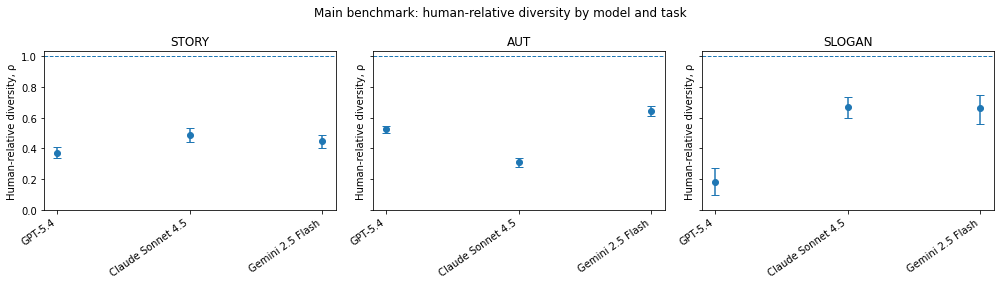

In [15]:
def plot_task_rho_with_ci(results: pd.DataFrame, save_path: Optional[Path] = None):
    plot_df = results.copy()

    task_order = ["story", "aut", "slogan"]
    model_order = ["GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

    for ax, task in zip(axes, task_order):
        sub = plot_df[plot_df["task"] == task].copy()
        sub["model"] = pd.Categorical(sub["model"], categories=model_order, ordered=True)
        sub = sub.sort_values("model")

        x = np.arange(len(sub))
        y = sub["rho"].to_numpy(dtype=float)
        yerr_low = y - sub["rho_95ci_low"].to_numpy(dtype=float)
        yerr_high = sub["rho_95ci_high"].to_numpy(dtype=float) - y

        ax.errorbar(
            x,
            y,
            yerr=[yerr_low, yerr_high],
            fmt="o",
            capsize=4,
        )

        ax.axhline(1.0, linestyle="--", linewidth=1)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["model"], rotation=35, ha="right")
        ax.set_title(task.upper())
        ax.set_ylabel("Human-relative diversity, ρ")
        ax.set_ylim(bottom=0)

    fig.suptitle("Main benchmark: human-relative diversity by model and task")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_task_rho_with_ci(
    main_results_table,
    save_path=FIG_DIR / "main_semantic_crowding_rho_by_task_model.pdf",
)

## 14. Figure: semantic crowding of humans versus AI

This diagnostic figure compares average human crowding $\kappa^H$ and AI crowding $\kappa^A$ at the task-family level.

Points above the diagonal indicate that AI responses are more semantically crowded than the matched human baseline.

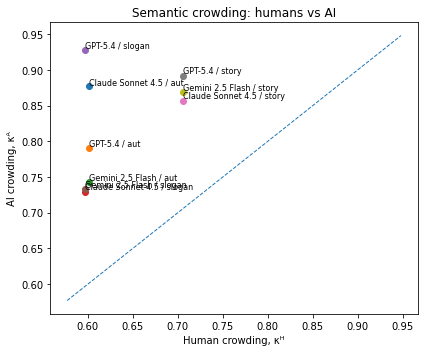

In [16]:
def plot_kappa_h_vs_a(results: pd.DataFrame, save_path: Optional[Path] = None):
    plot_df = results.copy()

    fig, ax = plt.subplots(figsize=(6, 5))

    for _, row in plot_df.iterrows():
        ax.scatter(row["kappa_H"], row["kappa_A"])
        ax.text(
            row["kappa_H"],
            row["kappa_A"],
            f"{row['model']} / {row['task']}",
            fontsize=8,
            ha="left",
            va="bottom",
        )

    # Diagonal parity line.
    min_val = min(plot_df["kappa_H"].min(), plot_df["kappa_A"].min())
    max_val = max(plot_df["kappa_H"].max(), plot_df["kappa_A"].max())
    pad = 0.02

    ax.plot([min_val - pad, max_val + pad], [min_val - pad, max_val + pad], linestyle="--", linewidth=1)

    ax.set_xlabel("Human crowding, κᴴ")
    ax.set_ylabel("AI crowding, κᴬ")
    ax.set_title("Semantic crowding: humans vs AI")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_kappa_h_vs_a(
    main_results_table,
    save_path=FIG_DIR / "main_semantic_crowding_kappa_h_vs_a.pdf",
)

## 15. Condition-level diagnostic figure

The task-family averages are the main paper result, but condition-level estimates help us see whether a model’s diversity loss is concentrated in particular prompts or objects.

This is especially useful for AUT, where different objects may produce very different human baselines.

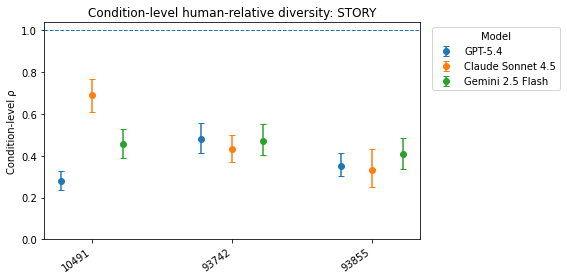

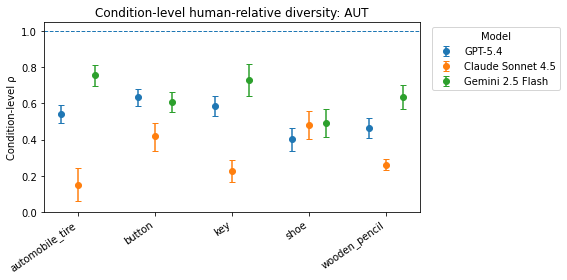

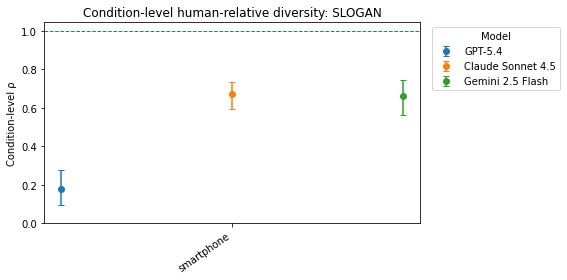

In [17]:
condition_plot_df = condition_summary.copy()

# Add a compact condition label.
condition_plot_df["condition_short"] = condition_plot_df["condition_id"].astype(str)

# Use bootstrap mean rho and percentile CI.
condition_plot_df = condition_plot_df.rename(columns={
    "rho_mean": "rho",
    "rho_ci_low": "rho_low",
    "rho_ci_high": "rho_high",
})

condition_plot_df.to_csv(TABLE_DIR / "main_condition_level_rho_display.csv", index=False)

for task in TASK_ORDER:
    sub = condition_plot_df[condition_plot_df["task_family"] == task].copy()

    if sub.empty:
        continue

    model_order = ["GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]
    condition_order = sorted(sub["condition_short"].unique())

    fig, ax = plt.subplots(figsize=(max(8, len(condition_order) * 1.2), 4))

    width = 0.22
    x_base = np.arange(len(condition_order))

    for i, model in enumerate(model_order):
        m = sub[sub["model_label"] == model].copy()
        m["condition_short"] = pd.Categorical(m["condition_short"], categories=condition_order, ordered=True)
        m = m.sort_values("condition_short")

        x = x_base + (i - 1) * width
        y = m["rho"].to_numpy(dtype=float)
        yerr_low = y - m["rho_low"].to_numpy(dtype=float)
        yerr_high = m["rho_high"].to_numpy(dtype=float) - y

        ax.errorbar(
            x,
            y,
            yerr=[yerr_low, yerr_high],
            fmt="o",
            capsize=3,
            label=model,
        )

    ax.axhline(1.0, linestyle="--", linewidth=1)
    ax.set_xticks(x_base)
    ax.set_xticklabels(condition_order, rotation=35, ha="right")
    ax.set_ylabel("Condition-level ρ")
    ax.set_title(f"Condition-level human-relative diversity: {task.upper()}")
    ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_ylim(bottom=0)

    fig.tight_layout()
    fig.savefig(FIG_DIR / f"main_condition_level_rho__{task}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

## 16. Save full bootstrap outputs

We save both condition-level and task-family bootstrap distributions. These are useful for later robustness checks, alternative visualizations, or supplementary analyses.

The main manuscript table should use `main_results_semantic_crowding_table.csv`.

In [18]:
condition_boot_path = CROWDING_DIR / "main_condition_level_bootstrap_semantic_crowding.pkl"
task_boot_path = CROWDING_DIR / "main_task_family_bootstrap_semantic_crowding.pkl"

condition_summary_path = CROWDING_DIR / "main_condition_level_summary_semantic_crowding.csv"
task_summary_path = CROWDING_DIR / "main_task_family_summary_semantic_crowding.csv"
main_results_path = CROWDING_DIR / "main_results_semantic_crowding_table.csv"

condition_boot_df.to_pickle(condition_boot_path)
task_boot_df.to_pickle(task_boot_path)

condition_summary.to_csv(condition_summary_path, index=False)
task_summary.to_csv(task_summary_path, index=False)
main_results_table.to_csv(main_results_path, index=False)

print("Saved:")
print(condition_boot_path)
print(task_boot_path)
print(condition_summary_path)
print(task_summary_path)
print(main_results_path)

Saved:
analysis_outputs/crowding_main/main_condition_level_bootstrap_semantic_crowding.pkl
analysis_outputs/crowding_main/main_task_family_bootstrap_semantic_crowding.pkl
analysis_outputs/crowding_main/main_condition_level_summary_semantic_crowding.csv
analysis_outputs/crowding_main/main_task_family_summary_semantic_crowding.csv
analysis_outputs/crowding_main/main_results_semantic_crowding_table.csv


## 17. Final main-analysis status report

This checkpoint confirms that the main semantic crowding analysis is complete.

Next, after inspecting the results, we can decide which robustness checks are worth running:

- temperature robustness,
- personality-prompt robustness,
- embedding model sensitivity,
- AUT manual-bucket kernel,
- slogan lexical/Jaccard kernel.

In [19]:
print("=" * 100)
print("MAIN RESULTS TABLE")
print("=" * 100)
display(display_table)

print("=" * 100)
print("Files saved")
print("=" * 100)

for p in sorted(CROWDING_DIR.glob("*")):
    print(p)

print("\nTables:")
for p in sorted(TABLE_DIR.glob("main_*crowding*.csv")):
    print(p)

print("\nFigures:")
for p in sorted(FIG_DIR.glob("main_semantic_crowding*.pdf")):
    print(p)
for p in sorted(FIG_DIR.glob("main_condition_level_rho__*.pdf")):
    print(p)

MAIN RESULTS TABLE


,model,task,n_conditions,mean_matched_n_per_condition,kappa_H,kappa_A,Delta,rho,rho_95ci,parity_classification
0,Claude Sonnet 4.5,aut,5,50.0,0.601,0.877,0.275,0.309,"[0.277, 0.34]",below parity
1,GPT-5.4,aut,5,50.0,0.601,0.791,0.190,0.525,"[0.499, 0.548]",below parity
2,Gemini 2.5 Flash,aut,5,50.0,0.601,0.743,0.142,0.645,"[0.612, 0.677]",below parity
3,Claude Sonnet 4.5,slogan,1,50.0,0.597,0.729,0.132,0.672,"[0.596, 0.734]",below parity
4,GPT-5.4,slogan,1,50.0,0.597,0.928,0.331,0.179,"[0.096, 0.275]",below parity
5,Gemini 2.5 Flash,slogan,1,50.0,0.597,0.733,0.136,0.662,"[0.562, 0.746]",below parity
6,Claude Sonnet 4.5,story,3,29.0,0.706,0.857,0.151,0.485,"[0.441, 0.533]",below parity
7,GPT-5.4,story,3,29.0,0.706,0.892,0.186,0.372,"[0.338, 0.408]",below parity
8,Gemini 2.5 Flash,story,3,29.0,0.705,0.869,0.164,0.446,"[0.406, 0.49]",below parity


Files saved
analysis_outputs/crowding_main/main_condition_level_bootstrap_semantic_crowding.pkl
analysis_outputs/crowding_main/main_condition_level_summary_semantic_crowding.csv
analysis_outputs/crowding_main/main_kappa_rarefaction_condition_level.pkl
analysis_outputs/crowding_main/main_kappa_rarefaction_task_level.pkl
analysis_outputs/crowding_main/main_results_semantic_crowding_table.csv
analysis_outputs/crowding_main/main_task_family_bootstrap_semantic_crowding.pkl
analysis_outputs/crowding_main/main_task_family_summary_semantic_crowding.csv

Tables:
analysis_outputs/tables/main_condition_level_semantic_crowding.csv
analysis_outputs/tables/main_crowding_sampling_pools.csv
analysis_outputs/tables/main_results_semantic_crowding_display_table.csv
analysis_outputs/tables/main_results_semantic_crowding_table.csv
analysis_outputs/tables/main_task_family_semantic_crowding.csv

Figures:
analysis_outputs/figures/main_semantic_crowding_kappa_h_vs_a.pdf
analysis_outputs/figures/main_semantic_c

# 18. Crowding Saturation Curves: Do We Have Enough AI Responses?

The main benchmark uses 50 AI generations per model-condition. Before generating more data, we want to know whether the estimated semantic crowding has stabilized.

For a given sample size $n$, we repeatedly sample $n$ responses and compute:

$ \kappa(n) = \text{mean pairwise semantic crowding among } n \text{ responses} $

If $\kappa_A(n)$ is still changing substantially near $n=50$, more AI generations may change the benchmark estimate. If $\kappa_A(n)$ is flat by $n=50$, more AI generations are unlikely to change the main conclusion.

For humans, we use the same participant-aware logic as the main analysis:

1. sample $n$ participants from the condition;
2. sample one response from each selected participant;
3. compute $\kappa_H(n)$.

For AI, each row is one generated response, so we sample directly from AI response rows.

Note: $\kappa(1)$ is undefined because there are no pairs at $n=1$, so the curves begin at $n=2$.

In [20]:
def rarefaction_curve_ai_response_pool(
    embedding_ids: np.ndarray,
    embedding_matrix: np.ndarray,
    n_values: List[int],
    n_boot: int = 500,
    seed: int = 42,
    replace: bool = False,
) -> pd.DataFrame:
    """
    Estimate kappa_A(n) for an AI response pool.

    Parameters
    ----------
    embedding_ids:
        Embedding IDs for available AI responses in one model-condition.
    embedding_matrix:
        Matrix of normalized embeddings.
    n_values:
        Sample sizes to evaluate.
    n_boot:
        Number of repeated samples per n.
    seed:
        Reproducibility seed.
    replace:
        If False, estimates finite-sample rarefaction among available AI generations.
        This is best for asking whether the current 50 generated samples are enough.
    """
    rng = np.random.default_rng(seed)
    embedding_ids = np.asarray(embedding_ids, dtype=int)

    rows = []

    for n in n_values:
        if n < 2:
            continue
        if (not replace) and n > len(embedding_ids):
            continue

        kappas = []

        for rep in range(n_boot):
            sample_ids = rng.choice(
                embedding_ids,
                size=n,
                replace=replace,
            )
            kappas.append(mean_pairwise_semantic_crowding(sample_ids, embedding_matrix))

        kappas = np.asarray(kappas, dtype=float)

        rows.append({
            "n": n,
            "kappa_mean": kappas.mean(),
            "kappa_median": np.median(kappas),
            "kappa_ci_low": np.percentile(kappas, 2.5),
            "kappa_ci_high": np.percentile(kappas, 97.5),
            "n_boot": n_boot,
            "sampling_replace": replace,
        })

    return pd.DataFrame(rows)


def rarefaction_curve_human_participant_pool(
    participant_to_ids: dict,
    embedding_matrix: np.ndarray,
    n_values: List[int],
    n_boot: int = 500,
    seed: int = 42,
    replace_participants: bool = False,
) -> pd.DataFrame:
    """
    Estimate kappa_H(n) using participant-aware human sampling.

    For each replicate:
    1. sample n participants;
    2. sample one response from each selected participant;
    3. compute semantic crowding.

    replace_participants=False gives a finite-sample rarefaction curve.
    """
    rng = np.random.default_rng(seed)
    participant_ids = np.array(list(participant_to_ids.keys()), dtype=object)

    rows = []

    for n in n_values:
        if n < 2:
            continue
        if (not replace_participants) and n > len(participant_ids):
            continue

        kappas = []

        for rep in range(n_boot):
            sampled_participants = rng.choice(
                participant_ids,
                size=n,
                replace=replace_participants,
            )

            sampled_embedding_ids = []

            for pid in sampled_participants:
                candidate_ids = participant_to_ids[pid]
                chosen_id = rng.choice(candidate_ids, size=1, replace=True)[0]
                sampled_embedding_ids.append(chosen_id)

            kappas.append(
                mean_pairwise_semantic_crowding(
                    np.asarray(sampled_embedding_ids, dtype=int),
                    embedding_matrix,
                )
            )

        kappas = np.asarray(kappas, dtype=float)

        rows.append({
            "n": n,
            "kappa_mean": kappas.mean(),
            "kappa_median": np.median(kappas),
            "kappa_ci_low": np.percentile(kappas, 2.5),
            "kappa_ci_high": np.percentile(kappas, 97.5),
            "n_boot": n_boot,
            "sampling_replace": replace_participants,
        })

    return pd.DataFrame(rows)

## 18.1 Choose the sample-size grid

For the main diagnostic, we evaluate all integer sample sizes from $n=2$ through $n=50$ where possible.

This is intentionally dense because the goal is to see whether $\kappa(n)$ is still moving near the maximum available AI sample size.

If runtime becomes annoying, switch `N_VALUES` to `N_VALUES_FAST`.

In [21]:
N_VALUES_FULL = list(range(2, 51))
N_VALUES_FAST = [2, 3, 5, 8, 10, 15, 20, 25, 30, 40, 50]

# Use the full grid first. Switch to N_VALUES_FAST if needed.
N_VALUES = N_VALUES_FULL

# 300 is usually enough for a diagnostic curve.
# Increase to 500 or 1000 if you want smoother confidence bands.
N_RAREFACTION_BOOT = 300

print("Number of n values:", len(N_VALUES))
print("n range:", min(N_VALUES), "to", max(N_VALUES))
print("Bootstrap repetitions per n:", N_RAREFACTION_BOOT)

Number of n values: 49
n range: 2 to 50
Bootstrap repetitions per n: 300


## 18.2 Compute condition-level $\kappa(n)$ curves

This cell computes condition-level saturation curves for both humans and AI.

For humans, each condition has one curve. For AI, each model-condition has one curve.

In [22]:
rarefaction_dfs = []

start_time = time.time()

# Human curves: one per task-condition.
for (task, condition_id), participant_pool in human_participant_pools.items():
    max_n = min(max(N_VALUES), len(participant_pool))
    n_values_use = [n for n in N_VALUES if n <= max_n]

    seed_payload = f"human::{task}::{condition_id}::rarefaction"
    seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

    curve = rarefaction_curve_human_participant_pool(
        participant_to_ids=participant_pool,
        embedding_matrix=embedding_matrix,
        n_values=n_values_use,
        n_boot=N_RAREFACTION_BOOT,
        seed=seed,
        replace_participants=False,
    )

    curve["source_type"] = "human"
    curve["model_label"] = "Human"
    curve["task_family"] = task
    curve["condition_id"] = condition_id
    curve["available_n"] = len(participant_pool)

    rarefaction_dfs.append(curve)

    print(f"Human | {task:7s} | {condition_id:16s} | available_n={len(participant_pool):3d} | max_curve_n={max_n:3d}")

# AI curves: one per model-task-condition.
for (model_label, task, condition_id), ai_ids in ai_pools.items():
    max_n = min(max(N_VALUES), len(ai_ids))
    n_values_use = [n for n in N_VALUES if n <= max_n]

    seed_payload = f"ai::{model_label}::{task}::{condition_id}::rarefaction"
    seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

    curve = rarefaction_curve_ai_response_pool(
        embedding_ids=ai_ids,
        embedding_matrix=embedding_matrix,
        n_values=n_values_use,
        n_boot=N_RAREFACTION_BOOT,
        seed=seed,
        replace=False,
    )

    curve["source_type"] = "ai"
    curve["model_label"] = model_label
    curve["task_family"] = task
    curve["condition_id"] = condition_id
    curve["available_n"] = len(ai_ids)

    rarefaction_dfs.append(curve)

    print(f"AI    | {model_label:20s} | {task:7s} | {condition_id:16s} | available_n={len(ai_ids):3d} | max_curve_n={max_n:3d}")

rarefaction_df = pd.concat(rarefaction_dfs, ignore_index=True)

elapsed = time.time() - start_time
print(f"\nRarefaction complete: {rarefaction_df.shape} rows")
print(f"Elapsed time: {elapsed:.1f} seconds")

rarefaction_path = TABLE_DIR / "main_kappa_rarefaction_condition_level.csv"
rarefaction_df.to_csv(rarefaction_path, index=False)

print("Saved:", rarefaction_path)
display(rarefaction_df.head())


Human | aut     | automobile_tire  | available_n=109 | max_curve_n= 50
Human | aut     | button           | available_n=109 | max_curve_n= 50
Human | aut     | key              | available_n=109 | max_curve_n= 50
Human | aut     | shoe             | available_n=109 | max_curve_n= 50
Human | aut     | wooden_pencil    | available_n=109 | max_curve_n= 50
Human | slogan  | smartphone       | available_n= 95 | max_curve_n= 50
Human | story   | 10491            | available_n= 35 | max_curve_n= 35
Human | story   | 93742            | available_n= 32 | max_curve_n= 32
Human | story   | 93855            | available_n= 20 | max_curve_n= 20
AI    | Claude Sonnet 4.5    | aut     | automobile_tire  | available_n= 50 | max_curve_n= 50
AI    | Claude Sonnet 4.5    | aut     | button           | available_n= 50 | max_curve_n= 50
AI    | Claude Sonnet 4.5    | aut     | key              | available_n= 50 | max_curve_n= 50
AI    | Claude Sonnet 4.5    | aut     | shoe             | available_n= 50 | m

,n,kappa_mean,kappa_median,kappa_ci_low,kappa_ci_high,n_boot,sampling_replace,source_type,model_label,task_family,condition_id,available_n
0,2,0.603345,0.589859,0.507249,0.766070,300,False,human,Human,aut,automobile_tire,109
1,3,0.595705,0.589555,0.527216,0.684313,300,False,human,Human,aut,automobile_tire,109
2,4,0.598772,0.594249,0.543403,0.677672,300,False,human,Human,aut,automobile_tire,109
3,5,0.600955,0.598099,0.550546,0.667555,300,False,human,Human,aut,automobile_tire,109
4,6,0.599451,0.597860,0.553541,0.659108,300,False,human,Human,aut,automobile_tire,109


In [23]:
rarefaction_df

,n,kappa_mean,kappa_median,kappa_ci_low,kappa_ci_high,n_boot,sampling_replace,source_type,model_label,task_family,condition_id,available_n
0,2,0.603345,0.589859,0.507249,0.766070,300,False,human,Human,aut,automobile_tire,109
1,3,0.595705,0.589555,0.527216,0.684313,300,False,human,Human,aut,automobile_tire,109
2,4,0.598772,0.594249,0.543403,0.677672,300,False,human,Human,aut,automobile_tire,109
3,5,0.600955,0.598099,0.550546,0.667555,300,False,human,Human,aut,automobile_tire,109
4,6,0.599451,0.597860,0.553541,0.659108,300,False,human,Human,aut,automobile_tire,109
...,...,...,...,...,...,...,...,...,...,...,...,...
1696,46,0.873343,0.873237,0.870273,0.877257,300,False,ai,Gemini 2.5 Flash,story,93855,50
1697,47,0.873306,0.873148,0.871111,0.876417,300,False,ai,Gemini 2.5 Flash,story,93855,50
1698,48,0.873290,0.873133,0.871525,0.875718,300,False,ai,Gemini 2.5 Flash,story,93855,50
1699,49,0.873227,0.873055,0.872231,0.875088,300,False,ai,Gemini 2.5 Flash,story,93855,50


## 18.3 Aggregate condition-level curves to task-level curves

For a task-level view, we average $\kappa(n)$ across conditions within each task family.

Important detail: at a given $n$, a task average only includes conditions where that $n$ is available. For AUT and slogans this is not a problem up to $n=50$. For stories, the human curves are capped by the smallest prompt sample size, so human story task averages beyond $n=20$ would not include all story prompts. The code records `n_conditions_in_average` so we can see this.

In [24]:
task_rarefaction_df = (
    rarefaction_df
    .groupby(["source_type", "model_label", "task_family", "n"], dropna=False)
    .agg(
        kappa_mean=("kappa_mean", "mean"),
        kappa_ci_low=("kappa_ci_low", "mean"),
        kappa_ci_high=("kappa_ci_high", "mean"),
        n_conditions_in_average=("condition_id", "nunique"),
    )
    .reset_index()
    .sort_values(["task_family", "source_type", "model_label", "n"])
)

task_rarefaction_path = TABLE_DIR / "main_kappa_rarefaction_task_level.csv"
task_rarefaction_df.to_csv(task_rarefaction_path, index=False)

print("Saved:", task_rarefaction_path)
display(task_rarefaction_df.head())

Saved: analysis_outputs/tables/main_kappa_rarefaction_task_level.csv


,source_type,model_label,task_family,n,kappa_mean,kappa_ci_low,kappa_ci_high,n_conditions_in_average
0,ai,Claude Sonnet 4.5,aut,2,0.876245,0.697414,0.999381,5
1,ai,Claude Sonnet 4.5,aut,3,0.872892,0.756944,0.979306,5
2,ai,Claude Sonnet 4.5,aut,4,0.873207,0.774189,0.970673,5
3,ai,Claude Sonnet 4.5,aut,5,0.873980,0.788013,0.958469,5
4,ai,Claude Sonnet 4.5,aut,6,0.875349,0.796909,0.950567,5


## 18.4 Plot task-level $\kappa(n)$ saturation curves

These are the key plots for deciding whether 50 AI generations per condition is enough.

Interpretation:

- A flat AI curve near $n=50$ suggests the current AI sample is sufficient.
- A visibly drifting AI curve near $n=50$ suggests we should generate more AI responses for that model-task.
- For stories, the main matched benchmark is human-limited, so more AI responses alone will not increase matched $n$ unless more human stories are added.

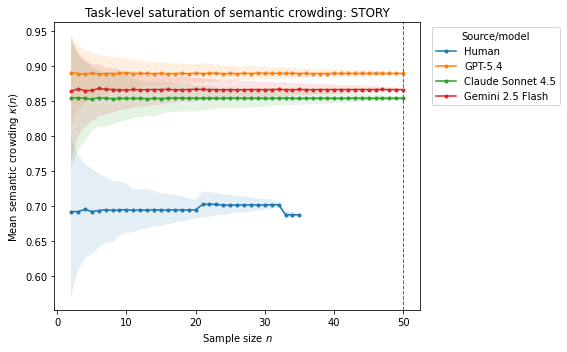

Saved: analysis_outputs/figures/main_kappa_rarefaction_task_level__story.pdf


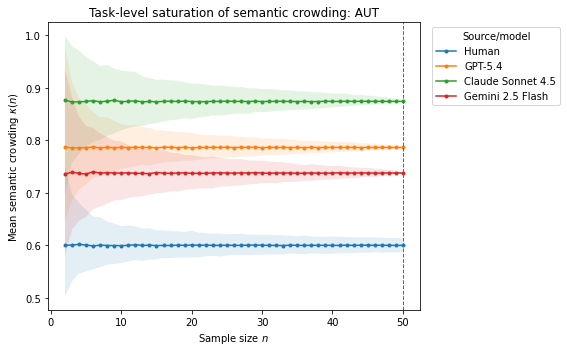

Saved: analysis_outputs/figures/main_kappa_rarefaction_task_level__aut.pdf


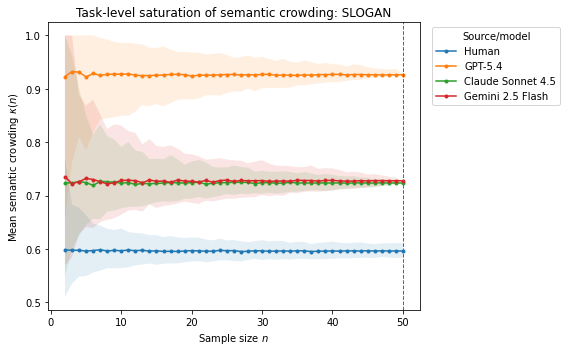

Saved: analysis_outputs/figures/main_kappa_rarefaction_task_level__slogan.pdf


In [25]:
def plot_task_rarefaction_curves(task_rarefaction_df: pd.DataFrame, save_dir: Path):
    task_order = ["story", "aut", "slogan"]
    model_order = ["Human", "GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]

    for task in task_order:
        sub = task_rarefaction_df[task_rarefaction_df["task_family"] == task].copy()

        if sub.empty:
            continue

        fig, ax = plt.subplots(figsize=(8, 5))

        for model_label in model_order:
            m = sub[sub["model_label"] == model_label].sort_values("n")

            if m.empty:
                continue

            ax.plot(
                m["n"],
                m["kappa_mean"],
                marker="o",
                markersize=3,
                linewidth=1.5,
                label=model_label,
            )

            ax.fill_between(
                m["n"].to_numpy(dtype=float),
                m["kappa_ci_low"].to_numpy(dtype=float),
                m["kappa_ci_high"].to_numpy(dtype=float),
                alpha=0.12,
            )

        ax.axvline(50, linestyle="--", linewidth=1)
        ax.set_xlabel("Sample size $n$")
        ax.set_ylabel("Mean semantic crowding $\\kappa(n)$")
        ax.set_title(f"Task-level saturation of semantic crowding: {task.upper()}")
        ax.legend(title="Source/model", bbox_to_anchor=(1.02, 1), loc="upper left")

        fig.tight_layout()

        out_path = save_dir / f"main_kappa_rarefaction_task_level__{task}.pdf"
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Saved:", out_path)


plot_task_rarefaction_curves(task_rarefaction_df, FIG_DIR)

## 18.5 Plot condition-level $\kappa(n)$ saturation curves

Task-level averages can hide individual unstable conditions. These condition-level plots show whether a particular prompt/object/product needs more AI samples.

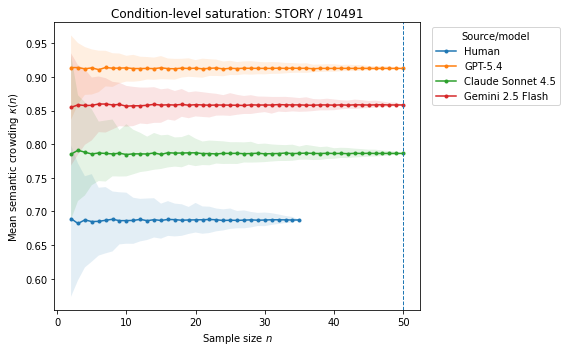

Saved: analysis_outputs/figures/main_kappa_rarefaction_condition__story__10491.pdf


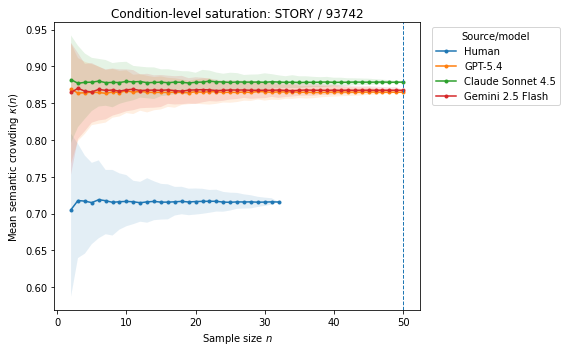

Saved: analysis_outputs/figures/main_kappa_rarefaction_condition__story__93742.pdf


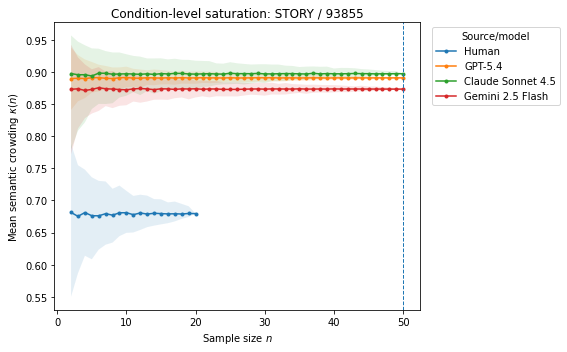

Saved: analysis_outputs/figures/main_kappa_rarefaction_condition__story__93855.pdf


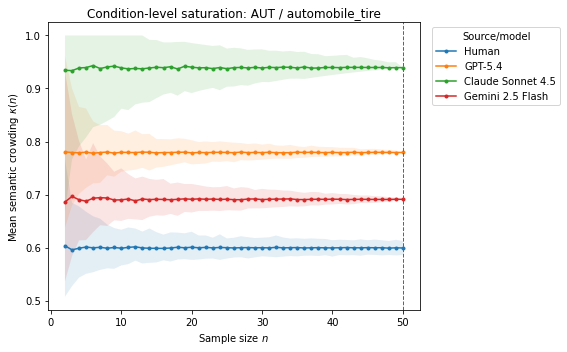

Saved: analysis_outputs/figures/main_kappa_rarefaction_condition__aut__automobile_tire.pdf


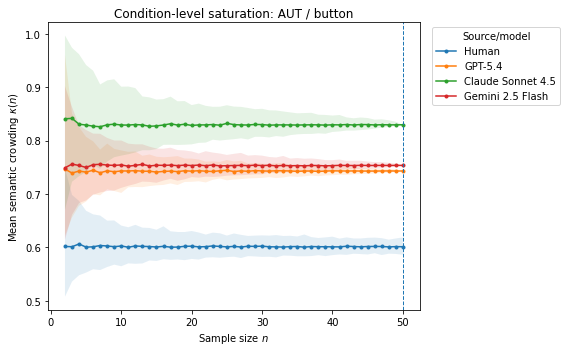

Saved: analysis_outputs/figures/main_kappa_rarefaction_condition__aut__button.pdf


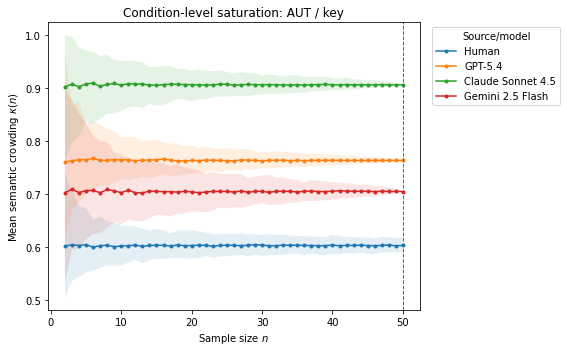

Saved: analysis_outputs/figures/main_kappa_rarefaction_condition__aut__key.pdf


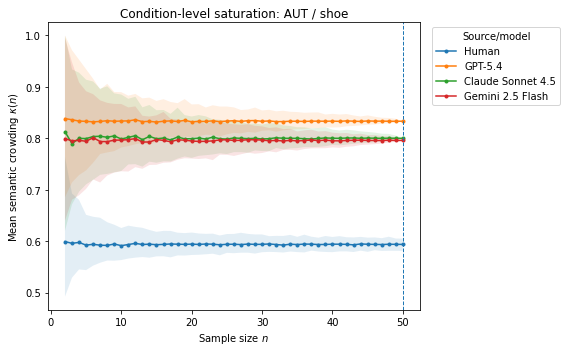

Saved: analysis_outputs/figures/main_kappa_rarefaction_condition__aut__shoe.pdf


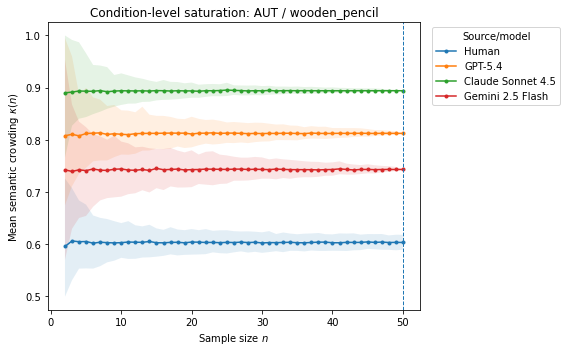

Saved: analysis_outputs/figures/main_kappa_rarefaction_condition__aut__wooden_pencil.pdf


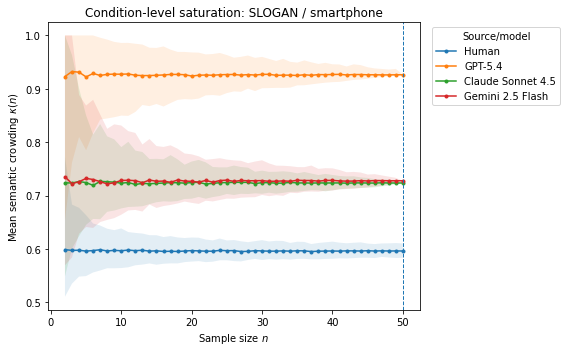

Saved: analysis_outputs/figures/main_kappa_rarefaction_condition__slogan__smartphone.pdf


In [26]:
def plot_condition_rarefaction_curves(rarefaction_df: pd.DataFrame, save_dir: Path):
    task_order = ["story", "aut", "slogan"]
    model_order = ["Human", "GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]

    for task in task_order:
        sub_task = rarefaction_df[rarefaction_df["task_family"] == task].copy()

        if sub_task.empty:
            continue

        condition_ids = sorted(sub_task["condition_id"].astype(str).unique())

        for condition_id in condition_ids:
            sub = sub_task[sub_task["condition_id"].astype(str) == str(condition_id)].copy()

            fig, ax = plt.subplots(figsize=(8, 5))

            for model_label in model_order:
                m = sub[sub["model_label"] == model_label].sort_values("n")

                if m.empty:
                    continue

                ax.plot(
                    m["n"],
                    m["kappa_mean"],
                    marker="o",
                    markersize=3,
                    linewidth=1.5,
                    label=model_label,
                )

                ax.fill_between(
                    m["n"].to_numpy(dtype=float),
                    m["kappa_ci_low"].to_numpy(dtype=float),
                    m["kappa_ci_high"].to_numpy(dtype=float),
                    alpha=0.12,
                )

            ax.axvline(50, linestyle="--", linewidth=1)
            ax.set_xlabel("Sample size $n$")
            ax.set_ylabel("Mean semantic crowding $\\kappa(n)$")
            ax.set_title(f"Condition-level saturation: {task.upper()} / {condition_id}")
            ax.legend(title="Source/model", bbox_to_anchor=(1.02, 1), loc="upper left")

            fig.tight_layout()

            safe_condition = str(condition_id).replace("/", "_").replace(" ", "_")
            out_path = save_dir / f"main_kappa_rarefaction_condition__{task}__{safe_condition}.pdf"
            fig.savefig(out_path, dpi=300, bbox_inches="tight")
            plt.show()

            print("Saved:", out_path)


plot_condition_rarefaction_curves(rarefaction_df, FIG_DIR)

## 18.6 Quantify recent drift near the maximum sample size

The plots are the most interpretable diagnostic. We also compute a simple numeric check:

$ \Delta\kappa_{\text{recent}} = \kappa(n_{\max}) - \kappa(n_{\max}-10) $

and

$ \text{relative drift} = \frac{|\kappa(n_{\max}) - \kappa(n_{\max}-10)|}{|\kappa(n_{\max})|} $

For the main question, focus on AI rows. A relative drift below roughly 1–2% suggests that the curve has mostly stabilized. A larger value suggests that more AI generations may be worth collecting for that model-condition.

In [27]:
def compute_recent_drift_by_curve(
    curve_df: pd.DataFrame,
    window: int = 10,
) -> pd.DataFrame:
    """
    For each curve, compare kappa at max n versus kappa at max n - window.

    This works even when some curves have max n < 50, such as human story prompts.
    """
    rows = []

    group_cols = ["source_type", "model_label", "task_family", "condition_id"]

    for keys, g in curve_df.groupby(group_cols, dropna=False):
        g = g.sort_values("n").copy()

        max_n = int(g["n"].max())
        low_n_target = max_n - window

        # Use the available n closest to max_n - window, not exceeding it.
        possible_low = g[g["n"] <= low_n_target]

        if possible_low.empty:
            continue

        low_row = possible_low.iloc[-1]
        high_row = g[g["n"] == max_n].iloc[0]

        k_low = float(low_row["kappa_mean"])
        k_high = float(high_row["kappa_mean"])

        abs_change = k_high - k_low
        relative_abs_change = abs(abs_change) / max(abs(k_high), 1e-12)

        row = dict(zip(group_cols, keys))
        row.update({
            "n_low": int(low_row["n"]),
            "n_high": max_n,
            "kappa_low": k_low,
            "kappa_high": k_high,
            "kappa_change": abs_change,
            "relative_abs_change": relative_abs_change,
            "flag_relative_change_gt_1pct": relative_abs_change > 0.01,
            "flag_relative_change_gt_2pct": relative_abs_change > 0.02,
        })

        rows.append(row)

    return pd.DataFrame(rows)


condition_drift = compute_recent_drift_by_curve(
    rarefaction_df,
    window=10,
)

condition_drift = condition_drift.sort_values(
    ["task_family", "source_type", "model_label", "condition_id"]
).reset_index(drop=True)

condition_drift_path = TABLE_DIR / "main_kappa_rarefaction_condition_recent_drift.csv"
condition_drift.to_csv(condition_drift_path, index=False)

print("Saved:", condition_drift_path)
display(condition_drift)

Saved: analysis_outputs/tables/main_kappa_rarefaction_condition_recent_drift.csv


,source_type,model_label,task_family,condition_id,n_low,n_high,kappa_low,kappa_high,kappa_change,relative_abs_change,flag_relative_change_gt_1pct,flag_relative_change_gt_2pct
0,ai,Claude Sonnet 4.5,aut,automobile_tire,40,50,0.939586,0.939296,-0.000290,0.000309,False,False
1,ai,Claude Sonnet 4.5,aut,button,40,50,0.829700,0.829756,0.000056,0.000067,False,False
2,ai,Claude Sonnet 4.5,aut,key,40,50,0.906886,0.906847,-0.000039,0.000043,False,False
3,ai,Claude Sonnet 4.5,aut,shoe,40,50,0.800158,0.800014,-0.000143,0.000179,False,False
4,ai,Claude Sonnet 4.5,aut,wooden_pencil,40,50,0.893989,0.894106,0.000117,0.000131,False,False
5,ai,GPT-5.4,aut,automobile_tire,40,50,0.779484,0.779289,-0.000195,0.000250,False,False
6,ai,GPT-5.4,aut,button,40,50,0.743466,0.743199,-0.000267,0.000359,False,False
7,ai,GPT-5.4,aut,key,40,50,0.764096,0.763944,-0.000151,0.000198,False,False
8,ai,GPT-5.4,aut,shoe,40,50,0.833436,0.833242,-0.000195,0.000234,False,False
9,ai,GPT-5.4,aut,wooden_pencil,40,50,0.812326,0.812362,0.000036,0.000044,False,False


## 18.7 Task-level recent drift

This is the compact version. For deciding whether to generate more AI data, focus on `source_type == "ai"`.

A rough rule:

- `relative_abs_change <= 0.01`: probably enough;
- `0.01 < relative_abs_change <= 0.02`: inspect the plot;
- `relative_abs_change > 0.02`: consider generating more AI responses for that task/model.

In [28]:
task_drift = compute_recent_drift_by_curve(
    task_rarefaction_df.assign(condition_id="TASK_AVERAGE"),
    window=10,
)

task_drift = task_drift.sort_values(
    ["task_family", "source_type", "model_label"]
).reset_index(drop=True)

task_drift_path = TABLE_DIR / "main_kappa_rarefaction_task_recent_drift.csv"
task_drift.to_csv(task_drift_path, index=False)

print("Saved:", task_drift_path)

display(task_drift)

print("\nAI-only task-level drift:")
display(
    task_drift
    .query("source_type == 'ai'")
    .sort_values(["flag_relative_change_gt_2pct", "relative_abs_change"], ascending=[False, False])
)

Saved: analysis_outputs/tables/main_kappa_rarefaction_task_recent_drift.csv


,source_type,model_label,task_family,condition_id,n_low,n_high,kappa_low,kappa_high,kappa_change,relative_abs_change,flag_relative_change_gt_1pct,flag_relative_change_gt_2pct
0,ai,Claude Sonnet 4.5,aut,TASK_AVERAGE,40,50,0.874064,0.874004,-0.000060,0.000069,False,False
1,ai,GPT-5.4,aut,TASK_AVERAGE,40,50,0.786562,0.786407,-0.000154,0.000196,False,False
2,ai,Gemini 2.5 Flash,aut,TASK_AVERAGE,40,50,0.737719,0.737773,0.000054,0.000073,False,False
3,human,Human,aut,TASK_AVERAGE,40,50,0.600302,0.600237,-0.000065,0.000109,False,False
4,ai,Claude Sonnet 4.5,slogan,TASK_AVERAGE,40,50,0.723630,0.723616,-0.000014,0.000019,False,False
5,ai,GPT-5.4,slogan,TASK_AVERAGE,40,50,0.926871,0.926327,-0.000544,0.000587,False,False
6,ai,Gemini 2.5 Flash,slogan,TASK_AVERAGE,40,50,0.728476,0.727721,-0.000755,0.001038,False,False
7,human,Human,slogan,TASK_AVERAGE,40,50,0.596146,0.596149,0.000003,0.000005,False,False
8,ai,Claude Sonnet 4.5,story,TASK_AVERAGE,40,50,0.853920,0.854035,0.000116,0.000135,False,False
9,ai,GPT-5.4,story,TASK_AVERAGE,40,50,0.889544,0.889512,-0.000032,0.000036,False,False



AI-only task-level drift:


,source_type,model_label,task_family,condition_id,n_low,n_high,kappa_low,kappa_high,kappa_change,relative_abs_change,flag_relative_change_gt_1pct,flag_relative_change_gt_2pct
6,ai,Gemini 2.5 Flash,slogan,TASK_AVERAGE,40,50,0.728476,0.727721,-0.000755,0.001038,False,False
5,ai,GPT-5.4,slogan,TASK_AVERAGE,40,50,0.926871,0.926327,-0.000544,0.000587,False,False
1,ai,GPT-5.4,aut,TASK_AVERAGE,40,50,0.786562,0.786407,-0.000154,0.000196,False,False
8,ai,Claude Sonnet 4.5,story,TASK_AVERAGE,40,50,0.853920,0.854035,0.000116,0.000135,False,False
2,ai,Gemini 2.5 Flash,aut,TASK_AVERAGE,40,50,0.737719,0.737773,0.000054,0.000073,False,False
0,ai,Claude Sonnet 4.5,aut,TASK_AVERAGE,40,50,0.874064,0.874004,-0.000060,0.000069,False,False
10,ai,Gemini 2.5 Flash,story,TASK_AVERAGE,40,50,0.866477,0.866443,-0.000034,0.000039,False,False
9,ai,GPT-5.4,story,TASK_AVERAGE,40,50,0.889544,0.889512,-0.000032,0.000036,False,False
4,ai,Claude Sonnet 4.5,slogan,TASK_AVERAGE,40,50,0.723630,0.723616,-0.000014,0.000019,False,False


## 18.8 Decision table: should we generate more AI data?

This final diagnostic table translates recent drift into a simple decision aid.

This is not a formal stopping rule, but it is useful for determining whether additional AI generations are likely to change the benchmark.

In [29]:
def assign_more_data_recommendation(row: pd.Series) -> str:
    """
    Simple decision aid based on recent drift.
    """
    if row["source_type"] != "ai":
        return "human diagnostic only"

    if row["relative_abs_change"] <= 0.01:
        return "likely enough AI data"

    if row["relative_abs_change"] <= 0.02:
        return "inspect plot; probably enough if curve is flat"

    return "consider more AI generations"


ai_more_data_decision = task_drift.query("source_type == 'ai'").copy()
ai_more_data_decision["recommendation"] = ai_more_data_decision.apply(
    assign_more_data_recommendation,
    axis=1,
)

ai_more_data_decision = ai_more_data_decision[
    [
        "model_label",
        "task_family",
        "n_low",
        "n_high",
        "kappa_low",
        "kappa_high",
        "kappa_change",
        "relative_abs_change",
        "recommendation",
    ]
].sort_values(["recommendation", "task_family", "model_label"])

decision_path = TABLE_DIR / "main_ai_more_data_decision_from_kappa_rarefaction.csv"
ai_more_data_decision.to_csv(decision_path, index=False)

print("Saved:", decision_path)
display(ai_more_data_decision)

Saved: analysis_outputs/tables/main_ai_more_data_decision_from_kappa_rarefaction.csv


,model_label,task_family,n_low,n_high,kappa_low,kappa_high,kappa_change,relative_abs_change,recommendation
0,Claude Sonnet 4.5,aut,40,50,0.874064,0.874004,-0.000060,0.000069,likely enough AI data
1,GPT-5.4,aut,40,50,0.786562,0.786407,-0.000154,0.000196,likely enough AI data
2,Gemini 2.5 Flash,aut,40,50,0.737719,0.737773,0.000054,0.000073,likely enough AI data
4,Claude Sonnet 4.5,slogan,40,50,0.723630,0.723616,-0.000014,0.000019,likely enough AI data
5,GPT-5.4,slogan,40,50,0.926871,0.926327,-0.000544,0.000587,likely enough AI data
6,Gemini 2.5 Flash,slogan,40,50,0.728476,0.727721,-0.000755,0.001038,likely enough AI data
8,Claude Sonnet 4.5,story,40,50,0.853920,0.854035,0.000116,0.000135,likely enough AI data
9,GPT-5.4,story,40,50,0.889544,0.889512,-0.000032,0.000036,likely enough AI data
10,Gemini 2.5 Flash,story,40,50,0.866477,0.866443,-0.000034,0.000039,likely enough AI data


## 18.9 Save rarefaction objects for later reuse

We save the condition-level and task-level rarefaction outputs so that we do not need to recompute them when drafting figures or supplement tables.

In [30]:
rarefaction_condition_pkl = CROWDING_DIR / "main_kappa_rarefaction_condition_level.pkl"
rarefaction_task_pkl = CROWDING_DIR / "main_kappa_rarefaction_task_level.pkl"

rarefaction_df.to_pickle(rarefaction_condition_pkl)
task_rarefaction_df.to_pickle(rarefaction_task_pkl)

print("Saved:")
print(rarefaction_condition_pkl)
print(rarefaction_task_pkl)
print(TABLE_DIR / "main_kappa_rarefaction_condition_level.csv")
print(TABLE_DIR / "main_kappa_rarefaction_task_level.csv")
print(TABLE_DIR / "main_kappa_rarefaction_task_recent_drift.csv")
print(TABLE_DIR / "main_ai_more_data_decision_from_kappa_rarefaction.csv")

Saved:
analysis_outputs/crowding_main/main_kappa_rarefaction_condition_level.pkl
analysis_outputs/crowding_main/main_kappa_rarefaction_task_level.pkl
analysis_outputs/tables/main_kappa_rarefaction_condition_level.csv
analysis_outputs/tables/main_kappa_rarefaction_task_level.csv
analysis_outputs/tables/main_kappa_rarefaction_task_recent_drift.csv
analysis_outputs/tables/main_ai_more_data_decision_from_kappa_rarefaction.csv


# 19. Slogan Lexical-Template Crowding Analysis

The semantic kernel captures meaning-level similarity. For slogans, however, a reviewer may reasonably ask whether AI outputs are not only semantically similar but also reusing similar lexical templates.

This section computes slogan-only crowding using lexical overlap kernels.

We use two kernels:

1. **Non-stopword token Jaccard**

$K^{word}(x,y)=\frac{|T(x)\cap T(y)|}{|T(x)\cup T(y)|}$

where $T(x)$ is the set of non-stopword tokens in slogan $x$.

2. **Character trigram Jaccard**

$K^{tri}(x,y)=\frac{|G_3(x)\cap G_3(y)|}{|G_3(x)\cup G_3(y)|}$

where $G_3(x)$ is the set of character trigrams after lowercasing and simplifying whitespace/punctuation.

The word-level kernel detects reuse of key marketing words such as “future,” “smart,” “pocket,” or “power.” The trigram kernel is stricter about near-template reuse and can detect repeated phrase fragments even when tokenization differs.

As before, the human baseline is participant-aware: sample participants first, then sample one slogan from each participant.

In [31]:
# Output directories for the slogan lexical-template analysis.
SLOGAN_LEX_DIR = ANALYSIS_DIR / "crowding_slogan_lexical"

SLOGAN_LEX_DIR.mkdir(parents=True, exist_ok=True)

## 19.1 Prepare the slogan-only analysis table

We isolate the smartphone slogan condition from the main analysis table.

The human side includes all human slogans. The AI side includes only neutral/default-temperature main benchmark generations.

In [32]:
slogan_df = main_analysis_df.query("task_family == 'slogan'").copy()

# Sanity checks.
assert slogan_df["condition_id"].nunique() == 1
assert slogan_df["condition_id"].iloc[0] == "smartphone"

print("Slogan analysis rows:", slogan_df.shape)

display(
    slogan_df
    .groupby(["source_type", "model_label", "condition_id"], dropna=False)
    .agg(
        n_responses=("response_text", "size"),
        n_unique_responses=("response_text", "nunique"),
        n_participants=("participant_id", "nunique"),
    )
    .reset_index()
    .sort_values(["source_type", "model_label"])
)

slogan_df.head()

Slogan analysis rows: (809, 16)


,source_type,model_label,condition_id,n_responses,n_unique_responses,n_participants
0,ai,Claude Sonnet 4.5,smartphone,50,26,0
1,ai,GPT-5.4,smartphone,50,13,0
2,ai,Gemini 2.5 Flash,smartphone,50,29,0
3,human,Human,smartphone,659,650,95


,task_family,source_type,provider,model,condition_id,condition_label,analysis_scenario_name,temperature,response_text,response_word_count,bucket_id,bucket_key,participant_id,model_label,analysis_row_id,embedding_text_id
3134,slogan,human,human,human,smartphone,Smartphone,human,NaN,The future right in your pocket.,6,<NA>,NaN,545cbbcafdf99b11ed040acf,Human,3134,2851
3135,slogan,human,human,human,smartphone,Smartphone,human,NaN,A phone for a new age.,6,<NA>,NaN,545cbbcafdf99b11ed040acf,Human,3135,2852
3136,slogan,human,human,human,smartphone,Smartphone,human,NaN,Slim. Sleek. Smartphone.,3,<NA>,NaN,545cbbcafdf99b11ed040acf,Human,3136,2853
3137,slogan,human,human,human,smartphone,Smartphone,human,NaN,Be smart. Get this phone.,5,<NA>,NaN,545cbbcafdf99b11ed040acf,Human,3137,2854
3138,slogan,human,human,human,smartphone,Smartphone,human,NaN,Smartphones just got a genius upgrade.,6,<NA>,NaN,545cbbcafdf99b11ed040acf,Human,3138,2855


## 19.2 Define lexical preprocessing functions

The word-level kernel removes common English stopwords because overlap on words such as “the,” “a,” “for,” and “your” should not count as meaningful template reuse.

For replicability, we use scikit-learn’s built-in `ENGLISH_STOP_WORDS` list rather than a hand-coded stopword list. This avoids hidden researcher discretion in the lexical kernel while keeping the notebook self-contained.

If a slogan becomes empty after removing stopwords, we fall back to all tokens so that short slogans such as “Think Different” or “Just Smart” still have a usable representation.

In [33]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Standard, package-provided English stopword set.
# This is more defensible than a hand-coded list because it is reproducible
# from the scikit-learn version used in the environment.
EN_STOPWORDS = frozenset(ENGLISH_STOP_WORDS)

print(f"Using scikit-learn ENGLISH_STOP_WORDS with {len(EN_STOPWORDS)} stopwords.")


def tokenize_slogan(text: str) -> List[str]:
    """
    Lowercase and tokenize a slogan into word-like tokens.

    Keeps alphanumeric words and apostrophes inside words.
    """
    if not isinstance(text, str):
        return []

    text = text.lower()
    tokens = re.findall(r"[a-z0-9]+(?:'[a-z0-9]+)?", text)
    return tokens


def content_token_set(text: str, stopwords: set = EN_STOPWORDS) -> frozenset:
    """
    Return non-stopword token set for a slogan.

    If stopword removal removes everything, fall back to all tokens.
    This prevents very short slogans from becoming empty representations.
    """
    tokens = tokenize_slogan(text)
    content_tokens = [t for t in tokens if t not in stopwords]

    if len(content_tokens) == 0:
        content_tokens = tokens

    return frozenset(content_tokens)


def normalize_for_char_ngrams(text: str) -> str:
    """
    Normalize slogan text for character n-gram overlap.

    This removes punctuation and compresses whitespace, while preserving word order.
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def char_ngram_set(text: str, n: int = 3) -> frozenset:
    """
    Return character n-gram set after normalization.

    Spaces are retained inside the normalized string because phrase boundaries
    can be informative for template reuse.
    """
    text = normalize_for_char_ngrams(text)

    if len(text) == 0:
        return frozenset()

    # Add boundary padding so short slogans still get meaningful grams.
    padded = f" {text} "

    if len(padded) < n:
        return frozenset([padded])

    return frozenset(padded[i:i+n] for i in range(len(padded) - n + 1))


def jaccard_similarity(a: frozenset, b: frozenset) -> float:
    """
    Jaccard similarity between two sets.

    If both sets are empty, return 0.0 rather than 1.0 because two empty
    representations should not be treated as maximal template overlap.
    """
    if len(a) == 0 and len(b) == 0:
        return 0.0

    union = a | b
    if len(union) == 0:
        return 0.0

    return len(a & b) / len(union)

Using scikit-learn ENGLISH_STOP_WORDS with 318 stopwords.


In [34]:
# Sanity check: inspect how a few slogans are tokenized after standard stopword removal.
example_slogans = slogan_df["response_text"].dropna().sample(
    n=min(10, len(slogan_df)),
    random_state=42,
).tolist()

for s in example_slogans:
    print("=" * 80)
    print("TEXT:   ", s)
    print("TOKENS: ", tokenize_slogan(s))
    print("CONTENT:", sorted(content_token_set(s)))

TEXT:    Tomorrow, perfectly in your hand.
TOKENS:  ['tomorrow', 'perfectly', 'in', 'your', 'hand']
CONTENT: ['hand', 'perfectly', 'tomorrow']
TEXT:    Simply the best phone ever made!
TOKENS:  ['simply', 'the', 'best', 'phone', 'ever', 'made']
CONTENT: ['best', 'phone', 'simply']
TEXT:    More pixels more fun
TOKENS:  ['more', 'pixels', 'more', 'fun']
CONTENT: ['fun', 'pixels']
TEXT:    A phone for all things
TOKENS:  ['a', 'phone', 'for', 'all', 'things']
CONTENT: ['phone', 'things']
TEXT:    Beyond smart. Truly brilliant
TOKENS:  ['beyond', 'smart', 'truly', 'brilliant']
CONTENT: ['brilliant', 'smart', 'truly']
TEXT:    See Beyond The Edge.
TOKENS:  ['see', 'beyond', 'the', 'edge']
CONTENT: ['edge']
TEXT:    Capture every memorable moment
TOKENS:  ['capture', 'every', 'memorable', 'moment']
CONTENT: ['capture', 'memorable', 'moment']
TEXT:    High-tech, durable, reliable. It's all there.
TOKENS:  ['high', 'tech', 'durable', 'reliable', "it's", 'all', 'there']
CONTENT: ['durable', 'h

## 19.3 Build lexical feature tables

Each unique slogan receives:

- a non-stopword token set;
- a character trigram set.

The analysis then refers to slogans using integer lexical IDs, just as the semantic analysis referred to embedding IDs.

In [35]:
# Rebuild slogan_df from the clean main analysis table so this cell is idempotent.
# This avoids accidental lexical_text_id_x / lexical_text_id_y columns from repeated merges.
slogan_df = main_analysis_df.query("task_family == 'slogan'").copy()

assert slogan_df["condition_id"].nunique() == 1
assert slogan_df["condition_id"].iloc[0] == "smartphone"

# Create one lexical ID per unique slogan text.
unique_slogan_text_df = (
    slogan_df[["response_text"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

unique_slogan_text_df["lexical_text_id"] = np.arange(len(unique_slogan_text_df), dtype=int)

# Build lexical feature sets using the current preprocessing functions from 19.2.
unique_slogan_text_df["word_set"] = unique_slogan_text_df["response_text"].map(content_token_set)
unique_slogan_text_df["char_trigram_set"] = unique_slogan_text_df["response_text"].map(
    lambda x: char_ngram_set(x, n=3)
)

print("Unique slogan texts:", len(unique_slogan_text_df))

display(unique_slogan_text_df.head(10))

# Map each slogan row to its lexical text ID.
slogan_df = slogan_df.merge(
    unique_slogan_text_df[["response_text", "lexical_text_id"]],
    on="response_text",
    how="left",
    validate="many_to_one",
)

assert "lexical_text_id" in slogan_df.columns
assert slogan_df["lexical_text_id"].notna().all()

# Make sure the ID is integer typed for downstream indexing.
slogan_df["lexical_text_id"] = slogan_df["lexical_text_id"].astype(int)

slogan_df.head()

Unique slogan texts: 718


,response_text,lexical_text_id,word_set,char_trigram_set
0,The future right in your pocket.,0,"(pocket, future, right)","(ht , utu, r p, the, e f, poc, he , re , igh, n y, fut, ket, cke, ri, ock, yo, in, ght, fu, e r, rig, tur, in , et , you, ur , ure, ..."
1,A phone for a new age.,1,"(new, phone, age)","(ge , age, w a, one, or , e f, ne , for, r a, hon, ne, fo, a p, a n, ph, ew , pho, new, ag, a )"
2,Slim. Sleek. Smartphone.,2,"(sleek, smartphone, slim)","(ek , one, tph, lim, ne , sle, k s, art, hon, m s, sm, im , sma, lee, sl, eek, sli, mar, pho, rtp)"
3,Be smart. Get this phone.,3,"(phone, smart)","(one, e s, ne , t g, s p, art, be , be, hon, sm, ge, sma, is , et , rt , ph, t t, his, mar, pho, th, get, thi)"
4,Smartphones just got a genius upgrade.,4,"(got, just, upgrade, smartphones, genius)","(ot , jus, go, one, st , tph, gen, rad, eni, t g, s u, art, nes, ade, s j, de , a g, pgr, hon, sm, up, ius, ge, sma, gra, ju, es , ..."
5,The cutting edge of what's possible.,5,"(what's, cutting, possible, edge)","(tin, ge , cut, of, at , sib, ed, the, cu, f w, he , tti, ng , th, pos, s p, e o, ssi, ing, s , hat, oss, utt, le , g e, ble, dge, ..."
6,A phone that's complex as you,6,"(complex, phone, that's)","(ou , at , as, one, ne , ex , com, lex, hon, yo, s , ple, co, s c, hat, s y, as , e t, a p, mpl, x a, ph, tha, t s, you, pho, omp, ..."
7,One phone to rule them all.,7,"(phone, rule)","(ll , to, the, one, all, hem, ne , e p, al, ru, hon, o r, to , le , ule, e t, on, rul, m a, ph, em , pho, th)"
8,Life in your hands,8,"(life, hands)","(in , r h, ife, fe , li, yo, n y, ha, ds , in, you, ur , our, e i, nds, han, lif, and)"
9,The future and universe,9,"(future, universe)","(niv, utu, an, the, e f, he , re , ive, se , fut, un, d u, rse, ers, fu, tur, nd , and, ure, uni, th, e a, ver)"


,task_family,source_type,provider,model,condition_id,condition_label,analysis_scenario_name,temperature,response_text,response_word_count,bucket_id,bucket_key,participant_id,model_label,analysis_row_id,embedding_text_id,lexical_text_id
0,slogan,human,human,human,smartphone,Smartphone,human,NaN,The future right in your pocket.,6,<NA>,NaN,545cbbcafdf99b11ed040acf,Human,3134,2851,0
1,slogan,human,human,human,smartphone,Smartphone,human,NaN,A phone for a new age.,6,<NA>,NaN,545cbbcafdf99b11ed040acf,Human,3135,2852,1
2,slogan,human,human,human,smartphone,Smartphone,human,NaN,Slim. Sleek. Smartphone.,3,<NA>,NaN,545cbbcafdf99b11ed040acf,Human,3136,2853,2
3,slogan,human,human,human,smartphone,Smartphone,human,NaN,Be smart. Get this phone.,5,<NA>,NaN,545cbbcafdf99b11ed040acf,Human,3137,2854,3
4,slogan,human,human,human,smartphone,Smartphone,human,NaN,Smartphones just got a genius upgrade.,6,<NA>,NaN,545cbbcafdf99b11ed040acf,Human,3138,2855,4


## 19.4 Define lexical crowding functions

For a sampled set of slogans, lexical crowding is the mean off-diagonal pairwise Jaccard similarity.

As in the semantic analysis, duplicate slogans are retained. If the same slogan appears multiple times as separate responses, its pairwise similarity contributes to crowding.

In [36]:
def mean_pairwise_set_crowding(
    lexical_ids: np.ndarray,
    feature_sets: List[frozenset],
) -> float:
    """
    Compute mean off-diagonal pairwise Jaccard crowding.

    Parameters
    ----------
    lexical_ids:
        Integer IDs into feature_sets. Can include repeated IDs.
    feature_sets:
        List where feature_sets[i] is a token/trigram set for lexical ID i.
    """
    lexical_ids = np.asarray(lexical_ids, dtype=int)
    n = len(lexical_ids)

    if n < 2:
        return np.nan

    total = 0.0
    n_pairs = 0

    # Use i < j pairs, then average. This is equivalent to off-diagonal mean.
    for i in range(n):
        set_i = feature_sets[lexical_ids[i]]

        for j in range(i + 1, n):
            set_j = feature_sets[lexical_ids[j]]
            total += jaccard_similarity(set_i, set_j)
            n_pairs += 1

    return total / n_pairs if n_pairs > 0 else np.nan


word_feature_sets = unique_slogan_text_df["word_set"].tolist()
char_trigram_feature_sets = unique_slogan_text_df["char_trigram_set"].tolist()

# Smoke test.
test_lex_ids = slogan_df["lexical_text_id"].head(10).to_numpy()
print("Word Jaccard crowding:", mean_pairwise_set_crowding(test_lex_ids, word_feature_sets))
print("Char trigram crowding:", mean_pairwise_set_crowding(test_lex_ids, char_trigram_feature_sets))

Word Jaccard crowding: 0.039629629629629626
Char trigram crowding: 0.06644797019949078


## 19.5 Build participant-aware slogan pools

Human slogans use participant-aware sampling: sample participants first, then one slogan per participant.

AI slogans use response-level sampling because each AI row is one generated slogan.

In [37]:
def build_human_lexical_participant_pool(df: pd.DataFrame) -> dict:
    """
    Build participant -> lexical IDs pool for human slogans.
    """
    participant_to_ids = {}

    human_df = df.query("source_type == 'human'").copy()

    for participant_id, g in human_df.groupby("participant_id", dropna=False):
        participant_to_ids[str(participant_id)] = (
            g["lexical_text_id"]
            .to_numpy(dtype=int)
        )

    return participant_to_ids


def build_ai_lexical_pools(df: pd.DataFrame) -> dict:
    """
    Build model_label -> lexical IDs pool for AI slogans.
    """
    pools = {}

    ai_df = df.query("source_type == 'ai'").copy()

    for model_label, g in ai_df.groupby("model_label", dropna=False):
        pools[model_label] = g["lexical_text_id"].to_numpy(dtype=int)

    return pools


slogan_human_lex_pool = build_human_lexical_participant_pool(slogan_df)
slogan_ai_lex_pools = build_ai_lexical_pools(slogan_df)

slogan_pool_summary = []

for model_label, ai_ids in slogan_ai_lex_pools.items():
    response_counts = [len(v) for v in slogan_human_lex_pool.values()]

    slogan_pool_summary.append({
        "model_label": model_label,
        "condition_id": "smartphone",
        "n_human_participants": len(slogan_human_lex_pool),
        "n_human_response_rows": int(np.sum(response_counts)),
        "mean_human_slogans_per_participant": float(np.mean(response_counts)),
        "n_ai": len(ai_ids),
        "b_matched": min(len(slogan_human_lex_pool), len(ai_ids)),
    })

slogan_pool_summary = (
    pd.DataFrame(slogan_pool_summary)
    .sort_values("model_label")
    .reset_index(drop=True)
)

display(slogan_pool_summary)

slogan_pool_summary.to_csv(
    TABLE_DIR / "slogan_lexical_sampling_pools.csv",
    index=False,
)

,model_label,condition_id,n_human_participants,n_human_response_rows,mean_human_slogans_per_participant,n_ai,b_matched
0,Claude Sonnet 4.5,smartphone,95,659,6.936842,50,50
1,GPT-5.4,smartphone,95,659,6.936842,50,50
2,Gemini 2.5 Flash,smartphone,95,659,6.936842,50,50


## 19.6 Run the slogan lexical-template bootstrap

For each model and lexical kernel, we compute:

$\widehat{\kappa}^H$

$\widehat{\kappa}^A$

$\widehat{\Delta}=\max(0,\widehat{\kappa}^A-\widehat{\kappa}^H)$

$\widehat{\rho}=\frac{1-\widehat{\kappa}^A}{1-\widehat{\kappa}^H}$

The interpretation is the same as before: $\rho<1$ means AI slogans are more crowded than the matched human baseline under that lexical kernel.

In [38]:
def sample_human_one_lexical_id_per_participant(
    participant_to_ids: dict,
    sample_size: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Sample human participants with replacement, then one lexical item from each.
    """
    participant_ids = np.array(list(participant_to_ids.keys()), dtype=object)

    sampled_participants = rng.choice(
        participant_ids,
        size=sample_size,
        replace=True,
    )

    sampled_ids = []

    for pid in sampled_participants:
        candidate_ids = participant_to_ids[pid]
        chosen_id = rng.choice(candidate_ids, size=1, replace=True)[0]
        sampled_ids.append(chosen_id)

    return np.asarray(sampled_ids, dtype=int)


def bootstrap_slogan_lexical_crowding(
    human_participant_pool: dict,
    ai_ids: np.ndarray,
    feature_sets: List[frozenset],
    n_boot: int = 2000,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Matched bootstrap for slogan lexical-template crowding.
    """
    rng = np.random.default_rng(seed)

    ai_ids = np.asarray(ai_ids, dtype=int)

    n_human_participants = len(human_participant_pool)
    n_human_response_rows = int(sum(len(v) for v in human_participant_pool.values()))
    n_ai = len(ai_ids)

    b = min(n_human_participants, n_ai)

    if b < 2:
        raise ValueError(f"Need at least 2 matched units, got b={b}")

    rows = []

    for rep in range(n_boot):
        h_sample = sample_human_one_lexical_id_per_participant(
            participant_to_ids=human_participant_pool,
            sample_size=b,
            rng=rng,
        )

        a_sample = rng.choice(ai_ids, size=b, replace=True)

        kappa_h = mean_pairwise_set_crowding(h_sample, feature_sets)
        kappa_a = mean_pairwise_set_crowding(a_sample, feature_sets)

        delta = max(0.0, kappa_a - kappa_h)

        denom = 1.0 - kappa_h
        rho = np.nan if denom <= 1e-12 else (1.0 - kappa_a) / denom

        rows.append({
            "bootstrap_rep": rep,
            "b_matched": b,
            "kappa_h": kappa_h,
            "kappa_a": kappa_a,
            "delta": delta,
            "rho": rho,
            "n_human_participants": n_human_participants,
            "n_human_response_rows": n_human_response_rows,
            "n_ai": n_ai,
        })

    return pd.DataFrame(rows)


SLOGAN_LEXICAL_KERNELS = {
    "word_jaccard_nonstop": word_feature_sets,
    "char_trigram_jaccard": char_trigram_feature_sets,
}

N_BOOT_LEXICAL = 2000
LEXICAL_BOOTSTRAP_SEED = 20260501

slogan_lex_boot_dfs = []

start_time = time.time()

for kernel_name, feature_sets in SLOGAN_LEXICAL_KERNELS.items():
    for model_label, ai_ids in slogan_ai_lex_pools.items():

        seed_payload = f"{LEXICAL_BOOTSTRAP_SEED}::slogan_lexical::{kernel_name}::{model_label}"
        seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

        boot_df = bootstrap_slogan_lexical_crowding(
            human_participant_pool=slogan_human_lex_pool,
            ai_ids=ai_ids,
            feature_sets=feature_sets,
            n_boot=N_BOOT_LEXICAL,
            seed=seed,
        )

        boot_df["task_family"] = "slogan"
        boot_df["condition_id"] = "smartphone"
        boot_df["model_label"] = model_label
        boot_df["kernel_name"] = kernel_name

        slogan_lex_boot_dfs.append(boot_df)

        print(
            f"Finished {kernel_name:22s} | {model_label:20s} "
            f"| b={boot_df['b_matched'].iloc[0]}"
        )

slogan_lex_boot_df = pd.concat(slogan_lex_boot_dfs, ignore_index=True)

elapsed = time.time() - start_time
print(f"\nSlogan lexical bootstrap complete: {slogan_lex_boot_df.shape} rows")
print(f"Elapsed time: {elapsed:.1f} seconds")

slogan_lex_boot_df.head()

Finished word_jaccard_nonstop   | Claude Sonnet 4.5    | b=50
Finished word_jaccard_nonstop   | GPT-5.4              | b=50
Finished word_jaccard_nonstop   | Gemini 2.5 Flash     | b=50
Finished char_trigram_jaccard   | Claude Sonnet 4.5    | b=50
Finished char_trigram_jaccard   | GPT-5.4              | b=50
Finished char_trigram_jaccard   | Gemini 2.5 Flash     | b=50

Slogan lexical bootstrap complete: (12000, 13) rows
Elapsed time: 29.2 seconds


,bootstrap_rep,b_matched,kappa_h,kappa_a,delta,rho,n_human_participants,n_human_response_rows,n_ai,task_family,condition_id,model_label,kernel_name
0,0,50,0.013458,0.216027,0.202569,0.794667,95,659,50,slogan,smartphone,Claude Sonnet 4.5,word_jaccard_nonstop
1,1,50,0.017240,0.270367,0.253127,0.742432,95,659,50,slogan,smartphone,Claude Sonnet 4.5,word_jaccard_nonstop
2,2,50,0.011299,0.190756,0.179457,0.818492,95,659,50,slogan,smartphone,Claude Sonnet 4.5,word_jaccard_nonstop
3,3,50,0.015139,0.227224,0.212086,0.784654,95,659,50,slogan,smartphone,Claude Sonnet 4.5,word_jaccard_nonstop
4,4,50,0.020429,0.219361,0.198932,0.796919,95,659,50,slogan,smartphone,Claude Sonnet 4.5,word_jaccard_nonstop


## 19.7 Summarize lexical-template crowding results

This table is the slogan-specific lexical analogue of the main semantic crowding table.

In [39]:
slogan_lex_summary = summarize_bootstrap(
    slogan_lex_boot_df,
    group_cols=["task_family", "condition_id", "kernel_name", "model_label"],
    metric_cols=["kappa_h", "kappa_a", "delta", "rho"],
)

slogan_lex_summary["parity_classification"] = slogan_lex_summary.apply(classify_rho, axis=1)

slogan_lex_summary = slogan_lex_summary.sort_values(
    ["kernel_name", "model_label"]
).reset_index(drop=True)

slogan_lex_summary.to_csv(
    TABLE_DIR / "slogan_lexical_template_crowding_summary.csv",
    index=False,
)

display(slogan_lex_summary)

,task_family,condition_id,kernel_name,model_label,n_human_participants,n_human_response_rows,n_ai,b_matched,kappa_h_mean,kappa_h_median,kappa_h_ci_low,kappa_h_ci_high,kappa_a_mean,kappa_a_median,kappa_a_ci_low,kappa_a_ci_high,delta_mean,delta_median,delta_ci_low,delta_ci_high,rho_mean,rho_median,rho_ci_low,rho_ci_high,parity_classification
0,slogan,smartphone,char_trigram_jaccard,Claude Sonnet 4.5,95,659,50,50,0.036464,0.036014,0.027805,0.047683,0.292472,0.290360,0.233695,0.365886,0.256007,0.254425,0.196681,0.330251,0.734328,0.736165,0.656958,0.795995,below parity
1,slogan,smartphone,char_trigram_jaccard,GPT-5.4,95,659,50,50,0.036351,0.035880,0.027394,0.047883,0.706401,0.706908,0.593633,0.814672,0.670050,0.671565,0.555774,0.779832,0.304677,0.304307,0.192884,0.422886,below parity
2,slogan,smartphone,char_trigram_jaccard,Gemini 2.5 Flash,95,659,50,50,0.036405,0.035965,0.027289,0.046959,0.284180,0.280566,0.209564,0.383887,0.247776,0.244116,0.171817,0.347922,0.742875,0.746617,0.639717,0.821166,below parity
3,slogan,smartphone,word_jaccard_nonstop,Claude Sonnet 4.5,95,659,50,50,0.014346,0.013809,0.007477,0.024757,0.230618,0.227152,0.167185,0.317676,0.216272,0.213180,0.151698,0.303287,0.780595,0.783794,0.692105,0.846403,below parity
4,slogan,smartphone,word_jaccard_nonstop,GPT-5.4,95,659,50,50,0.014295,0.013637,0.007571,0.024732,0.637666,0.636639,0.529830,0.749551,0.623371,0.622414,0.517075,0.736810,0.367598,0.368584,0.253674,0.476081,below parity
5,slogan,smartphone,word_jaccard_nonstop,Gemini 2.5 Flash,95,659,50,50,0.014090,0.013557,0.007211,0.024219,0.218370,0.214537,0.147183,0.311243,0.204280,0.200220,0.133058,0.296969,0.792818,0.797109,0.698789,0.865105,below parity


## 19.8 Create manuscript-friendly lexical-template table

This compact table reports the main quantities for each slogan lexical kernel.

In [40]:
slogan_lex_display = slogan_lex_summary.copy()

slogan_lex_display = slogan_lex_display.rename(columns={
    "model_label": "model",
    "kappa_h_mean": "kappa_H",
    "kappa_a_mean": "kappa_A",
    "delta_mean": "Delta",
    "rho_mean": "rho",
    "rho_ci_low": "rho_95ci_low",
    "rho_ci_high": "rho_95ci_high",
})

for col in ["kappa_H", "kappa_A", "Delta", "rho", "rho_95ci_low", "rho_95ci_high"]:
    slogan_lex_display[col] = slogan_lex_display[col].astype(float).round(3)

slogan_lex_display["rho_95ci"] = (
    "["
    + slogan_lex_display["rho_95ci_low"].astype(str)
    + ", "
    + slogan_lex_display["rho_95ci_high"].astype(str)
    + "]"
)

slogan_lex_display = slogan_lex_display[
    [
        "kernel_name",
        "model",
        "n_human_participants",
        "n_human_response_rows",
        "n_ai",
        "b_matched",
        "kappa_H",
        "kappa_A",
        "Delta",
        "rho",
        "rho_95ci",
        "parity_classification",
    ]
]

slogan_lex_display.to_csv(
    TABLE_DIR / "slogan_lexical_template_crowding_display_table.csv",
    index=False,
)

display(slogan_lex_display)

,kernel_name,model,n_human_participants,n_human_response_rows,n_ai,b_matched,kappa_H,kappa_A,Delta,rho,rho_95ci,parity_classification
0,char_trigram_jaccard,Claude Sonnet 4.5,95,659,50,50,0.036,0.292,0.256,0.734,"[0.657, 0.796]",below parity
1,char_trigram_jaccard,GPT-5.4,95,659,50,50,0.036,0.706,0.670,0.305,"[0.193, 0.423]",below parity
2,char_trigram_jaccard,Gemini 2.5 Flash,95,659,50,50,0.036,0.284,0.248,0.743,"[0.64, 0.821]",below parity
3,word_jaccard_nonstop,Claude Sonnet 4.5,95,659,50,50,0.014,0.231,0.216,0.781,"[0.692, 0.846]",below parity
4,word_jaccard_nonstop,GPT-5.4,95,659,50,50,0.014,0.638,0.623,0.368,"[0.254, 0.476]",below parity
5,word_jaccard_nonstop,Gemini 2.5 Flash,95,659,50,50,0.014,0.218,0.204,0.793,"[0.699, 0.865]",below parity


## 19.9 Compare semantic and lexical slogan results

This table puts the semantic slogan estimate beside the lexical-template estimates.

If semantic and lexical kernels agree, the slogan finding is stronger: AI slogans are not only close in meaning, but also more likely to reuse overlapping words or phrase templates.

In [41]:
semantic_slogan_results = (
    main_results_table
    .query("task == 'slogan'")
    .copy()
)

semantic_slogan_compare = semantic_slogan_results.rename(columns={
    "model": "model_label",
    "kappa_H": "kappa_h",
    "kappa_A": "kappa_a",
    "Delta": "delta",
})

semantic_slogan_compare["kernel_name"] = "semantic_embedding"
semantic_slogan_compare["condition_id"] = "smartphone"

semantic_slogan_compare = semantic_slogan_compare[
    [
        "kernel_name",
        "model_label",
        "condition_id",
        "kappa_h",
        "kappa_a",
        "delta",
        "rho",
        "rho_95ci_low",
        "rho_95ci_high",
        "parity_classification",
    ]
].copy()

lex_slogan_compare = slogan_lex_summary.rename(columns={
    "kappa_h_mean": "kappa_h",
    "kappa_a_mean": "kappa_a",
    "delta_mean": "delta",
    "rho_mean": "rho",
})

lex_slogan_compare = lex_slogan_compare[
    [
        "kernel_name",
        "model_label",
        "condition_id",
        "kappa_h",
        "kappa_a",
        "delta",
        "rho",
        "rho_ci_low",
        "rho_ci_high",
        "parity_classification",
    ]
].rename(columns={
    "rho_ci_low": "rho_95ci_low",
    "rho_ci_high": "rho_95ci_high",
})

slogan_kernel_comparison = pd.concat(
    [semantic_slogan_compare, lex_slogan_compare],
    ignore_index=True,
    sort=False,
)

slogan_kernel_comparison = slogan_kernel_comparison.sort_values(
    ["kernel_name", "model_label"]
).reset_index(drop=True)

slogan_kernel_comparison.to_csv(
    TABLE_DIR / "slogan_semantic_vs_lexical_kernel_comparison.csv",
    index=False,
)

display(slogan_kernel_comparison)

,kernel_name,model_label,condition_id,kappa_h,kappa_a,delta,rho,rho_95ci_low,rho_95ci_high,parity_classification
0,char_trigram_jaccard,Claude Sonnet 4.5,smartphone,0.036464,0.292472,0.256007,0.734328,0.656958,0.795995,below parity
1,char_trigram_jaccard,GPT-5.4,smartphone,0.036351,0.706401,0.670050,0.304677,0.192884,0.422886,below parity
2,char_trigram_jaccard,Gemini 2.5 Flash,smartphone,0.036405,0.284180,0.247776,0.742875,0.639717,0.821166,below parity
3,semantic_embedding,Claude Sonnet 4.5,smartphone,0.597322,0.729460,0.132137,0.672075,0.595567,0.733997,below parity
4,semantic_embedding,GPT-5.4,smartphone,0.597019,0.927791,0.330772,0.179242,0.095895,0.275426,below parity
5,semantic_embedding,Gemini 2.5 Flash,smartphone,0.597005,0.733402,0.136397,0.661779,0.561557,0.746166,below parity
6,word_jaccard_nonstop,Claude Sonnet 4.5,smartphone,0.014346,0.230618,0.216272,0.780595,0.692105,0.846403,below parity
7,word_jaccard_nonstop,GPT-5.4,smartphone,0.014295,0.637666,0.623371,0.367598,0.253674,0.476081,below parity
8,word_jaccard_nonstop,Gemini 2.5 Flash,smartphone,0.014090,0.218370,0.204280,0.792818,0.698789,0.865105,below parity


## 19.10 Plot slogan human-relative diversity by kernel

The dashed line at $\rho=1$ indicates human parity.

Values below 1 indicate that AI slogans are more crowded than matched human slogans under the corresponding kernel.

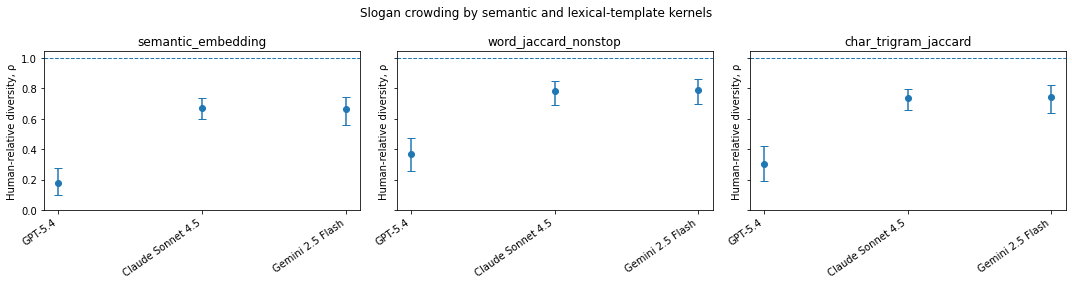

In [42]:
def plot_slogan_kernel_rho_comparison(
    comparison_df: pd.DataFrame,
    save_path: Optional[Path] = None,
):
    plot_df = comparison_df.copy()

    kernel_order = [
        "semantic_embedding",
        "word_jaccard_nonstop",
        "char_trigram_jaccard",
    ]

    model_order = ["GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]

    fig, axes = plt.subplots(1, len(kernel_order), figsize=(15, 4), sharey=True)

    for ax, kernel_name in zip(axes, kernel_order):
        sub = plot_df[plot_df["kernel_name"] == kernel_name].copy()

        sub["model_label"] = pd.Categorical(
            sub["model_label"],
            categories=model_order,
            ordered=True,
        )
        sub = sub.sort_values("model_label")

        x = np.arange(len(sub))
        y = sub["rho"].to_numpy(dtype=float)
        yerr_low = y - sub["rho_95ci_low"].to_numpy(dtype=float)
        yerr_high = sub["rho_95ci_high"].to_numpy(dtype=float) - y

        ax.errorbar(
            x,
            y,
            yerr=[yerr_low, yerr_high],
            fmt="o",
            capsize=4,
        )

        ax.axhline(1.0, linestyle="--", linewidth=1)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["model_label"], rotation=35, ha="right")
        ax.set_title(kernel_name)
        ax.set_ylabel("Human-relative diversity, ρ")
        ax.set_ylim(bottom=0)

    fig.suptitle("Slogan crowding by semantic and lexical-template kernels")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_slogan_kernel_rho_comparison(
    slogan_kernel_comparison,
    save_path=FIG_DIR / "slogan_semantic_vs_lexical_kernel_rho.pdf",
)

## 19.11 Inspect repeated lexical templates

This diagnostic table shows which words or trigrams appear most often in human versus AI slogans. It is not the formal crowding statistic, but it helps interpret why lexical crowding may be high.

In [43]:
def count_feature_occurrences(df: pd.DataFrame, feature_col: str, source_label: str) -> pd.DataFrame:
    """
    Count how often each lexical feature appears across response rows.
    """
    rows = []

    for _, row in df.iterrows():
        text_id = int(row["lexical_text_id"])

        if feature_col == "word_set":
            features = unique_slogan_text_df.loc[text_id, "word_set"]
        elif feature_col == "char_trigram_set":
            features = unique_slogan_text_df.loc[text_id, "char_trigram_set"]
        else:
            raise ValueError(f"Unknown feature_col: {feature_col}")

        for f in features:
            rows.append({
                "feature": f,
                "source_group": source_label,
            })

    if not rows:
        return pd.DataFrame(columns=["feature", "source_group", "n"])

    return (
        pd.DataFrame(rows)
        .groupby(["source_group", "feature"], as_index=False)
        .size()
        .rename(columns={"size": "n"})
        .sort_values(["source_group", "n"], ascending=[True, False])
        .reset_index(drop=True)
    )


feature_count_dfs = []

# Human.
feature_count_dfs.append(
    count_feature_occurrences(
        slogan_df.query("source_type == 'human'"),
        feature_col="word_set",
        source_label="Human",
    )
)

# AI by model.
for model_label in sorted(slogan_df.query("source_type == 'ai'")["model_label"].unique()):
    feature_count_dfs.append(
        count_feature_occurrences(
            slogan_df.query("source_type == 'ai' and model_label == @model_label"),
            feature_col="word_set",
            source_label=model_label,
        )
    )

word_feature_counts = pd.concat(feature_count_dfs, ignore_index=True)

top_word_features = (
    word_feature_counts
    .groupby("source_group", group_keys=False)
    .head(20)
    .reset_index(drop=True)
)

top_word_features.to_csv(
    TABLE_DIR / "slogan_top_word_features_by_source.csv",
    index=False,
)

display(top_word_features)

,source_group,feature,n
0,Human,phone,78
1,Human,life,42
2,Human,world,37
3,Human,smart,36
4,Human,future,31
...,...,...,...
71,Gemini 2.5 Flash,connected,1
72,Gemini 2.5 Flash,edge,1
73,Gemini 2.5 Flash,enhanced,1
74,Gemini 2.5 Flash,everyday,1


## 19.12 Save full slogan lexical-template outputs

We save the bootstrap distributions, summary tables, and feature diagnostics for later manuscript drafting.

In [44]:
slogan_lex_boot_path = SLOGAN_LEX_DIR / "slogan_lexical_template_bootstrap.pkl"
slogan_lex_summary_path = SLOGAN_LEX_DIR / "slogan_lexical_template_summary.csv"
slogan_kernel_comparison_path = SLOGAN_LEX_DIR / "slogan_semantic_vs_lexical_kernel_comparison.csv"

slogan_lex_boot_df.to_pickle(slogan_lex_boot_path)
slogan_lex_summary.to_csv(slogan_lex_summary_path, index=False)
slogan_kernel_comparison.to_csv(slogan_kernel_comparison_path, index=False)

print("Saved:")
print(slogan_lex_boot_path)
print(slogan_lex_summary_path)
print(slogan_kernel_comparison_path)
print(TABLE_DIR / "slogan_lexical_template_crowding_summary.csv")
print(TABLE_DIR / "slogan_lexical_template_crowding_display_table.csv")
print(TABLE_DIR / "slogan_semantic_vs_lexical_kernel_comparison.csv")
print(TABLE_DIR / "slogan_top_word_features_by_source.csv")
print(FIG_DIR / "slogan_semantic_vs_lexical_kernel_rho.pdf")

Saved:
analysis_outputs/crowding_slogan_lexical/slogan_lexical_template_bootstrap.pkl
analysis_outputs/crowding_slogan_lexical/slogan_lexical_template_summary.csv
analysis_outputs/crowding_slogan_lexical/slogan_semantic_vs_lexical_kernel_comparison.csv
analysis_outputs/tables/slogan_lexical_template_crowding_summary.csv
analysis_outputs/tables/slogan_lexical_template_crowding_display_table.csv
analysis_outputs/tables/slogan_semantic_vs_lexical_kernel_comparison.csv
analysis_outputs/tables/slogan_top_word_features_by_source.csv
analysis_outputs/figures/slogan_semantic_vs_lexical_kernel_rho.pdf


# 20. Slogan Lexical-Template Saturation Curves

The semantic crowding analysis showed that 50 AI generations per condition were enough for stable $\kappa_A$ estimates. Because the slogan robustness analysis uses different kernels, we should repeat the same saturation diagnostic for the lexical-template kernels.

For each slogan lexical kernel, we estimate:

$ \kappa(n) $

over increasing sample sizes $n$. If $\kappa_A(n)$ is flat near $n=50$, then 50 AI slogans per model are sufficient for the lexical-template analysis as well.

We use the same sampling logic as the lexical-template bootstrap:

- Human slogans: sample participants first, then one slogan per sampled participant.
- AI slogans: sample generated slogans directly.

## 20.1 Define lexical rarefaction helpers

These functions estimate $\kappa(n)$ for a given lexical kernel.

For AI, we sample response rows from the model’s generated slogans. For humans, we use participant-aware sampling so that prolific human participants do not receive extra weight.

In [45]:
def rarefaction_curve_lexical_ai_pool(
    lexical_ids: np.ndarray,
    feature_sets: List[frozenset],
    n_values: List[int],
    n_boot: int = 500,
    seed: int = 42,
    replace: bool = False,
) -> pd.DataFrame:
    """
    Estimate lexical kappa_A(n) for an AI slogan pool.

    Parameters
    ----------
    lexical_ids:
        Lexical IDs for available AI slogan responses.
    feature_sets:
        List of token/trigram feature sets indexed by lexical_text_id.
    n_values:
        Sample sizes to evaluate.
    n_boot:
        Number of repeated samples per n.
    seed:
        Reproducibility seed.
    replace:
        If False, this is a finite-sample rarefaction curve over the current
        generated AI slogans.
    """
    rng = np.random.default_rng(seed)
    lexical_ids = np.asarray(lexical_ids, dtype=int)

    rows = []

    for n in n_values:
        if n < 2:
            continue
        if (not replace) and n > len(lexical_ids):
            continue

        kappas = []

        for rep in range(n_boot):
            sample_ids = rng.choice(
                lexical_ids,
                size=n,
                replace=replace,
            )

            kappas.append(
                mean_pairwise_set_crowding(
                    lexical_ids=sample_ids,
                    feature_sets=feature_sets,
                )
            )

        kappas = np.asarray(kappas, dtype=float)

        rows.append({
            "n": n,
            "kappa_mean": kappas.mean(),
            "kappa_median": np.median(kappas),
            "kappa_ci_low": np.percentile(kappas, 2.5),
            "kappa_ci_high": np.percentile(kappas, 97.5),
            "n_boot": n_boot,
            "sampling_replace": replace,
        })

    return pd.DataFrame(rows)


def rarefaction_curve_lexical_human_participant_pool(
    participant_to_ids: dict,
    feature_sets: List[frozenset],
    n_values: List[int],
    n_boot: int = 500,
    seed: int = 42,
    replace_participants: bool = False,
) -> pd.DataFrame:
    """
    Estimate lexical kappa_H(n) using participant-aware human sampling.

    For each replicate:
    1. sample n human participants;
    2. sample one slogan from each participant;
    3. compute mean pairwise lexical-template crowding.
    """
    rng = np.random.default_rng(seed)
    participant_ids = np.array(list(participant_to_ids.keys()), dtype=object)

    rows = []

    for n in n_values:
        if n < 2:
            continue
        if (not replace_participants) and n > len(participant_ids):
            continue

        kappas = []

        for rep in range(n_boot):
            sampled_participants = rng.choice(
                participant_ids,
                size=n,
                replace=replace_participants,
            )

            sampled_lexical_ids = []

            for pid in sampled_participants:
                candidate_ids = participant_to_ids[pid]
                chosen_id = rng.choice(candidate_ids, size=1, replace=True)[0]
                sampled_lexical_ids.append(chosen_id)

            kappas.append(
                mean_pairwise_set_crowding(
                    lexical_ids=np.asarray(sampled_lexical_ids, dtype=int),
                    feature_sets=feature_sets,
                )
            )

        kappas = np.asarray(kappas, dtype=float)

        rows.append({
            "n": n,
            "kappa_mean": kappas.mean(),
            "kappa_median": np.median(kappas),
            "kappa_ci_low": np.percentile(kappas, 2.5),
            "kappa_ci_high": np.percentile(kappas, 97.5),
            "n_boot": n_boot,
            "sampling_replace": replace_participants,
        })

    return pd.DataFrame(rows)

## 20.2 Choose the sample-size grid

The main slogan benchmark has 50 AI generations per model. We therefore evaluate all integer values from $n=2$ to $n=50$.

If runtime becomes annoying, switch from `N_VALUES_LEXICAL_FULL` to `N_VALUES_LEXICAL_FAST`.

In [46]:
N_VALUES_LEXICAL_FULL = list(range(2, 51))
N_VALUES_LEXICAL_FAST = [2, 3, 5, 8, 10, 15, 20, 25, 30, 40, 50]

N_VALUES_LEXICAL = N_VALUES_LEXICAL_FULL

# 300 is enough for a diagnostic curve. Increase to 500 for smoother bands.
N_LEXICAL_RAREFACTION_BOOT = 300

print("Number of n values:", len(N_VALUES_LEXICAL))
print("n range:", min(N_VALUES_LEXICAL), "to", max(N_VALUES_LEXICAL))
print("Bootstrap repetitions per n:", N_LEXICAL_RAREFACTION_BOOT)

Number of n values: 49
n range: 2 to 50
Bootstrap repetitions per n: 300


## 20.3 Compute lexical-template saturation curves

This computes $\kappa(n)$ for both lexical kernels:

- `word_jaccard_nonstop`
- `char_trigram_jaccard`

For each kernel, we compute one human curve and one curve per AI model.

In [47]:
slogan_lex_rarefaction_dfs = []

start_time = time.time()

for kernel_name, feature_sets in SLOGAN_LEXICAL_KERNELS.items():

    # Human curve for this kernel.
    max_n_human = min(max(N_VALUES_LEXICAL), len(slogan_human_lex_pool))
    n_values_human = [n for n in N_VALUES_LEXICAL if n <= max_n_human]

    seed_payload = f"human::slogan::{kernel_name}::lexical_rarefaction"
    seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

    human_curve = rarefaction_curve_lexical_human_participant_pool(
        participant_to_ids=slogan_human_lex_pool,
        feature_sets=feature_sets,
        n_values=n_values_human,
        n_boot=N_LEXICAL_RAREFACTION_BOOT,
        seed=seed,
        replace_participants=False,
    )

    human_curve["source_type"] = "human"
    human_curve["model_label"] = "Human"
    human_curve["task_family"] = "slogan"
    human_curve["condition_id"] = "smartphone"
    human_curve["kernel_name"] = kernel_name
    human_curve["available_n"] = len(slogan_human_lex_pool)

    slogan_lex_rarefaction_dfs.append(human_curve)

    print(
        f"Human | {kernel_name:22s} | available_n={len(slogan_human_lex_pool):3d} "
        f"| max_curve_n={max_n_human:3d}"
    )

    # AI curves for this kernel.
    for model_label, ai_ids in slogan_ai_lex_pools.items():
        max_n_ai = min(max(N_VALUES_LEXICAL), len(ai_ids))
        n_values_ai = [n for n in N_VALUES_LEXICAL if n <= max_n_ai]

        seed_payload = f"ai::{model_label}::slogan::{kernel_name}::lexical_rarefaction"
        seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

        ai_curve = rarefaction_curve_lexical_ai_pool(
            lexical_ids=ai_ids,
            feature_sets=feature_sets,
            n_values=n_values_ai,
            n_boot=N_LEXICAL_RAREFACTION_BOOT,
            seed=seed,
            replace=False,
        )

        ai_curve["source_type"] = "ai"
        ai_curve["model_label"] = model_label
        ai_curve["task_family"] = "slogan"
        ai_curve["condition_id"] = "smartphone"
        ai_curve["kernel_name"] = kernel_name
        ai_curve["available_n"] = len(ai_ids)

        slogan_lex_rarefaction_dfs.append(ai_curve)

        print(
            f"AI    | {kernel_name:22s} | {model_label:20s} "
            f"| available_n={len(ai_ids):3d} | max_curve_n={max_n_ai:3d}"
        )

slogan_lex_rarefaction_df = pd.concat(slogan_lex_rarefaction_dfs, ignore_index=True)

elapsed = time.time() - start_time
print(f"\nSlogan lexical rarefaction complete: {slogan_lex_rarefaction_df.shape} rows")
print(f"Elapsed time: {elapsed:.1f} seconds")

slogan_lex_rarefaction_path = TABLE_DIR / "slogan_lexical_kappa_rarefaction_curves.csv"
slogan_lex_rarefaction_df.to_csv(slogan_lex_rarefaction_path, index=False)

print("Saved:", slogan_lex_rarefaction_path)
display(slogan_lex_rarefaction_df.head())

Human | word_jaccard_nonstop   | available_n= 95 | max_curve_n= 50
AI    | word_jaccard_nonstop   | Claude Sonnet 4.5    | available_n= 50 | max_curve_n= 50
AI    | word_jaccard_nonstop   | GPT-5.4              | available_n= 50 | max_curve_n= 50
AI    | word_jaccard_nonstop   | Gemini 2.5 Flash     | available_n= 50 | max_curve_n= 50
Human | char_trigram_jaccard   | available_n= 95 | max_curve_n= 50
AI    | char_trigram_jaccard   | Claude Sonnet 4.5    | available_n= 50 | max_curve_n= 50
AI    | char_trigram_jaccard   | GPT-5.4              | available_n= 50 | max_curve_n= 50
AI    | char_trigram_jaccard   | Gemini 2.5 Flash     | available_n= 50 | max_curve_n= 50

Slogan lexical rarefaction complete: (392, 13) rows
Elapsed time: 48.4 seconds
Saved: analysis_outputs/tables/slogan_lexical_kappa_rarefaction_curves.csv


,n,kappa_mean,kappa_median,kappa_ci_low,kappa_ci_high,n_boot,sampling_replace,source_type,model_label,task_family,condition_id,kernel_name,available_n
0,2,0.007028,0.0,0.0,0.146875,300,False,human,Human,slogan,smartphone,word_jaccard_nonstop,95
1,3,0.010011,0.0,0.0,0.111111,300,False,human,Human,slogan,smartphone,word_jaccard_nonstop,95
2,4,0.011206,0.0,0.0,0.083333,300,False,human,Human,slogan,smartphone,word_jaccard_nonstop,95
3,5,0.012755,0.0,0.0,0.077000,300,False,human,Human,slogan,smartphone,word_jaccard_nonstop,95
4,6,0.010633,0.0,0.0,0.055556,300,False,human,Human,slogan,smartphone,word_jaccard_nonstop,95


## 20.4 Plot lexical-template $\kappa(n)$ curves

These plots show whether lexical-template crowding stabilizes by $n=50$.

The dashed vertical line marks the current AI sample size of 50 generations per model.

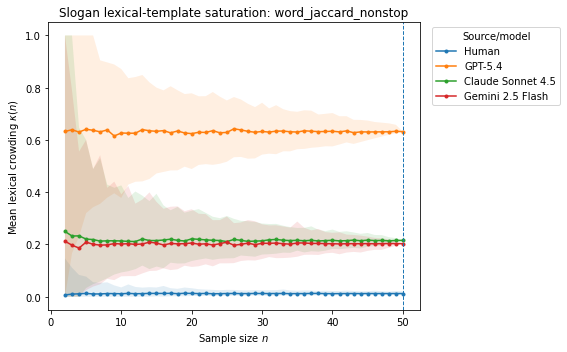

Saved: analysis_outputs/figures/slogan_lexical_kappa_rarefaction__word_jaccard_nonstop.pdf


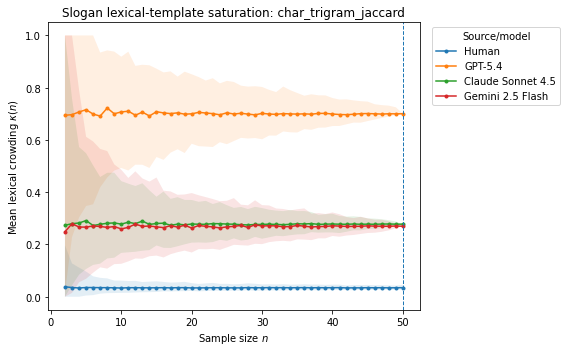

Saved: analysis_outputs/figures/slogan_lexical_kappa_rarefaction__char_trigram_jaccard.pdf


In [48]:
def plot_slogan_lexical_rarefaction_curves(
    rarefaction_df: pd.DataFrame,
    save_dir: Path,
):
    kernel_order = [
        "word_jaccard_nonstop",
        "char_trigram_jaccard",
    ]

    model_order = ["Human", "GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]

    for kernel_name in kernel_order:
        sub = rarefaction_df[rarefaction_df["kernel_name"] == kernel_name].copy()

        if sub.empty:
            continue

        fig, ax = plt.subplots(figsize=(8, 5))

        for model_label in model_order:
            m = sub[sub["model_label"] == model_label].sort_values("n")

            if m.empty:
                continue

            ax.plot(
                m["n"],
                m["kappa_mean"],
                marker="o",
                markersize=3,
                linewidth=1.5,
                label=model_label,
            )

            ax.fill_between(
                m["n"].to_numpy(dtype=float),
                m["kappa_ci_low"].to_numpy(dtype=float),
                m["kappa_ci_high"].to_numpy(dtype=float),
                alpha=0.12,
            )

        ax.axvline(50, linestyle="--", linewidth=1)
        ax.set_xlabel("Sample size $n$")
        ax.set_ylabel("Mean lexical crowding $\\kappa(n)$")
        ax.set_title(f"Slogan lexical-template saturation: {kernel_name}")
        ax.legend(title="Source/model", bbox_to_anchor=(1.02, 1), loc="upper left")

        fig.tight_layout()

        out_path = save_dir / f"slogan_lexical_kappa_rarefaction__{kernel_name}.pdf"
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Saved:", out_path)


plot_slogan_lexical_rarefaction_curves(
    slogan_lex_rarefaction_df,
    FIG_DIR,
)

## 20.5 Quantify recent drift near $n=50$

We compute the recent drift from $n=40$ to $n=50$:

$ \Delta\kappa_{40\to50} = \kappa(50)-\kappa(40) $

and the relative drift:

$ \frac{|\kappa(50)-\kappa(40)|}{|\kappa(50)|} $

For deciding whether more AI slogans are needed, focus on AI rows. Values below roughly 1–2% suggest that the lexical-template estimates have stabilized.

In [49]:
def compute_lexical_recent_drift(
    curve_df: pd.DataFrame,
    n_low: int = 40,
    n_high: int = 50,
) -> pd.DataFrame:
    """
    Compare kappa at n_low and n_high for each lexical rarefaction curve.
    """
    rows = []

    group_cols = ["source_type", "model_label", "task_family", "condition_id", "kernel_name"]

    for keys, g in curve_df.groupby(group_cols, dropna=False):
        g = g.set_index("n").sort_index()

        if n_low not in g.index or n_high not in g.index:
            continue

        k_low = float(g.loc[n_low, "kappa_mean"])
        k_high = float(g.loc[n_high, "kappa_mean"])

        kappa_change = k_high - k_low
        relative_abs_change = abs(kappa_change) / max(abs(k_high), 1e-12)

        row = dict(zip(group_cols, keys))
        row.update({
            "n_low": n_low,
            "n_high": n_high,
            "kappa_low": k_low,
            "kappa_high": k_high,
            "kappa_change": kappa_change,
            "relative_abs_change": relative_abs_change,
            "flag_relative_change_gt_1pct": relative_abs_change > 0.01,
            "flag_relative_change_gt_2pct": relative_abs_change > 0.02,
        })

        rows.append(row)

    return pd.DataFrame(rows)


slogan_lex_drift = compute_lexical_recent_drift(
    slogan_lex_rarefaction_df,
    n_low=40,
    n_high=50,
)

slogan_lex_drift = slogan_lex_drift.sort_values(
    ["kernel_name", "source_type", "model_label"]
).reset_index(drop=True)

slogan_lex_drift_path = TABLE_DIR / "slogan_lexical_kappa_rarefaction_recent_drift.csv"
slogan_lex_drift.to_csv(slogan_lex_drift_path, index=False)

print("Saved:", slogan_lex_drift_path)
display(slogan_lex_drift)

Saved: analysis_outputs/tables/slogan_lexical_kappa_rarefaction_recent_drift.csv


,source_type,model_label,task_family,condition_id,kernel_name,n_low,n_high,kappa_low,kappa_high,kappa_change,relative_abs_change,flag_relative_change_gt_1pct,flag_relative_change_gt_2pct
0,ai,Claude Sonnet 4.5,slogan,smartphone,char_trigram_jaccard,40,50,0.278445,0.277856,-0.000589,0.002121,False,False
1,ai,GPT-5.4,slogan,smartphone,char_trigram_jaccard,40,50,0.699315,0.700344,0.001029,0.001469,False,False
2,ai,Gemini 2.5 Flash,slogan,smartphone,char_trigram_jaccard,40,50,0.271577,0.269846,-0.001732,0.006417,False,False
3,human,Human,slogan,smartphone,char_trigram_jaccard,40,50,0.034526,0.034643,0.000117,0.003373,False,False
4,ai,Claude Sonnet 4.5,slogan,smartphone,word_jaccard_nonstop,40,50,0.215956,0.215540,-0.000416,0.001928,False,False
5,ai,GPT-5.4,slogan,smartphone,word_jaccard_nonstop,40,50,0.633452,0.631891,-0.001561,0.002470,False,False
6,ai,Gemini 2.5 Flash,slogan,smartphone,word_jaccard_nonstop,40,50,0.202868,0.203116,0.000248,0.001220,False,False
7,human,Human,slogan,smartphone,word_jaccard_nonstop,40,50,0.011760,0.012197,0.000437,0.035840,True,True


## 20.6 Decision table: do we need more AI slogans for lexical-template kernels?

This table translates the recent-drift diagnostic into a simple decision aid.

This is not a formal stopping rule, but it gives a principled answer to whether collecting more AI slogans is likely to change the lexical-template results.

In [50]:
def assign_lexical_more_data_recommendation(row: pd.Series) -> str:
    """
    Simple recommendation based on recent drift in kappa(n).
    """
    if row["source_type"] != "ai":
        return "human diagnostic only"

    if row["relative_abs_change"] <= 0.01:
        return "likely enough AI data"

    if row["relative_abs_change"] <= 0.02:
        return "inspect plot; probably enough if curve is flat"

    return "consider more AI generations"


slogan_lex_ai_decision = slogan_lex_drift.query("source_type == 'ai'").copy()

slogan_lex_ai_decision["recommendation"] = slogan_lex_ai_decision.apply(
    assign_lexical_more_data_recommendation,
    axis=1,
)

slogan_lex_ai_decision = slogan_lex_ai_decision[
    [
        "kernel_name",
        "model_label",
        "task_family",
        "n_low",
        "n_high",
        "kappa_low",
        "kappa_high",
        "kappa_change",
        "relative_abs_change",
        "recommendation",
    ]
].sort_values(["recommendation", "kernel_name", "model_label"])

slogan_lex_ai_decision_path = TABLE_DIR / "slogan_lexical_more_data_decision_from_rarefaction.csv"
slogan_lex_ai_decision.to_csv(slogan_lex_ai_decision_path, index=False)

print("Saved:", slogan_lex_ai_decision_path)
display(slogan_lex_ai_decision)

Saved: analysis_outputs/tables/slogan_lexical_more_data_decision_from_rarefaction.csv


,kernel_name,model_label,task_family,n_low,n_high,kappa_low,kappa_high,kappa_change,relative_abs_change,recommendation
0,char_trigram_jaccard,Claude Sonnet 4.5,slogan,40,50,0.278445,0.277856,-0.000589,0.002121,likely enough AI data
1,char_trigram_jaccard,GPT-5.4,slogan,40,50,0.699315,0.700344,0.001029,0.001469,likely enough AI data
2,char_trigram_jaccard,Gemini 2.5 Flash,slogan,40,50,0.271577,0.269846,-0.001732,0.006417,likely enough AI data
4,word_jaccard_nonstop,Claude Sonnet 4.5,slogan,40,50,0.215956,0.215540,-0.000416,0.001928,likely enough AI data
5,word_jaccard_nonstop,GPT-5.4,slogan,40,50,0.633452,0.631891,-0.001561,0.002470,likely enough AI data
6,word_jaccard_nonstop,Gemini 2.5 Flash,slogan,40,50,0.202868,0.203116,0.000248,0.001220,likely enough AI data


## 20.7 Save lexical rarefaction objects

We save the lexical rarefaction curves and decision tables so that the diagnostic can be reported or moved to the supplement.

In [51]:
slogan_lex_rarefaction_pkl = SLOGAN_LEX_DIR / "slogan_lexical_kappa_rarefaction_curves.pkl"
slogan_lex_drift_pkl = SLOGAN_LEX_DIR / "slogan_lexical_kappa_rarefaction_recent_drift.pkl"

slogan_lex_rarefaction_df.to_pickle(slogan_lex_rarefaction_pkl)
slogan_lex_drift.to_pickle(slogan_lex_drift_pkl)

print("Saved:")
print(slogan_lex_rarefaction_pkl)
print(slogan_lex_drift_pkl)
print(TABLE_DIR / "slogan_lexical_kappa_rarefaction_curves.csv")
print(TABLE_DIR / "slogan_lexical_kappa_rarefaction_recent_drift.csv")
print(TABLE_DIR / "slogan_lexical_more_data_decision_from_rarefaction.csv")
print(FIG_DIR / "slogan_lexical_kappa_rarefaction__word_jaccard_nonstop.pdf")
print(FIG_DIR / "slogan_lexical_kappa_rarefaction__char_trigram_jaccard.pdf")

Saved:
analysis_outputs/crowding_slogan_lexical/slogan_lexical_kappa_rarefaction_curves.pkl
analysis_outputs/crowding_slogan_lexical/slogan_lexical_kappa_rarefaction_recent_drift.pkl
analysis_outputs/tables/slogan_lexical_kappa_rarefaction_curves.csv
analysis_outputs/tables/slogan_lexical_kappa_rarefaction_recent_drift.csv
analysis_outputs/tables/slogan_lexical_more_data_decision_from_rarefaction.csv
analysis_outputs/figures/slogan_lexical_kappa_rarefaction__word_jaccard_nonstop.pdf
analysis_outputs/figures/slogan_lexical_kappa_rarefaction__char_trigram_jaccard.pdf


# 21. Story Narrative-Crowding Analysis Using Plot Synopses

The primary story analysis computes semantic crowding over the full story text. Full-text similarity can mix several sources of resemblance: plot, setting, prose style, genre conventions, and surface phrasing.

Here we run a narrative-level robustness kernel. Each story has already been converted into a one-sentence plot synopsis using a fixed deterministic summarization prompt. We compute semantic crowding over the synopsis embeddings:

$K^{plot}_k(x,y)=\frac{1+\cos(f(s(x)),f(s(y)))}{2}$

where $s(x)$ is the one-sentence plot synopsis of story $x$.

This asks whether AI stories are still more crowded than matched human stories when we measure similarity at the plot/narrative-content level rather than over the full prose.

## 21.1 Load story synopsis data

The synopsis-generation notebook saved a row-level file containing all human and AI stories, their original text, and their generated one-sentence plot synopsis.

For the main benchmark, we only need the story rows that appear in `main_analysis_df`, i.e., human story responses plus neutral/default-temperature AI story responses.

In [52]:
SYNOPSIS_MODEL_FOR_ANALYSIS = "gpt-5.4"

STORY_SYNOPSIS_DIR = ANALYSIS_DIR / "story_synopses"
STORY_SYNOPSIS_FINAL_DIR = STORY_SYNOPSIS_DIR / "final"
STORY_PLOT_DIR = ANALYSIS_DIR / "crowding_story_plot"

STORY_PLOT_DIR.mkdir(parents=True, exist_ok=True)

story_synopsis_path = (
    STORY_SYNOPSIS_FINAL_DIR
    / f"openai__{SYNOPSIS_MODEL_FOR_ANALYSIS}__story_plot_synopses_merged.pkl"
)

assert story_synopsis_path.exists(), f"Missing synopsis file: {story_synopsis_path}"

story_synopsis_all_df = pd.read_pickle(story_synopsis_path)

print("Loaded story synopsis file:", story_synopsis_path)
print("Story synopsis rows:", story_synopsis_all_df.shape)

display(story_synopsis_all_df.head())
display(story_synopsis_all_df["has_synopsis"].value_counts(dropna=False))

Loaded story synopsis file: analysis_outputs/story_synopses/final/openai__gpt-5.4__story_plot_synopses_merged.pkl
Story synopsis rows: (9357, 21)


,source_type,provider,model,analysis_scenario_name,scenario_name,temperature,persona_id,condition_id,story_prompt,participant_id,story_text,story_row_idx,story_uid,story_word_count,story_text_uid,synopsis,raw_synopsis,synopsis_model,synopsis_response_id,synopsis_usage,has_synopsis
0,human,human,human,human,human,NaN,NaN,10491,A short Horror story . Something to chill the bones in one hundred words or less .,10880,"I was running . Tree branches whipped past my face , and I felt the hot warmth of my blood mix with the cold sweat . Footsteps behind me...",0,f4a9d7a3b0e9b00d78193112,116,23432105eff14111d6b15c34,A fleeing narrator is relentlessly pursued through the dark by a sinister Gingerbread Man who keeps pace no matter how fast they run and...,A fleeing narrator is relentlessly pursued through the dark by a sinister Gingerbread Man who keeps pace no matter how fast they run and...,gpt-5.4,resp_08231817eda170420069f435ed9f108190baf44074f7ac6e9b,"{'input_tokens': 284, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 35, 'output_tokens_details': {'reasoning_tokens': 0...",True
1,human,human,human,human,human,NaN,NaN,10491,A short Horror story . Something to chill the bones in one hundred words or less .,11118,"I breathed heavily under the covers . A creak made me jump unwillingly . Dad was n't here , so he did n't check the closet . What if *it...",1,2f4a43b282f6c3388f992cfe,111,0c36d334900ad801f4c0d215,"A frightened child checks the closet for a feared monster, only to discover too late that a doppelganger monster has been hiding in the ...","A frightened child checks the closet for a feared monster, only to discover too late that a doppelganger monster has been hiding in the ...",gpt-5.4,resp_0c0132015fcd881a0069f435d105248193bca01d7471e57a47,"{'input_tokens': 286, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 41, 'output_tokens_details': {'reasoning_tokens': 0...",True
2,human,human,human,human,human,NaN,NaN,10491,A short Horror story . Something to chill the bones in one hundred words or less .,15787,"I pound my fists against the old wooden door within the creaking old house I found in the woods . The wind had blown it shut , I told my...",2,8c9a5d5a6cef6db6cbad6597,133,109fd53c9a1da4b3e91ea992,"After becoming trapped in an old house in the woods, the narrator tries to dismiss the ominous stains and scratches around them until a ...","After becoming trapped in an old house in the woods, the narrator tries to dismiss the ominous stains and scratches around them until a ...",gpt-5.4,resp_0f82f141a70e27cc0069f435913ab08196b1ac515afc4230c0,"{'input_tokens': 277, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 42, 'output_tokens_details': {'reasoning_tokens': 0...",True
3,human,human,human,human,human,NaN,NaN,10491,A short Horror story . Something to chill the bones in one hundred words or less .,28897,The town square sparkled like the 4th of July sky . Children 's laughter filled the air ; old friends were catching up . Hearing them ma...,3,c07604df10908a34465f4d69,125,94c1583b6d345dcbe280ae96,"At a festive town gathering, a man condemned for surrendering in war reflects on his family and regrets his cowardice before being publi...","At a festive town gathering, a man condemned for surrendering in war reflects on his family and regrets his cowardice before being publi...",gpt-5.4,resp_021a331e8c75e3f90069f435cdc8448195b96f4b909878bd0f,"{'input_tokens': 275, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 33, 'output_tokens_details': {'reasoning_tokens': 0...",True
4,human,human,human,human,human,NaN,NaN,10491,A short Horror story . Something to chill the bones in one hundred words or less .,32611,"It had been a year since the accident , and not one day passed I did n't think of Lindsay . The fiery wreck off Intersate 15 that took m...",4,724837d9bd9001362d6c5350,241,c8298a2af4ce36f3dcd16621,"A year after a car crash killed his fiancée Lindsay and left him maimed, a gri

has_synopsis
True    9357
Name: count, dtype: int64

## 21.2 Build a clean story-text-to-synopsis map

The synopsis-generation notebook summarized each unique story text once and then mapped the synopsis back to all rows. For the main analysis, the safest join key is exact `response_text` / `story_text`.

If two rows have the exact same story text, they should receive the same synopsis. This preserves duplicate generation attempts while avoiding duplicate synopsis-generation costs.

In [53]:
# Keep only successful synopses.
story_synopsis_success = story_synopsis_all_df.query("has_synopsis == True").copy()

# Build text-level map: exact story text -> synopsis.
story_text_to_synopsis_df = (
    story_synopsis_success[
        [
            "story_text",
            "story_text_uid",
            "synopsis",
            "synopsis_model",
        ]
    ]
    .drop_duplicates("story_text")
    .reset_index(drop=True)
)

print("Unique story texts with synopses:", len(story_text_to_synopsis_df))

# Check that exact story text maps to exactly one synopsis.
synopsis_map_check = (
    story_synopsis_success
    .groupby("story_text", dropna=False)
    .agg(n_synopses=("synopsis", "nunique"))
    .reset_index()
)

problematic_maps = synopsis_map_check.query("n_synopses > 1")
print("Story texts mapping to multiple synopses:", len(problematic_maps))
assert len(problematic_maps) == 0, "Some exact story texts map to multiple synopses."

display(story_text_to_synopsis_df.head())

Unique story texts with synopses: 9356
Story texts mapping to multiple synopses: 0


,story_text,story_text_uid,synopsis,synopsis_model
0,"I was running . Tree branches whipped past my face , and I felt the hot warmth of my blood mix with the cold sweat . Footsteps behind me...",23432105eff14111d6b15c34,A fleeing narrator is relentlessly pursued through the dark by a sinister Gingerbread Man who keeps pace no matter how fast they run and...,gpt-5.4
1,"I breathed heavily under the covers . A creak made me jump unwillingly . Dad was n't here , so he did n't check the closet . What if *it...",0c36d334900ad801f4c0d215,"A frightened child checks the closet for a feared monster, only to discover too late that a doppelganger monster has been hiding in the ...",gpt-5.4
2,"I pound my fists against the old wooden door within the creaking old house I found in the woods . The wind had blown it shut , I told my...",109fd53c9a1da4b3e91ea992,"After becoming trapped in an old house in the woods, the narrator tries to dismiss the ominous stains and scratches around them until a ...",gpt-5.4
3,The town square sparkled like the 4th of July sky . Children 's laughter filled the air ; old friends were catching up . Hearing them ma...,94c1583b6d345dcbe280ae96,"At a festive town gathering, a man condemned for surrendering in war reflects on his family and regrets his cowardice before being publi...",gpt-5.4
4,"It had been a year since the accident , and not one day passed I did n't think of Lindsay . The fiery wreck off Intersate 15 that took m...",c8298a2af4ce36f3dcd16621,"A year after a car crash killed his fiancée Lindsay and left him maimed, a grieving survivor stops taking his pain medication on the ann...",gpt-5.4


## 21.3 Merge synopses onto main story-analysis rows

We now isolate the main-benchmark story rows from `main_analysis_df` and merge each row to its one-sentence synopsis.

This keeps the same main benchmark scope as the full-text story analysis:

- human story rows;
- OpenAI, Claude, and Gemini neutral/default-temperature story rows;
- the same three story prompt conditions.

In [54]:
story_main_df = main_analysis_df.query("task_family == 'story'").copy()

# Defensive cleanup.
story_main_df["condition_id"] = normalize_condition_id_series(story_main_df["condition_id"])
story_main_df["response_text"] = story_main_df["response_text"].fillna("").astype(str)

story_plot_df = story_main_df.merge(
    story_text_to_synopsis_df,
    left_on="response_text",
    right_on="story_text",
    how="left",
    validate="many_to_one",
)

story_plot_df["has_synopsis"] = story_plot_df["synopsis"].notna()

print("Main story rows:", story_main_df.shape)
print("Main story rows with synopsis:", int(story_plot_df["has_synopsis"].sum()))
print("Main story rows missing synopsis:", int((~story_plot_df["has_synopsis"]).sum()))

display(
    story_plot_df
    .groupby(["source_type", "model_label", "condition_id"], dropna=False)
    .agg(
        n_rows=("response_text", "size"),
        n_with_synopsis=("has_synopsis", "sum"),
        n_unique_story_texts=("response_text", "nunique"),
        n_unique_synopses=("synopsis", "nunique"),
    )
    .reset_index()
    .sort_values(["source_type", "model_label", "condition_id"])
)

missing_synopsis_rows = story_plot_df.query("not has_synopsis").copy()
display(missing_synopsis_rows.head())

assert story_plot_df["has_synopsis"].all(), (
    "Some main story rows are missing synopses. Backfill these before running plot-kernel analysis."
)

Main story rows: (537, 16)
Main story rows with synopsis: 537
Main story rows missing synopsis: 0


,source_type,model_label,condition_id,n_rows,n_with_synopsis,n_unique_story_texts,n_unique_synopses
0,ai,Claude Sonnet 4.5,10491,50,50,50,50
1,ai,Claude Sonnet 4.5,93742,50,50,50,50
2,ai,Claude Sonnet 4.5,93855,50,50,50,50
3,ai,GPT-5.4,10491,50,50,50,50
4,ai,GPT-5.4,93742,50,50,50,50
5,ai,GPT-5.4,93855,50,50,50,50
6,ai,Gemini 2.5 Flash,10491,50,50,50,50
7,ai,Gemini 2.5 Flash,93742,50,50,50,50
8,ai,Gemini 2.5 Flash,93855,50,50,50,50
9,human,Human,10491,35,35,35,35


,task_family,source_type,provider,model,condition_id,condition_label,analysis_scenario_name,temperature,response_text,response_word_count,bucket_id,bucket_key,participant_id,model_label,analysis_row_id,embedding_text_id,story_text,story_text_uid,synopsis,synopsis_model,has_synopsis


## 21.4 Inspect synopsis examples

Before treating the synopsis kernel as a robustness check, we inspect a few original stories and their generated synopses. This is not a filtering step; it is a validity diagnostic.

In [55]:
example_cols = [
    "source_type",
    "model_label",
    "condition_id",
    "response_text",
    "synopsis",
]

display(
    story_plot_df[example_cols]
    .sample(n=min(12, len(story_plot_df)), random_state=42)
)

,source_type,model_label,condition_id,response_text,synopsis
492,ai,Gemini 2.5 Flash,93742,"The ripcord in his hand was useless, a colorful string attached to a death trap. Below him, the world rushed up, a blur of greens and br...","As his parachute fails during a fatal fall, a man desperately tries to save himself but can only think of the woman he loves as death ru..."
73,human,Human,93855,"He had spent his whole life living paycheque to paycheque . <newline> <newline> In his last moments George felt nothing but a cold , sic...","After a century of scraping by and ending up alone, in debt, and trapped in a house he never liked, George dies overwhelmed by regret as..."
347,ai,Claude Sonnet 4.5,93855,"# 100 Years in 10 Words\n\nBorn screaming, lived loudly, loved fiercely, died silently, left everything.\n\n---\n\n# The Last 10 Seconds...","As an elderly woman dies in a hospital room holding her grandson's hand, she drifts through comforting visions from her past and passes ..."
86,human,Human,93855,Will ’ s years in the navy were the best of times . <newline> <newline> He woke up to the sound of gunfire mingling with the screams in ...,"An aging former navy man named Will, weakened by time, faces a violent attack on his home in which his beloved son Peter lies dead, and ..."
455,ai,Gemini 2.5 Flash,10491,"The old house breathed. Not with air, but with a palpable stillness that pressed down. I was alone, or so I thought, until the floorboar...","Alone in an old house, the narrator hears impossible footsteps and a childlike giggle coming from a nailed-shut attic, then panics and f..."
77,human,Human,93855,"`` Oh well . Next time maybe ? No , definitely next time . Yeah . '' <newline> <newline> <newline> `` Next time maybe ? '' Oh come on , ...","A person berates themselves after another failed, half-hearted attempt at an unspecified task, spiraling into self-criticism and fearing..."
446,ai,Gemini 2.5 Flash,93855,"**100 years:** Lived, loved, lost, learned, laughed, cried, endured, remembered, departed, peace.\n\n**10 seconds:** A final breath hitc...","After a century of experiencing love, loss, joy, and hardship, a person reaches the end of life, peacefully lets go amid comforting visi..."
529,ai,Gemini 2.5 Flash,93855,"[ FF ] She lived, loved, lost, learned, laughed, feared, hoped, helped, died.\n\nThe nurse’s hand was soft and cool as it smoothed the h...","As she lies dying in a hospital bed, a woman reflects on the love, loss, and small joys of her life before peacefully passing away."
89,ai,GPT-5.4,10491,I woke to knocking beneath my bed.\n\nThree soft taps. Pause. Three more.\n\nMy apartment is on the third floor. There is nothing under ...,"Alone in a third-floor apartment, a person hears a child whispering from beneath the bed that someone is searching for him, and when a l..."
208,ai,GPT-5.4,10491,"At 2:13 a.m., the baby monitor crackled.\n\n“Mommy,” my daughter whispered, “there’s a woman in my room.”\n\nHalf asleep, I checked the ...","After a baby monitor captures her daughter warning that a woman is in the room, a mother discovers on the screen that a silent double wi..."


## 21.5 Compute or load cached synopsis embeddings

We embed unique synopsis texts once, cache them to disk, and then map each story row to a `synopsis_embedding_text_id`.

The embedding model is the same as the primary semantic analysis unless changed intentionally.

In [56]:
unique_synopsis_df = (
    story_plot_df[["synopsis"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

unique_synopsis_df["synopsis_embedding_text_id"] = np.arange(len(unique_synopsis_df), dtype=int)
unique_synopsis_texts = unique_synopsis_df["synopsis"].tolist()

synopsis_cache_id = short_hash_texts(
    unique_synopsis_texts,
    f"{EMBEDDING_MODEL_NAME}::story_plot_synopsis::{SYNOPSIS_MODEL_FOR_ANALYSIS}",
)

synopsis_embedding_matrix_path = (
    EMBED_DIR / f"story_plot_synopsis_embeddings__{synopsis_cache_id}.npy"
)
synopsis_embedding_texts_path = (
    EMBED_DIR / f"story_plot_synopsis_embedding_texts__{synopsis_cache_id}.csv"
)

print("Unique synopsis texts:", len(unique_synopsis_texts))
print("Synopsis embedding cache:", synopsis_embedding_matrix_path)

if synopsis_embedding_matrix_path.exists() and synopsis_embedding_texts_path.exists():
    print("Loading cached synopsis embeddings...")
    synopsis_embedding_matrix = np.load(synopsis_embedding_matrix_path)
    cached_synopsis_text_df = pd.read_csv(synopsis_embedding_texts_path)

    assert cached_synopsis_text_df["synopsis"].tolist() == unique_synopsis_texts
else:
    print("Computing synopsis embeddings...")
    synopsis_embedding_matrix = embedding_model.encode(
        unique_synopsis_texts,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    )

    synopsis_embedding_matrix = np.asarray(synopsis_embedding_matrix, dtype=np.float32)

    np.save(synopsis_embedding_matrix_path, synopsis_embedding_matrix)
    unique_synopsis_df.to_csv(synopsis_embedding_texts_path, index=False)

print("Synopsis embedding matrix shape:", synopsis_embedding_matrix.shape)

story_plot_df = story_plot_df.merge(
    unique_synopsis_df,
    on="synopsis",
    how="left",
    validate="many_to_one",
)

assert story_plot_df["synopsis_embedding_text_id"].notna().all()
story_plot_df["synopsis_embedding_text_id"] = story_plot_df["synopsis_embedding_text_id"].astype(int)

display(story_plot_df.head())

Unique synopsis texts: 537
Synopsis embedding cache: analysis_outputs/embeddings/story_plot_synopsis_embeddings__26abbfebfb973959.npy
Loading cached synopsis embeddings...
Synopsis embedding matrix shape: (537, 768)


,task_family,source_type,provider,model,condition_id,condition_label,analysis_scenario_name,temperature,response_text,response_word_count,bucket_id,bucket_key,participant_id,model_label,analysis_row_id,embedding_text_id,story_text,story_text_uid,synopsis,synopsis_model,has_synopsis,synopsis_embedding_text_id
0,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"I was running . Tree branches whipped past my face , and I felt the hot warmth of my blood mix with the cold sweat . Footsteps behind me...",116,<NA>,NaN,10880,Human,0,0,"I was running . Tree branches whipped past my face , and I felt the hot warmth of my blood mix with the cold sweat . Footsteps behind me...",23432105eff14111d6b15c34,A fleeing narrator is relentlessly pursued through the dark by a sinister Gingerbread Man who keeps pace no matter how fast they run and...,gpt-5.4,True,0
1,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"I breathed heavily under the covers . A creak made me jump unwillingly . Dad was n't here , so he did n't check the closet . What if *it...",111,<NA>,NaN,11118,Human,1,1,"I breathed heavily under the covers . A creak made me jump unwillingly . Dad was n't here , so he did n't check the closet . What if *it...",0c36d334900ad801f4c0d215,"A frightened child checks the closet for a feared monster, only to discover too late that a doppelganger monster has been hiding in the ...",gpt-5.4,True,1
2,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"I pound my fists against the old wooden door within the creaking old house I found in the woods . The wind had blown it shut , I told my...",133,<NA>,NaN,15787,Human,2,2,"I pound my fists against the old wooden door within the creaking old house I found in the woods . The wind had blown it shut , I told my...",109fd53c9a1da4b3e91ea992,"After becoming trapped in an old house in the woods, the narrator tries to dismiss the ominous stains and scratches around them until a ...",gpt-5.4,True,2
3,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,The town square sparkled like the 4th of July sky . Children 's laughter filled the air ; old friends were catching up . Hearing them ma...,125,<NA>,NaN,28897,Human,3,3,The town square sparkled like the 4th of July sky . Children 's laughter filled the air ; old friends were catching up . Hearing them ma...,94c1583b6d345dcbe280ae96,"At a festive town gathering, a man condemned for surrendering in war reflects on his family and regrets his cowardice before being publi...",gpt-5.4,True,3
4,story,human,human,human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"It had been a year since the accident , and not one day passed I did n't think of Lindsay . The fiery wreck off Intersate 15 that took m...",241,<NA>,NaN,32611,Human,4,4,"It had been a year since the accident , and not one day passed I did n't think of Lindsay . The fiery wreck off Intersate 15 that took m...",c8298a2af4ce36f3dcd16621,"A year after a car crash killed his fiancée Lindsay and left him maimed, a grieving survivor stops taking his pain medication on the ann...",gpt-5.4,True,4


## 21.6 Build story plot-kernel sampling pools

The sampling design mirrors the main story analysis.

For humans, we use participant-aware sampling. Since each human story participant contributes one story in a condition, this is equivalent to sampling human story rows.

For AI, each row is one generation attempt. Exact duplicate outputs remain in the data and contribute to crowding if sampled.

In [57]:
def build_human_participant_pools_from_id_col(
    df: pd.DataFrame,
    id_col: str,
    task_col: str = "task_family",
    condition_col: str = "condition_id",
) -> dict:
    """
    Build participant-aware pools using an arbitrary ID column.

    This lets us reuse the same sampling logic for synopsis embeddings instead
    of full-text embeddings.
    """
    pools = {}

    human_df = df.query("source_type == 'human'").copy()

    for (task, condition_id), g_condition in human_df.groupby(
        [task_col, condition_col],
        dropna=False,
    ):
        participant_to_ids = {}

        for participant_id, g_participant in g_condition.groupby("participant_id", dropna=False):
            participant_to_ids[str(participant_id)] = (
                g_participant[id_col]
                .to_numpy(dtype=int)
            )

        pools[(task, condition_id)] = participant_to_ids

    return pools


story_plot_human_pools = build_human_participant_pools_from_id_col(
    story_plot_df,
    id_col="synopsis_embedding_text_id",
)

story_plot_ai_pools = {}

for (model_label, task, condition_id), g in story_plot_df.query("source_type == 'ai'").groupby(
    ["model_label", "task_family", "condition_id"],
    dropna=False,
):
    story_plot_ai_pools[(model_label, task, condition_id)] = (
        g["synopsis_embedding_text_id"]
        .to_numpy(dtype=int)
    )


# Sampling-pool report.
story_plot_pool_rows = []

for (model_label, task, condition_id), ai_ids in story_plot_ai_pools.items():
    human_pool = story_plot_human_pools.get((task, condition_id))

    response_counts = [len(v) for v in human_pool.values()]
    n_human_participants = len(human_pool)
    n_human_response_rows = int(np.sum(response_counts))
    b_matched = min(n_human_participants, len(ai_ids))

    story_plot_pool_rows.append({
        "model_label": model_label,
        "task_family": task,
        "condition_id": condition_id,
        "n_human_participants": n_human_participants,
        "n_human_response_rows": n_human_response_rows,
        "mean_human_responses_per_participant": float(np.mean(response_counts)),
        "n_ai": len(ai_ids),
        "b_matched": b_matched,
    })

story_plot_pool_summary = (
    pd.DataFrame(story_plot_pool_rows)
    .sort_values(["model_label", "condition_id"])
    .reset_index(drop=True)
)

display(story_plot_pool_summary)

story_plot_pool_summary.to_csv(
    TABLE_DIR / "story_plot_synopsis_sampling_pools.csv",
    index=False,
)

assert story_plot_pool_summary["b_matched"].min() >= 2

,model_label,task_family,condition_id,n_human_participants,n_human_response_rows,mean_human_responses_per_participant,n_ai,b_matched
0,Claude Sonnet 4.5,story,10491,35,35,1.0,50,35
1,Claude Sonnet 4.5,story,93742,32,32,1.0,50,32
2,Claude Sonnet 4.5,story,93855,20,20,1.0,50,20
3,GPT-5.4,story,10491,35,35,1.0,50,35
4,GPT-5.4,story,93742,32,32,1.0,50,32
5,GPT-5.4,story,93855,20,20,1.0,50,20
6,Gemini 2.5 Flash,story,10491,35,35,1.0,50,35
7,Gemini 2.5 Flash,story,93742,32,32,1.0,50,32
8,Gemini 2.5 Flash,story,93855,20,20,1.0,50,20


## 21.7 Run the story plot-synopsis bootstrap

For each model and story prompt condition, we compute:

$\widehat{\kappa}^{H,plot}$

$\widehat{\kappa}^{A,plot}$

$\widehat{\Delta}^{plot}=\max(0,\widehat{\kappa}^{A,plot}-\widehat{\kappa}^{H,plot})$

$\widehat{\rho}^{plot}=\frac{1-\widehat{\kappa}^{A,plot}}{1-\widehat{\kappa}^{H,plot}}$

This is the same estimator as the main analysis, but applied to synopsis embeddings rather than full-story embeddings.

In [58]:
N_BOOT_STORY_PLOT = 2000
STORY_PLOT_BOOTSTRAP_SEED = 20260501

story_plot_condition_boot_dfs = []

start_time = time.time()

for row in story_plot_pool_summary.itertuples(index=False):
    model_label = row.model_label
    task = row.task_family
    condition_id = row.condition_id

    human_participant_pool = story_plot_human_pools[(task, condition_id)]
    ai_ids = story_plot_ai_pools[(model_label, task, condition_id)]

    seed_payload = f"{STORY_PLOT_BOOTSTRAP_SEED}::story_plot_synopsis::{model_label}::{condition_id}"
    seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

    boot_df = bootstrap_condition_crowding(
        human_participant_pool=human_participant_pool,
        ai_ids=ai_ids,
        embedding_matrix=synopsis_embedding_matrix,
        n_boot=N_BOOT_STORY_PLOT,
        seed=seed,
    )

    boot_df["model_label"] = model_label
    boot_df["task_family"] = task
    boot_df["condition_id"] = condition_id
    boot_df["kernel_name"] = "story_plot_synopsis_embedding"

    story_plot_condition_boot_dfs.append(boot_df)

    print(
        f"Finished {model_label:20s} | {condition_id:16s} "
        f"| human_participants={len(human_participant_pool)} "
        f"| n_ai={len(ai_ids)} "
        f"| b={min(len(human_participant_pool), len(ai_ids))}"
    )

story_plot_condition_boot_df = pd.concat(
    story_plot_condition_boot_dfs,
    ignore_index=True,
)

elapsed = time.time() - start_time
print(f"\nStory plot-synopsis bootstrap complete: {story_plot_condition_boot_df.shape} rows")
print(f"Elapsed time: {elapsed:.1f} seconds")

story_plot_condition_boot_df.head()

Finished Claude Sonnet 4.5    | 10491            | human_participants=35 | n_ai=50 | b=35
Finished Claude Sonnet 4.5    | 93742            | human_participants=32 | n_ai=50 | b=32
Finished Claude Sonnet 4.5    | 93855            | human_participants=20 | n_ai=50 | b=20
Finished GPT-5.4              | 10491            | human_participants=35 | n_ai=50 | b=35
Finished GPT-5.4              | 93742            | human_participants=32 | n_ai=50 | b=32
Finished GPT-5.4              | 93855            | human_participants=20 | n_ai=50 | b=20
Finished Gemini 2.5 Flash     | 10491            | human_participants=35 | n_ai=50 | b=35
Finished Gemini 2.5 Flash     | 93742            | human_participants=32 | n_ai=50 | b=32
Finished Gemini 2.5 Flash     | 93855            | human_participants=20 | n_ai=50 | b=20

Story plot-synopsis bootstrap complete: (18000, 13) rows
Elapsed time: 4.9 seconds


,bootstrap_rep,b_matched,kappa_h,kappa_a,delta,rho,n_human_participants,n_human_response_rows,n_ai,model_label,task_family,condition_id,kernel_name
0,0,35,0.666731,0.772188,0.105457,0.683568,35,35,50,Claude Sonnet 4.5,story,10491,story_plot_synopsis_embedding
1,1,35,0.695137,0.789368,0.094231,0.690907,35,35,50,Claude Sonnet 4.5,story,10491,story_plot_synopsis_embedding
2,2,35,0.688541,0.785757,0.097216,0.687869,35,35,50,Claude Sonnet 4.5,story,10491,story_plot_synopsis_embedding
3,3,35,0.690804,0.783411,0.092607,0.700491,35,35,50,Claude Sonnet 4.5,story,10491,story_plot_synopsis_embedding
4,4,35,0.688760,0.771310,0.082550,0.734772,35,35,50,Claude Sonnet 4.5,story,10491,story_plot_synopsis_embedding


## 21.8 Summarize condition-level story plot-kernel estimates

This table shows prompt-level narrative crowding. It helps diagnose whether plot collapse is concentrated in a particular story prompt.

In [59]:
story_plot_condition_summary = summarize_bootstrap(
    story_plot_condition_boot_df,
    group_cols=["task_family", "condition_id", "kernel_name", "model_label"],
    metric_cols=["kappa_h", "kappa_a", "delta", "rho"],
)

story_plot_condition_summary = story_plot_condition_summary.sort_values(
    ["condition_id", "model_label"]
).reset_index(drop=True)

story_plot_condition_summary.to_csv(
    TABLE_DIR / "story_plot_synopsis_condition_level_crowding.csv",
    index=False,
)

display(story_plot_condition_summary)

,task_family,condition_id,kernel_name,model_label,n_human_participants,n_human_response_rows,n_ai,b_matched,kappa_h_mean,kappa_h_median,kappa_h_ci_low,kappa_h_ci_high,kappa_a_mean,kappa_a_median,kappa_a_ci_low,kappa_a_ci_high,delta_mean,delta_median,delta_ci_low,delta_ci_high,rho_mean,rho_median,rho_ci_low,rho_ci_high
0,story,10491,story_plot_synopsis_embedding,Claude Sonnet 4.5,35,35,50,35,0.675890,0.675586,0.656397,0.697428,0.774044,0.773757,0.758003,0.792111,0.098154,0.098149,0.071893,0.123860,0.697831,0.697842,0.632103,0.766693
1,story,10491,story_plot_synopsis_embedding,GPT-5.4,35,35,50,35,0.676171,0.675580,0.657798,0.697733,0.868215,0.868440,0.852574,0.883273,0.192044,0.192398,0.167139,0.215299,0.407356,0.406491,0.356387,0.460387
2,story,10491,story_plot_synopsis_embedding,Gemini 2.5 Flash,35,35,50,35,0.675804,0.675467,0.656160,0.697116,0.809559,0.809443,0.791345,0.827844,0.133755,0.134191,0.105591,0.159939,0.588031,0.588027,0.522945,0.659393
3,story,93742,story_plot_synopsis_embedding,Claude Sonnet 4.5,32,32,50,32,0.759545,0.759410,0.726383,0.794916,0.862642,0.862701,0.846750,0.878665,0.103097,0.103370,0.064181,0.137816,0.574283,0.570200,0.483195,0.690839
4,story,93742,story_plot_synopsis_embedding,GPT-5.4,32,32,50,32,0.758945,0.757774,0.725686,0.796059,0.870710,0.870932,0.845447,0.893914,0.111765,0.112598,0.068646,0.150733,0.539300,0.534145,0.425633,0.681791
5,story,93742,story_plot_synopsis_embedding,Gemini 2.5 Flash,32,32,50,32,0.759022,0.758812,0.727069,0.793544,0.883974,0.883772,0.868357,0.900754,0.124952,0.125360,0.085935,0.161375,0.484030,0.482707,0.392536,0.592383
6,story,93855,story_plot_synopsis_embedding,Claude Sonnet 4.5,20,20,50,20,0.690069,0.689263,0.670677,0.714099,0.842274,0.842358,0.820275,0.864163,0.152206,0.152638,0.118413,0.181739,0.509629,0.508259,0.433125,0.595814
7,story,93855,story_plot_synopsis_embedding,GPT-5.4,20,20,50,20,0.690303,0.689057,0.670617,0.714330,0.820873,0.820702,0.800450,0.843543,0.130569,0.131146,0.098981,0.161344,0.579165,0.578342,0.500716,0.661136
8,story,93855,story_plot_synopsis_embedding,Gemini 2.5 Flash,20,20,50,20,0.690110,0.689415,0.670753,0.714721,0.849723,0.849440,0.827658,0.873223,0.159613,0.159893,0.125929,0.191545,0.485620,0.485205,0.401815,0.567199


## 21.9 Aggregate story plot-kernel estimates across prompts

We aggregate across the three story prompts using equal-weight condition averaging while preserving bootstrap replicate structure.

In [60]:
story_plot_task_boot_df = (
    story_plot_condition_boot_df
    .groupby(["bootstrap_rep", "task_family", "kernel_name", "model_label"], dropna=False)
    .agg(
        kappa_h=("kappa_h", "mean"),
        kappa_a=("kappa_a", "mean"),
        delta=("delta", "mean"),
        rho=("rho", "mean"),
        n_conditions=("condition_id", "nunique"),
        mean_b_matched=("b_matched", "mean"),
        mean_human_participants_per_condition=("n_human_participants", "mean"),
        mean_human_response_rows_per_condition=("n_human_response_rows", "mean"),
        mean_ai_per_condition=("n_ai", "mean"),
    )
    .reset_index()
)

story_plot_task_summary = summarize_bootstrap(
    story_plot_task_boot_df,
    group_cols=["task_family", "kernel_name", "model_label"],
    metric_cols=["kappa_h", "kappa_a", "delta", "rho"],
)

story_plot_task_meta = (
    story_plot_task_boot_df
    .groupby(["task_family", "kernel_name", "model_label"], dropna=False)
    .agg(
        n_conditions=("n_conditions", "first"),
        mean_b_matched=("mean_b_matched", "first"),
        mean_human_participants_per_condition=("mean_human_participants_per_condition", "first"),
        mean_human_response_rows_per_condition=("mean_human_response_rows_per_condition", "first"),
        mean_ai_per_condition=("mean_ai_per_condition", "first"),
    )
    .reset_index()
)

metadata_cols_to_drop = [
    c for c in [
        "n_conditions",
        "mean_b_matched",
        "mean_human_participants_per_condition",
        "mean_human_response_rows_per_condition",
        "mean_ai_per_condition",
    ]
    if c in story_plot_task_summary.columns
]

story_plot_task_summary = story_plot_task_summary.drop(columns=metadata_cols_to_drop)
story_plot_task_summary = story_plot_task_summary.merge(
    story_plot_task_meta,
    on=["task_family", "kernel_name", "model_label"],
    how="left",
)

story_plot_task_summary["parity_classification"] = story_plot_task_summary.apply(
    classify_rho,
    axis=1,
)

story_plot_task_summary = story_plot_task_summary.sort_values("model_label").reset_index(drop=True)

story_plot_task_summary.to_csv(
    TABLE_DIR / "story_plot_synopsis_task_level_crowding.csv",
    index=False,
)

display(story_plot_task_summary)

,task_family,kernel_name,model_label,kappa_h_mean,kappa_h_median,kappa_h_ci_low,kappa_h_ci_high,kappa_a_mean,kappa_a_median,kappa_a_ci_low,kappa_a_ci_high,delta_mean,delta_median,delta_ci_low,delta_ci_high,rho_mean,rho_median,rho_ci_low,rho_ci_high,n_conditions,mean_b_matched,mean_human_participants_per_condition,mean_human_response_rows_per_condition,mean_ai_per_condition,parity_classification
0,story,story_plot_synopsis_embedding,Claude Sonnet 4.5,0.708501,0.708228,0.694484,0.723811,0.826320,0.82613,0.815569,0.836733,0.117819,0.117938,0.099437,0.135643,0.593915,0.592384,0.546557,0.646516,3,29.0,29.0,29.0,50.0,below parity
1,story,story_plot_synopsis_embedding,GPT-5.4,0.708473,0.708288,0.694299,0.723971,0.853266,0.85329,0.841392,0.864898,0.144793,0.145018,0.124994,0.163134,0.508607,0.507344,0.458786,0.567867,3,29.0,29.0,29.0,50.0,below parity
2,story,story_plot_synopsis_embedding,Gemini 2.5 Flash,0.708312,0.707950,0.693889,0.724524,0.847752,0.84767,0.836965,0.859221,0.139440,0.139389,0.119717,0.157652,0.519227,0.519339,0.472607,0.570275,3,29.0,29.0,29.0,50.0,below parity


## 21.10 Create a manuscript-friendly story plot-kernel table

This compact table is the plot-synopsis analogue of the main story semantic crowding result.

In [61]:
story_plot_display = story_plot_task_summary.copy()

story_plot_display = story_plot_display.rename(columns={
    "model_label": "model",
    "task_family": "task",
    "kappa_h_mean": "kappa_H_plot",
    "kappa_a_mean": "kappa_A_plot",
    "delta_mean": "Delta_plot",
    "rho_mean": "rho_plot",
    "rho_ci_low": "rho_plot_95ci_low",
    "rho_ci_high": "rho_plot_95ci_high",
})

for col in [
    "kappa_H_plot",
    "kappa_A_plot",
    "Delta_plot",
    "rho_plot",
    "rho_plot_95ci_low",
    "rho_plot_95ci_high",
]:
    story_plot_display[col] = story_plot_display[col].astype(float).round(3)

story_plot_display["rho_plot_95ci"] = (
    "["
    + story_plot_display["rho_plot_95ci_low"].astype(str)
    + ", "
    + story_plot_display["rho_plot_95ci_high"].astype(str)
    + "]"
)

story_plot_display = story_plot_display[
    [
        "kernel_name",
        "model",
        "task",
        "n_conditions",
        "mean_b_matched",
        "kappa_H_plot",
        "kappa_A_plot",
        "Delta_plot",
        "rho_plot",
        "rho_plot_95ci",
        "parity_classification",
    ]
]

story_plot_display.to_csv(
    TABLE_DIR / "story_plot_synopsis_crowding_display_table.csv",
    index=False,
)

display(story_plot_display)

,kernel_name,model,task,n_conditions,mean_b_matched,kappa_H_plot,kappa_A_plot,Delta_plot,rho_plot,rho_plot_95ci,parity_classification
0,story_plot_synopsis_embedding,Claude Sonnet 4.5,story,3,29.0,0.709,0.826,0.118,0.594,"[0.547, 0.647]",below parity
1,story_plot_synopsis_embedding,GPT-5.4,story,3,29.0,0.708,0.853,0.145,0.509,"[0.459, 0.568]",below parity
2,story_plot_synopsis_embedding,Gemini 2.5 Flash,story,3,29.0,0.708,0.848,0.139,0.519,"[0.473, 0.57]",below parity


## 21.11 Compare full-text story semantic crowding with plot-synopsis crowding

This table directly compares the main story result against the narrative-level robustness kernel.

If both kernels show below-parity diversity, the story result is not merely a prose-style or surface-phrasing artifact.

In [62]:
semantic_story_compare = (
    main_results_table
    .query("task == 'story'")
    .copy()
)

semantic_story_compare["kernel_name"] = "full_text_semantic_embedding"

semantic_story_compare = semantic_story_compare.rename(columns={
    "model": "model_label",
    "kappa_H": "kappa_h",
    "kappa_A": "kappa_a",
    "Delta": "delta",
})

semantic_story_compare = semantic_story_compare[
    [
        "kernel_name",
        "model_label",
        "task",
        "kappa_h",
        "kappa_a",
        "delta",
        "rho",
        "rho_95ci_low",
        "rho_95ci_high",
        "parity_classification",
    ]
].copy()

plot_story_compare = story_plot_task_summary.rename(columns={
    "model_label": "model_label",
    "task_family": "task",
    "kappa_h_mean": "kappa_h",
    "kappa_a_mean": "kappa_a",
    "delta_mean": "delta",
    "rho_mean": "rho",
    "rho_ci_low": "rho_95ci_low",
    "rho_ci_high": "rho_95ci_high",
})

plot_story_compare = plot_story_compare[
    [
        "kernel_name",
        "model_label",
        "task",
        "kappa_h",
        "kappa_a",
        "delta",
        "rho",
        "rho_95ci_low",
        "rho_95ci_high",
        "parity_classification",
    ]
].copy()

story_kernel_comparison = pd.concat(
    [semantic_story_compare, plot_story_compare],
    ignore_index=True,
    sort=False,
)

story_kernel_comparison = story_kernel_comparison.sort_values(
    ["kernel_name", "model_label"]
).reset_index(drop=True)

story_kernel_comparison.to_csv(
    TABLE_DIR / "story_full_text_vs_plot_synopsis_kernel_comparison.csv",
    index=False,
)

display(story_kernel_comparison)

,kernel_name,model_label,task,kappa_h,kappa_a,delta,rho,rho_95ci_low,rho_95ci_high,parity_classification
0,full_text_semantic_embedding,Claude Sonnet 4.5,story,0.705605,0.856871,0.151266,0.485399,0.440986,0.533075,below parity
1,full_text_semantic_embedding,GPT-5.4,story,0.705565,0.891775,0.186210,0.371828,0.337656,0.407763,below parity
2,full_text_semantic_embedding,Gemini 2.5 Flash,story,0.705322,0.869165,0.163843,0.445808,0.406139,0.489637,below parity
3,story_plot_synopsis_embedding,Claude Sonnet 4.5,story,0.708501,0.826320,0.117819,0.593915,0.546557,0.646516,below parity
4,story_plot_synopsis_embedding,GPT-5.4,story,0.708473,0.853266,0.144793,0.508607,0.458786,0.567867,below parity
5,story_plot_synopsis_embedding,Gemini 2.5 Flash,story,0.708312,0.847752,0.139440,0.519227,0.472607,0.570275,below parity


## 21.12 Plot story human-relative diversity by kernel

The dashed line at $\rho=1$ indicates human parity.

Values below 1 indicate that AI stories are more crowded than matched human stories under that kernel.

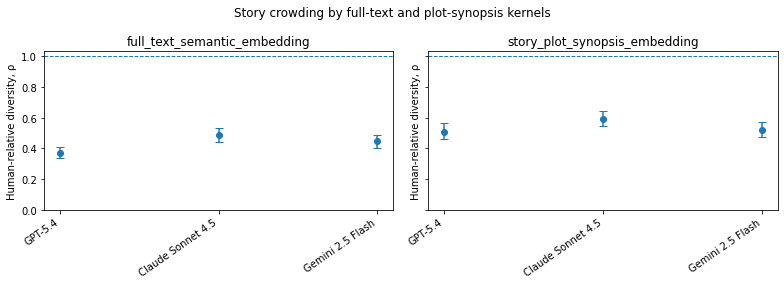

In [63]:
def plot_story_kernel_rho_comparison(
    comparison_df: pd.DataFrame,
    save_path: Optional[Path] = None,
):
    plot_df = comparison_df.copy()

    kernel_order = [
        "full_text_semantic_embedding",
        "story_plot_synopsis_embedding",
    ]

    model_order = ["GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]

    fig, axes = plt.subplots(1, len(kernel_order), figsize=(11, 4), sharey=True)

    for ax, kernel_name in zip(axes, kernel_order):
        sub = plot_df[plot_df["kernel_name"] == kernel_name].copy()

        sub["model_label"] = pd.Categorical(
            sub["model_label"],
            categories=model_order,
            ordered=True,
        )
        sub = sub.sort_values("model_label")

        x = np.arange(len(sub))
        y = sub["rho"].to_numpy(dtype=float)
        yerr_low = y - sub["rho_95ci_low"].to_numpy(dtype=float)
        yerr_high = sub["rho_95ci_high"].to_numpy(dtype=float) - y

        ax.errorbar(
            x,
            y,
            yerr=[yerr_low, yerr_high],
            fmt="o",
            capsize=4,
        )

        ax.axhline(1.0, linestyle="--", linewidth=1)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["model_label"], rotation=35, ha="right")
        ax.set_title(kernel_name)
        ax.set_ylabel("Human-relative diversity, ρ")
        ax.set_ylim(bottom=0)

    fig.suptitle("Story crowding by full-text and plot-synopsis kernels")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_story_kernel_rho_comparison(
    story_kernel_comparison,
    save_path=FIG_DIR / "story_full_text_vs_plot_synopsis_kernel_rho.pdf",
)

## 21.13 Task-level plot-synopsis rarefaction

In [90]:
# ============================================================
# 21.13 Task-level plot-synopsis rarefaction
# ============================================================
# This mirrors the main rarefaction diagnostic, but uses plot-synopsis
# embeddings and reports only task-level curves for stories.
#
# Output:
# - analysis_outputs/tables/story_plot_synopsis_kappa_rarefaction_task_level.csv
# - analysis_outputs/crowding_story_plot/story_plot_synopsis_kappa_rarefaction_task_level.pkl
# - analysis_outputs/figures/story_plot_synopsis_kappa_rarefaction_task_level.pdf
# ============================================================

N_VALUES_STORY_PLOT_RAREFACTION = list(range(2, 51))
N_STORY_PLOT_RAREFACTION_BOOT = 300
STORY_PLOT_RAREFACTION_SEED = 20260501

story_plot_rarefaction_dfs = []

start_time = time.time()

# Human curves: one per story condition.
# Note: story human pools top out at 35, 32, and 20, so human curves stop at the
# available number of human participants per condition.
for (task, condition_id), participant_pool in story_plot_human_pools.items():
    if task != "story":
        continue

    max_n = min(max(N_VALUES_STORY_PLOT_RAREFACTION), len(participant_pool))
    n_values_use = [n for n in N_VALUES_STORY_PLOT_RAREFACTION if n <= max_n]

    seed_payload = f"human::story_plot_synopsis::{condition_id}::rarefaction"
    seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

    curve = rarefaction_curve_human_participant_pool(
        participant_to_ids=participant_pool,
        embedding_matrix=synopsis_embedding_matrix,
        n_values=n_values_use,
        n_boot=N_STORY_PLOT_RAREFACTION_BOOT,
        seed=seed,
        replace_participants=False,
    )

    curve["source_type"] = "human"
    curve["model_label"] = "Human"
    curve["task_family"] = task
    curve["condition_id"] = condition_id
    curve["available_n"] = len(participant_pool)
    curve["kernel_name"] = "story_plot_synopsis_embedding"

    story_plot_rarefaction_dfs.append(curve)

    print(
        f"Human | story | {condition_id:16s} "
        f"| available_n={len(participant_pool):3d} | max_curve_n={max_n:3d}"
    )

# AI curves: one per model-condition.
for (model_label, task, condition_id), ai_ids in story_plot_ai_pools.items():
    if task != "story":
        continue

    max_n = min(max(N_VALUES_STORY_PLOT_RAREFACTION), len(ai_ids))
    n_values_use = [n for n in N_VALUES_STORY_PLOT_RAREFACTION if n <= max_n]

    seed_payload = f"ai::story_plot_synopsis::{model_label}::{condition_id}::rarefaction"
    seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

    curve = rarefaction_curve_ai_response_pool(
        embedding_ids=ai_ids,
        embedding_matrix=synopsis_embedding_matrix,
        n_values=n_values_use,
        n_boot=N_STORY_PLOT_RAREFACTION_BOOT,
        seed=seed,
        replace=False,
    )

    curve["source_type"] = "ai"
    curve["model_label"] = model_label
    curve["task_family"] = task
    curve["condition_id"] = condition_id
    curve["available_n"] = len(ai_ids)
    curve["kernel_name"] = "story_plot_synopsis_embedding"

    story_plot_rarefaction_dfs.append(curve)

    print(
        f"AI    | {model_label:20s} | story | {condition_id:16s} "
        f"| available_n={len(ai_ids):3d} | max_curve_n={max_n:3d}"
    )

story_plot_rarefaction_condition_df = pd.concat(
    story_plot_rarefaction_dfs,
    ignore_index=True,
)

# Aggregate to task level by equal-weight averaging across story prompts.
story_plot_rarefaction_task_df = (
    story_plot_rarefaction_condition_df
    .groupby(["kernel_name", "source_type", "model_label", "task_family", "n"], dropna=False)
    .agg(
        kappa_mean=("kappa_mean", "mean"),
        kappa_ci_low=("kappa_ci_low", "mean"),
        kappa_ci_high=("kappa_ci_high", "mean"),
        n_conditions=("condition_id", "nunique"),
        mean_available_n=("available_n", "mean"),
    )
    .reset_index()
)

# Save tables/objects.
story_plot_rarefaction_condition_df.to_csv(
    TABLE_DIR / "story_plot_synopsis_kappa_rarefaction_condition_level.csv",
    index=False,
)
story_plot_rarefaction_task_df.to_csv(
    TABLE_DIR / "story_plot_synopsis_kappa_rarefaction_task_level.csv",
    index=False,
)

story_plot_rarefaction_condition_df.to_pickle(
    STORY_PLOT_DIR / "story_plot_synopsis_kappa_rarefaction_condition_level.pkl"
)
story_plot_rarefaction_task_df.to_pickle(
    STORY_PLOT_DIR / "story_plot_synopsis_kappa_rarefaction_task_level.pkl"
)

elapsed = time.time() - start_time
print(f"\nStory plot-synopsis rarefaction complete.")
print(f"Condition-level rows: {story_plot_rarefaction_condition_df.shape}")
print(f"Task-level rows: {story_plot_rarefaction_task_df.shape}")
print(f"Elapsed time: {elapsed:.1f} seconds")

display(story_plot_rarefaction_task_df.head())

Human | story | 10491            | available_n= 35 | max_curve_n= 35
Human | story | 93742            | available_n= 32 | max_curve_n= 32
Human | story | 93855            | available_n= 20 | max_curve_n= 20
AI    | Claude Sonnet 4.5    | story | 10491            | available_n= 50 | max_curve_n= 50
AI    | Claude Sonnet 4.5    | story | 93742            | available_n= 50 | max_curve_n= 50
AI    | Claude Sonnet 4.5    | story | 93855            | available_n= 50 | max_curve_n= 50
AI    | GPT-5.4              | story | 10491            | available_n= 50 | max_curve_n= 50
AI    | GPT-5.4              | story | 93742            | available_n= 50 | max_curve_n= 50
AI    | GPT-5.4              | story | 93855            | available_n= 50 | max_curve_n= 50
AI    | Gemini 2.5 Flash     | story | 10491            | available_n= 50 | max_curve_n= 50
AI    | Gemini 2.5 Flash     | story | 93742            | available_n= 50 | max_curve_n= 50
AI    | Gemini 2.5 Flash     | story | 93855            |

,kernel_name,source_type,model_label,task_family,n,kappa_mean,kappa_ci_low,kappa_ci_high,n_conditions,mean_available_n
0,story_plot_synopsis_embedding,ai,Claude Sonnet 4.5,story,2,0.820714,0.734440,0.908820,3,50.0
1,story_plot_synopsis_embedding,ai,Claude Sonnet 4.5,story,3,0.823583,0.762001,0.886155,3,50.0
2,story_plot_synopsis_embedding,ai,Claude Sonnet 4.5,story,4,0.822311,0.769765,0.870382,3,50.0
3,story_plot_synopsis_embedding,ai,Claude Sonnet 4.5,story,5,0.823928,0.778273,0.869918,3,50.0
4,story_plot_synopsis_embedding,ai,Claude Sonnet 4.5,story,6,0.823349,0.783637,0.862610,3,50.0


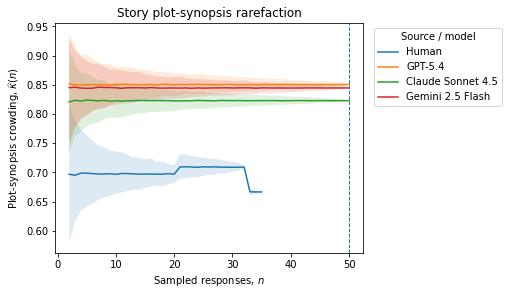

Saved: analysis_outputs/figures/story_plot_synopsis_kappa_rarefaction_task_level.pdf


In [91]:
# ============================================================
# Plot: task-level story plot-synopsis rarefaction
# ============================================================

plot_df = story_plot_rarefaction_task_df.copy()

model_order = ["Human", "GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]

fig, ax = plt.subplots(figsize=(7.2, 4.2))

for model in model_order:
    sub = plot_df[plot_df["model_label"].eq(model)].copy()
    if sub.empty:
        continue

    sub = sub.sort_values("n")

    x = sub["n"].to_numpy(dtype=float)
    y = sub["kappa_mean"].to_numpy(dtype=float)
    lo = sub["kappa_ci_low"].to_numpy(dtype=float)
    hi = sub["kappa_ci_high"].to_numpy(dtype=float)

    ax.plot(x, y, label=model)
    ax.fill_between(x, lo, hi, alpha=0.15)

ax.axvline(50, linestyle="--", linewidth=1)
ax.set_xlabel("Sampled responses, $n$")
ax.set_ylabel(r"Plot-synopsis crowding, $\widehat{\kappa}(n)$")
ax.set_title("Story plot-synopsis rarefaction")
ax.legend(title="Source / model", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()

out_path = FIG_DIR / "story_plot_synopsis_kappa_rarefaction_task_level.pdf"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

## 21.13 Condition-level plot-synopsis diagnostic figure

This figure shows whether narrative crowding is concentrated in a specific story prompt.

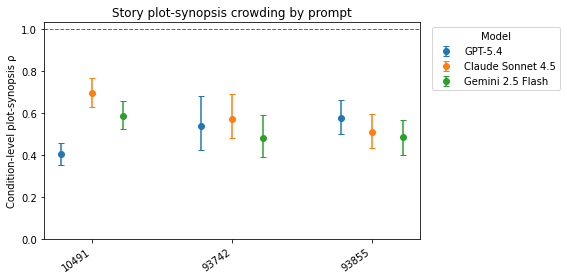

Saved: analysis_outputs/figures/story_plot_synopsis_condition_level_rho.pdf


In [64]:
story_plot_condition_plot_df = story_plot_condition_summary.copy()

story_plot_condition_plot_df = story_plot_condition_plot_df.rename(columns={
    "rho_mean": "rho",
    "rho_ci_low": "rho_low",
    "rho_ci_high": "rho_high",
})

model_order = ["GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]
condition_order = sorted(story_plot_condition_plot_df["condition_id"].astype(str).unique())

fig, ax = plt.subplots(figsize=(max(8, len(condition_order) * 1.4), 4))

width = 0.22
x_base = np.arange(len(condition_order))

for i, model in enumerate(model_order):
    m = story_plot_condition_plot_df[story_plot_condition_plot_df["model_label"] == model].copy()
    m["condition_id"] = pd.Categorical(
        m["condition_id"].astype(str),
        categories=condition_order,
        ordered=True,
    )
    m = m.sort_values("condition_id")

    x = x_base + (i - 1) * width
    y = m["rho"].to_numpy(dtype=float)
    yerr_low = y - m["rho_low"].to_numpy(dtype=float)
    yerr_high = m["rho_high"].to_numpy(dtype=float) - y

    ax.errorbar(
        x,
        y,
        yerr=[yerr_low, yerr_high],
        fmt="o",
        capsize=3,
        label=model,
    )

ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_xticks(x_base)
ax.set_xticklabels(condition_order, rotation=35, ha="right")
ax.set_ylabel("Condition-level plot-synopsis ρ")
ax.set_title("Story plot-synopsis crowding by prompt")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(bottom=0)

fig.tight_layout()

out_path = FIG_DIR / "story_plot_synopsis_condition_level_rho.pdf"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

## 21.14 Save full story plot-synopsis outputs

We save the row-level data with synopses, the synopsis embeddings metadata, bootstrap distributions, summary tables, and kernel comparison table.

In [65]:
story_plot_df_path = STORY_PLOT_DIR / "story_main_rows_with_plot_synopses.pkl"
story_plot_condition_boot_path = STORY_PLOT_DIR / "story_plot_synopsis_condition_bootstrap.pkl"
story_plot_task_boot_path = STORY_PLOT_DIR / "story_plot_synopsis_task_bootstrap.pkl"

story_plot_condition_summary_path = STORY_PLOT_DIR / "story_plot_synopsis_condition_summary.csv"
story_plot_task_summary_path = STORY_PLOT_DIR / "story_plot_synopsis_task_summary.csv"
story_kernel_comparison_path = STORY_PLOT_DIR / "story_full_text_vs_plot_synopsis_kernel_comparison.csv"

story_plot_df.to_pickle(story_plot_df_path)
story_plot_condition_boot_df.to_pickle(story_plot_condition_boot_path)
story_plot_task_boot_df.to_pickle(story_plot_task_boot_path)

story_plot_condition_summary.to_csv(story_plot_condition_summary_path, index=False)
story_plot_task_summary.to_csv(story_plot_task_summary_path, index=False)
story_kernel_comparison.to_csv(story_kernel_comparison_path, index=False)

print("Saved:")
print(story_plot_df_path)
print(story_plot_condition_boot_path)
print(story_plot_task_boot_path)
print(story_plot_condition_summary_path)
print(story_plot_task_summary_path)
print(story_kernel_comparison_path)

print("\nAlso saved to table/figure directories:")
print(TABLE_DIR / "story_plot_synopsis_condition_level_crowding.csv")
print(TABLE_DIR / "story_plot_synopsis_task_level_crowding.csv")
print(TABLE_DIR / "story_plot_synopsis_crowding_display_table.csv")
print(TABLE_DIR / "story_full_text_vs_plot_synopsis_kernel_comparison.csv")
print(FIG_DIR / "story_full_text_vs_plot_synopsis_kernel_rho.pdf")
print(FIG_DIR / "story_plot_synopsis_condition_level_rho.pdf")

Saved:
analysis_outputs/crowding_story_plot/story_main_rows_with_plot_synopses.pkl
analysis_outputs/crowding_story_plot/story_plot_synopsis_condition_bootstrap.pkl
analysis_outputs/crowding_story_plot/story_plot_synopsis_task_bootstrap.pkl
analysis_outputs/crowding_story_plot/story_plot_synopsis_condition_summary.csv
analysis_outputs/crowding_story_plot/story_plot_synopsis_task_summary.csv
analysis_outputs/crowding_story_plot/story_full_text_vs_plot_synopsis_kernel_comparison.csv

Also saved to table/figure directories:
analysis_outputs/tables/story_plot_synopsis_condition_level_crowding.csv
analysis_outputs/tables/story_plot_synopsis_task_level_crowding.csv
analysis_outputs/tables/story_plot_synopsis_crowding_display_table.csv
analysis_outputs/tables/story_full_text_vs_plot_synopsis_kernel_comparison.csv
analysis_outputs/figures/story_full_text_vs_plot_synopsis_kernel_rho.pdf
analysis_outputs/figures/story_plot_synopsis_condition_level_rho.pdf


## 21.15 Final story plot-synopsis status report

This checkpoint prints the main plot-kernel table and the full-text versus plot-synopsis comparison.

In [66]:
print("=" * 100)
print("STORY PLOT-SYNOPSIS CROWDING DISPLAY TABLE")
print("=" * 100)
display(story_plot_display)

print("=" * 100)
print("FULL-TEXT VS PLOT-SYNOPSIS STORY KERNEL COMPARISON")
print("=" * 100)
display(story_kernel_comparison)

STORY PLOT-SYNOPSIS CROWDING DISPLAY TABLE


,kernel_name,model,task,n_conditions,mean_b_matched,kappa_H_plot,kappa_A_plot,Delta_plot,rho_plot,rho_plot_95ci,parity_classification
0,story_plot_synopsis_embedding,Claude Sonnet 4.5,story,3,29.0,0.709,0.826,0.118,0.594,"[0.547, 0.647]",below parity
1,story_plot_synopsis_embedding,GPT-5.4,story,3,29.0,0.708,0.853,0.145,0.509,"[0.459, 0.568]",below parity
2,story_plot_synopsis_embedding,Gemini 2.5 Flash,story,3,29.0,0.708,0.848,0.139,0.519,"[0.473, 0.57]",below parity


FULL-TEXT VS PLOT-SYNOPSIS STORY KERNEL COMPARISON


,kernel_name,model_label,task,kappa_h,kappa_a,delta,rho,rho_95ci_low,rho_95ci_high,parity_classification
0,full_text_semantic_embedding,Claude Sonnet 4.5,story,0.705605,0.856871,0.151266,0.485399,0.440986,0.533075,below parity
1,full_text_semantic_embedding,GPT-5.4,story,0.705565,0.891775,0.186210,0.371828,0.337656,0.407763,below parity
2,full_text_semantic_embedding,Gemini 2.5 Flash,story,0.705322,0.869165,0.163843,0.445808,0.406139,0.489637,below parity
3,story_plot_synopsis_embedding,Claude Sonnet 4.5,story,0.708501,0.826320,0.117819,0.593915,0.546557,0.646516,below parity
4,story_plot_synopsis_embedding,GPT-5.4,story,0.708473,0.853266,0.144793,0.508607,0.458786,0.567867,below parity
5,story_plot_synopsis_embedding,Gemini 2.5 Flash,story,0.708312,0.847752,0.139440,0.519227,0.472607,0.570275,below parity


# 20. AUT Concept-Bucket Crowding Kernel

The semantic AUT analysis measures whether responses are close in embedding space. Here we compute a stricter concept-level kernel using the completed MUSEScorer/LLM bucketing pipeline.

For each AUT object, human and AI ideas were pooled and assigned to object-specific concept buckets using the same annotation procedure. Bucket IDs are only meaningful within an object, so we use the object-specific key:

$ \text{llm_bucket_key} = \text{object_name}::\text{llm_bucket_id} $

The bucket-crowding kernel is:

$K^{bucket}_k(x,y)=I\{b_k(x)=b_k(y)\}$

Under this kernel, $\kappa^H_k$ is the probability that two human AUT responses express the same underlying use concept, and $\kappa^A_{m,k}$ is the corresponding probability for two AI responses.

In [68]:
# Paths for AUT bucket-kernel analysis.
AUT_BUCKET_DIR = ANALYSIS_DIR / "aut_bucket_annotation"
AUT_BUCKET_CROWDING_DIR = ANALYSIS_DIR / "crowding_aut_bucket"

AUT_BUCKET_CROWDING_DIR.mkdir(parents=True, exist_ok=True)

AUT_BUCKET_ANNOTATIONS_PATH = AUT_BUCKET_DIR / "aut_pooled_llm_bucket_annotations_all.pkl"
AUT_BUCKET_CODEBOOKS_PATH = AUT_BUCKET_DIR / "aut_pooled_llm_bucket_codebooks_all.pkl"

assert AUT_BUCKET_ANNOTATIONS_PATH.exists(), f"Missing: {AUT_BUCKET_ANNOTATIONS_PATH}"
assert AUT_BUCKET_CODEBOOKS_PATH.exists(), f"Missing: {AUT_BUCKET_CODEBOOKS_PATH}"

aut_bucket_annotations_all = pd.read_pickle(AUT_BUCKET_ANNOTATIONS_PATH)
aut_bucket_codebooks_all = pd.read_pickle(AUT_BUCKET_CODEBOOKS_PATH)

print("AUT pooled bucket annotations:", aut_bucket_annotations_all.shape)
print("AUT pooled bucket codebooks:", aut_bucket_codebooks_all.shape)

display(aut_bucket_annotations_all.head())
display(aut_bucket_codebooks_all.head())

AUT pooled bucket annotations: (18497, 28)
AUT pooled bucket codebooks: (2851, 5)


,id,pooled_row_uid,pooled_row_idx,source_group,provider,model,analysis_scenario_name,scenario_name,temperature,persona_id,object_name,round_id,for_user_id,participant_id,idea_content,ai_generation_uid,run_idx,request_key,bucket_id,bucket_key,idea_content_exported,llm_bucket_id,for_user_id_exported,object_name_exported,llm_bucket_reason,annotation_experiment_name,llm_bucket_object_name,llm_bucket_key
0,11101,002dc31001de0f43357ac671,6614,ai,openai,gpt-5.4,personality_grid,personality_grid,1.3,introverted__agreeable__conscientious__emotionally_stable__open_to_experience,shoe,1,ai_openai_c4bb8beebb697fcee68c,NaN,Turn the shoe into a discreet doorstop by wedging it under a drafty door.,c4bb8beebb697fcee68c,9.0,b0e51e44125c4f64f1961a26ce3479b0c7ab024996a6fcd2430da22957fae354,NaN,NaN,Turn the shoe into a discreet doorstop by wedging it under a drafty door.,9,ai_openai_c4bb8beebb697fcee68c,shoe,The input idea is a very obviously rephrased version of comparison_idea_ID 9.,neurips_aut_pooled_llama32_70b_k10_shoe,shoe,shoe::9
1,11102,00393c6824564e7d7f86c471,2861,human,human,human,human,human,NaN,NaN,shoe,1,human_92,92.0,Meat tenderizer,NaN,NaN,NaN,884.0,shoe::884,Meat tenderizer,232,human_92,shoe,The input idea is a very obviously rephrased version of comparison_idea_ID 232.,neurips_aut_pooled_llama32_70b_k10_shoe,shoe,shoe::232
2,11103,003c37f0c66a3aa215c858e4,859,human,human,human,human,human,NaN,NaN,shoe,1,human_134,134.0,counter weight for grappling hook,NaN,NaN,NaN,780.0,shoe::780,counter weight for grappling hook,185,human_134,shoe,The input idea is not an obvious rephrasing of any comparison_idea_ID.,neurips_aut_pooled_llama32_70b_k10_shoe,shoe,shoe::185
3,11104,0050830f5db737c8825e2c51,15194,ai,gemini,gemini-2.5-flash,personality_grid,personality_grid,1.3,extroverted__agreeable__unconscientious__emotionally_stable__open_to_experience,shoe,1,ai_gemini_3053c67c6febfec9ecaf,NaN,"Ooh! You know, a shoe could totally be a super fun little planter for a succulent or a tiny herb garden!",3053c67c6febfec9ecaf,2.0,590645df1057cd7f64beab673a5fe9cf7d1f53e27b3e94dfe3b2791995dd4f3e,NaN,NaN,"Ooh! You know, a shoe could totally be a super fun little planter for a succulent or a tiny herb garden!",123,ai_gemini_3053c67c6febfec9ecaf,shoe,The input idea is a very obviously rephrased version of comparison_idea_ID 123.,neurips_aut_pooled_llama32_70b_k10_shoe,shoe,shoe::123
4,11105,006a879f50f8162ee89cba1b,16966,ai,gemini,gemini-2.5-flash,personality_grid,personality_grid,1.3,introverted__antagonistic__conscientious__neurotic__open_to_experience,shoe,1,ai_gemini_63f1e8f2fd86d19ff272,NaN,"A boat shoe could serve as a shallow, weighted anchor for small, decorative pond lilies in a backyard water feature, the lacing providin...",63f1e8f2fd86d19ff272,4.0,b2efbb0267041e6c940f2bdd4b2a422fa2590b514b39212e25346332af00564c,NaN,NaN,"A boat shoe could serve as a shallow, weighted anchor for small, decorative pond lilies in a backyard water feature, the lacing providin...",192,ai_gemini_63f1e8f2fd86d19ff272,shoe,The input idea is a very obviously rephrased version of comparison_idea_ID 192.,neurips_aut_pooled_llama32_70b_k10_shoe,shoe,shoe::192


,codebook_ids,codebook_descriptions,annotation_experiment_name,object_name,llm_bucket_key
0,1,A shoe can be used as a doorstop to hold a door open at a specific angle.,neurips_aut_pooled_llama32_70b_k10_shoe,shoe,shoe::1
1,2,"A sturdy hiking boot could be repurposed as a unique, rustic planter for a small succulent or herb, adding a quirky touch to a windowsil...",neurips_aut_pooled_llama32_70b_k10_shoe,shoe,shoe::2
2,3,Turn the shoe into a hidden wall safe by hollowing the sole and mounting it in a closet among real pairs.,neurips_aut_pooled_llama32_70b_k10_shoe,shoe,shoe::3
3,4,As a hand bag,neurips_aut_pooled_llama32_70b_k10_shoe,shoe,shoe::4
4,5,Smash a bug on the wall.,neurips_aut_pooled_llama32_70b_k10_shoe,shoe,shoe::5


## 20.1 Check annotation completeness

Every pooled AUT response should have an assigned bucket. We check completeness by object and source group before using the annotations.

Rows with missing buckets indicate an unfinished object-specific annotation run and should be fixed in the bucketing notebook before proceeding.

In [69]:
# Basic completeness checks.
required_cols = [
    "id",
    "source_group",
    "provider",
    "model",
    "analysis_scenario_name",
    "temperature",
    "object_name",
    "for_user_id",
    "idea_content",
    "llm_bucket_id",
    "llm_bucket_key",
]

missing_cols = [c for c in required_cols if c not in aut_bucket_annotations_all.columns]
assert not missing_cols, f"Missing required columns in bucket annotation file: {missing_cols}"

bucket_completeness = (
    aut_bucket_annotations_all
    .groupby(["object_name", "source_group"], dropna=False)
    .agg(
        n_rows=("id", "size"),
        n_annotated=("llm_bucket_id", lambda x: x.notna().sum()),
        n_buckets=("llm_bucket_key", "nunique"),
        n_unique_texts=("idea_content", "nunique"),
    )
    .reset_index()
)

bucket_completeness["annotation_rate"] = (
    bucket_completeness["n_annotated"] / bucket_completeness["n_rows"]
)

display(bucket_completeness)

incomplete_bucket_rows = aut_bucket_annotations_all[
    aut_bucket_annotations_all["llm_bucket_id"].isna()
].copy()

print("Incomplete annotation rows:", len(incomplete_bucket_rows))
display(incomplete_bucket_rows.head())

assert len(incomplete_bucket_rows) == 0, (
    "Some AUT rows are missing llm_bucket_id. Finish/export the bucketing notebook first."
)

bucket_completeness.to_csv(
    TABLE_DIR / "aut_bucket_annotation_completeness.csv",
    index=False,
)

,object_name,source_group,n_rows,n_annotated,n_buckets,n_unique_texts,annotation_rate
0,automobile_tire,ai,3090,3090,500,2560,1.0
1,automobile_tire,human,615,615,301,575,1.0
2,button,ai,3090,3090,360,2470,1.0
3,button,human,603,603,258,583,1.0
4,key,ai,3090,3090,364,2635,1.0
5,key,human,612,612,273,574,1.0
6,shoe,ai,3090,3090,291,2171,1.0
7,shoe,human,604,604,213,532,1.0
8,wooden_pencil,ai,3090,3090,425,2422,1.0
9,wooden_pencil,human,613,613,306,583,1.0


Incomplete annotation rows: 0


,id,pooled_row_uid,pooled_row_idx,source_group,provider,model,analysis_scenario_name,scenario_name,temperature,persona_id,object_name,round_id,for_user_id,participant_id,idea_content,ai_generation_uid,run_idx,request_key,bucket_id,bucket_key,idea_content_exported,llm_bucket_id,for_user_id_exported,object_name_exported,llm_bucket_reason,annotation_experiment_name,llm_bucket_object_name,llm_bucket_key


## 20.2 Build the main AUT bucket-analysis table

The bucketing file contains all human responses and all AI robustness generations. For the main benchmark, we keep:

- all human AUT responses;
- AI rows from `neutral_main_t1`;
- AI rows at temperature $T=1.0$.

We keep exact duplicate ideas because duplicates are part of the redundancy signal.

In [70]:
def normalize_bucket_text(x: str) -> str:
    """Normalize response text for display/checks only; do not collapse duplicate rows."""
    if not isinstance(x, str):
        return ""
    return " ".join(x.strip().split())


def add_bucket_model_label(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    def label_row(row):
        if row.get("source_group") == "human":
            return "Human"
        return MODEL_LABELS.get((row.get("provider"), row.get("model")), row.get("model"))

    df["model_label"] = df.apply(label_row, axis=1)
    return df


aut_bucket_df = aut_bucket_annotations_all.copy()

# Clean core fields.
aut_bucket_df["idea_content"] = aut_bucket_df["idea_content"].astype(str).map(normalize_bucket_text)
aut_bucket_df["object_name"] = aut_bucket_df["object_name"].astype(str)
aut_bucket_df["source_group"] = aut_bucket_df["source_group"].astype(str)

# Ensure bucket key is object-specific and stable.
aut_bucket_df["llm_bucket_id"] = aut_bucket_df["llm_bucket_id"].astype("Int64")
aut_bucket_df["llm_bucket_key"] = (
    aut_bucket_df["object_name"].astype(str)
    + "::"
    + aut_bucket_df["llm_bucket_id"].astype(str)
)

# Keep only rows relevant to the main AUT benchmark.
human_bucket_main = aut_bucket_df.query("source_group == 'human'").copy()

ai_bucket_main = aut_bucket_df.query(
    "source_group == 'ai' and analysis_scenario_name == 'neutral_main_t1'"
).copy()

# Be conservative: the main benchmark is T=1.0.
ai_bucket_main = ai_bucket_main[
    np.isclose(ai_bucket_main["temperature"].astype(float), 1.0)
].copy()

aut_bucket_main_df = pd.concat(
    [human_bucket_main, ai_bucket_main],
    ignore_index=True,
    sort=False,
)

aut_bucket_main_df = add_bucket_model_label(aut_bucket_main_df)

# Standardize names to match earlier analysis conventions.
aut_bucket_main_df = aut_bucket_main_df.rename(
    columns={
        "object_name": "condition_id",
        "source_group": "source_type",
    }
)

aut_bucket_main_df["task_family"] = "aut"
aut_bucket_main_df["bucket_value"] = aut_bucket_main_df["llm_bucket_key"].astype(str)

# Keep a stable row index for reproducibility.
aut_bucket_main_df = aut_bucket_main_df.reset_index(drop=True)
aut_bucket_main_df["bucket_analysis_row_id"] = np.arange(len(aut_bucket_main_df))

print("AUT bucket main rows:", aut_bucket_main_df.shape)

display(
    aut_bucket_main_df
    .groupby(["source_type", "model_label", "condition_id"], dropna=False)
    .agg(
        n_rows=("idea_content", "size"),
        n_unique_texts=("idea_content", "nunique"),
        n_buckets=("bucket_value", "nunique"),
        n_users=("for_user_id", "nunique"),
    )
    .reset_index()
    .sort_values(["condition_id", "source_type", "model_label"])
)

AUT bucket main rows: (3797, 32)


,source_type,model_label,condition_id,n_rows,n_unique_texts,n_buckets,n_users
0,ai,Claude Sonnet 4.5,automobile_tire,50,10,10,50
5,ai,GPT-5.4,automobile_tire,50,45,28,50
10,ai,Gemini 2.5 Flash,automobile_tire,50,44,36,50
15,human,Human,automobile_tire,615,575,301,109
1,ai,Claude Sonnet 4.5,button,50,40,10,50
6,ai,GPT-5.4,button,50,45,24,50
11,ai,Gemini 2.5 Flash,button,50,48,31,50
16,human,Human,button,603,583,258,109
2,ai,Claude Sonnet 4.5,key,50,27,10,50
7,ai,GPT-5.4,key,50,47,23,50


## 20.3 Define bucket-crowding functions

For a sampled set of responses, bucket crowding is the mean off-diagonal co-membership rate:

$ \widehat{\kappa}^{bucket} = \frac{1}{n(n-1)}\sum_{i\ne j} I\{b_i=b_j\} $

This is the probability that two independently sampled responses fall into the same concept bucket.

In [71]:
def mean_pairwise_bucket_crowding(bucket_values: np.ndarray) -> float:
    """
    Mean off-diagonal concept-bucket co-membership.

    This computes:
        mean_{i != j} I[b_i == b_j]

    It supports repeated sampled rows, including bootstrap duplicates.
    """
    bucket_values = np.asarray(bucket_values, dtype=object)
    n = len(bucket_values)

    if n < 2:
        return np.nan

    # Count how many sampled items fall in each bucket.
    _, counts = np.unique(bucket_values, return_counts=True)

    # Ordered off-diagonal equal-bucket pairs:
    # sum_b c_b * (c_b - 1)
    equal_off_diag = np.sum(counts * (counts - 1))
    total_off_diag = n * (n - 1)

    return float(equal_off_diag / total_off_diag)


def sample_human_one_bucket_per_participant(
    participant_to_buckets: dict,
    sample_size: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Sample human participants with replacement, then one bucket value from
    each selected participant's responses.

    This matches the participant-aware strategy used in the semantic AUT analysis.
    """
    participant_ids = np.array(list(participant_to_buckets.keys()), dtype=object)

    sampled_participants = rng.choice(
        participant_ids,
        size=sample_size,
        replace=True,
    )

    sampled_buckets = []

    for pid in sampled_participants:
        candidate_buckets = participant_to_buckets[pid]
        chosen_bucket = rng.choice(candidate_buckets, size=1, replace=True)[0]
        sampled_buckets.append(chosen_bucket)

    return np.asarray(sampled_buckets, dtype=object)


# Smoke test.
test_buckets = np.array(["shoe::1", "shoe::1", "shoe::2", "shoe::3"])
print("Smoke-test bucket crowding:", mean_pairwise_bucket_crowding(test_buckets))

Smoke-test bucket crowding: 0.16666666666666666


## 20.4 Build bucket sampling pools

Human sampling remains participant-aware. AI sampling is row-level because each AI row is one self-play generation.

In [72]:
# Human participant-aware pools.
aut_bucket_human_pools = {}

human_aut_bucket_df = aut_bucket_main_df.query("source_type == 'human'").copy()

for condition_id, g_condition in human_aut_bucket_df.groupby("condition_id", dropna=False):
    participant_to_buckets = {}

    for participant_id, g_participant in g_condition.groupby("for_user_id", dropna=False):
        participant_to_buckets[str(participant_id)] = (
            g_participant["bucket_value"].astype(str).to_numpy()
        )

    aut_bucket_human_pools[condition_id] = participant_to_buckets


# AI row-level bucket pools.
aut_bucket_ai_pools = {}

ai_aut_bucket_df = aut_bucket_main_df.query("source_type == 'ai'").copy()

for (model_label, condition_id), g in ai_aut_bucket_df.groupby(
    ["model_label", "condition_id"],
    dropna=False,
):
    aut_bucket_ai_pools[(model_label, condition_id)] = (
        g["bucket_value"].astype(str).to_numpy()
    )


# Sampling-pool summary.
bucket_pool_rows = []

for (model_label, condition_id), ai_buckets in aut_bucket_ai_pools.items():
    human_pool = aut_bucket_human_pools.get(condition_id)

    if human_pool is None:
        n_human_participants = 0
        n_human_response_rows = 0
        b_matched = np.nan
        mean_responses_per_participant = np.nan
    else:
        response_counts = [len(v) for v in human_pool.values()]
        n_human_participants = len(human_pool)
        n_human_response_rows = int(np.sum(response_counts))
        mean_responses_per_participant = float(np.mean(response_counts))
        b_matched = min(n_human_participants, len(ai_buckets))

    bucket_pool_rows.append({
        "model_label": model_label,
        "task_family": "aut",
        "condition_id": condition_id,
        "n_human_participants": n_human_participants,
        "n_human_response_rows": n_human_response_rows,
        "mean_human_responses_per_participant": mean_responses_per_participant,
        "n_ai": len(ai_buckets),
        "b_matched": b_matched,
        "n_human_buckets": (
            len(set(np.concatenate(list(human_pool.values()))))
            if human_pool is not None else 0
        ),
        "n_ai_buckets": len(set(ai_buckets)),
    })

aut_bucket_pool_summary = (
    pd.DataFrame(bucket_pool_rows)
    .sort_values(["condition_id", "model_label"])
    .reset_index(drop=True)
)

display(aut_bucket_pool_summary)

assert (aut_bucket_pool_summary["n_human_participants"] > 0).all()
assert (aut_bucket_pool_summary["b_matched"] >= 2).all()

aut_bucket_pool_summary.to_csv(
    TABLE_DIR / "aut_bucket_crowding_sampling_pools.csv",
    index=False,
)

,model_label,task_family,condition_id,n_human_participants,n_human_response_rows,mean_human_responses_per_participant,n_ai,b_matched,n_human_buckets,n_ai_buckets
0,Claude Sonnet 4.5,aut,automobile_tire,109,615,5.642202,50,50,301,10
1,GPT-5.4,aut,automobile_tire,109,615,5.642202,50,50,301,28
2,Gemini 2.5 Flash,aut,automobile_tire,109,615,5.642202,50,50,301,36
3,Claude Sonnet 4.5,aut,button,109,603,5.532110,50,50,258,10
4,GPT-5.4,aut,button,109,603,5.532110,50,50,258,24
5,Gemini 2.5 Flash,aut,button,109,603,5.532110,50,50,258,31
6,Claude Sonnet 4.5,aut,key,109,612,5.614679,50,50,273,10
7,GPT-5.4,aut,key,109,612,5.614679,50,50,273,23
8,Gemini 2.5 Flash,aut,key,109,612,5.614679,50,50,273,29
9,Claude Sonnet 4.5,aut,shoe,109,604,5.541284,50,50,213,16


## 20.5 Run the condition-level matched bootstrap

For each model-object comparison, we repeatedly sample matched human and AI sets and compute:

- human bucket crowding;
- AI bucket crowding;
- excess bucket crowding;
- human-relative bucket diversity.

The matched sample size is the same logic as before:

$ b_k = \min(n^H_{participants,k}, n^A_{m,k}) $

In [73]:
def bootstrap_condition_bucket_crowding(
    human_participant_pool: dict,
    ai_bucket_values: np.ndarray,
    n_boot: int = 2000,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Matched-sample bootstrap for one AUT model-object comparison under
    the concept-bucket kernel.
    """
    rng = np.random.default_rng(seed)

    ai_bucket_values = np.asarray(ai_bucket_values, dtype=object)

    n_human_participants = len(human_participant_pool)
    n_human_response_rows = int(sum(len(v) for v in human_participant_pool.values()))
    n_ai = len(ai_bucket_values)

    b = min(n_human_participants, n_ai)

    if b < 2:
        raise ValueError(f"Need at least 2 matched units, got b={b}")

    rows = []

    for rep in range(n_boot):
        h_sample = sample_human_one_bucket_per_participant(
            participant_to_buckets=human_participant_pool,
            sample_size=b,
            rng=rng,
        )

        a_sample = rng.choice(ai_bucket_values, size=b, replace=True)

        kappa_h = mean_pairwise_bucket_crowding(h_sample)
        kappa_a = mean_pairwise_bucket_crowding(a_sample)

        delta = max(0.0, kappa_a - kappa_h)

        denom = 1.0 - kappa_h
        rho = np.nan if denom <= 1e-12 else (1.0 - kappa_a) / denom

        rows.append({
            "bootstrap_rep": rep,
            "b_matched": b,
            "kappa_h": kappa_h,
            "kappa_a": kappa_a,
            "delta": delta,
            "rho": rho,
            "n_human_participants": n_human_participants,
            "n_human_response_rows": n_human_response_rows,
            "n_ai": n_ai,
        })

    return pd.DataFrame(rows)


# Use the same N_BOOT convention as the main analysis if available.
N_BOOT_BUCKET = globals().get("N_BOOT", 2000)
BUCKET_BOOTSTRAP_SEED = 20260503

bucket_condition_boot_dfs = []

start_time = time.time()

for row in aut_bucket_pool_summary.itertuples(index=False):
    model_label = row.model_label
    condition_id = row.condition_id

    human_pool = aut_bucket_human_pools[condition_id]
    ai_buckets = aut_bucket_ai_pools[(model_label, condition_id)]

    seed_payload = f"{BUCKET_BOOTSTRAP_SEED}::bucket::{model_label}::{condition_id}"
    seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

    boot_df = bootstrap_condition_bucket_crowding(
        human_participant_pool=human_pool,
        ai_bucket_values=ai_buckets,
        n_boot=N_BOOT_BUCKET,
        seed=seed,
    )

    boot_df["model_label"] = model_label
    boot_df["task_family"] = "aut"
    boot_df["condition_id"] = condition_id
    boot_df["kernel_name"] = "concept_bucket"

    bucket_condition_boot_dfs.append(boot_df)

    print(
        f"Finished {model_label:20s} | AUT bucket | {condition_id:16s} "
        f"| human_participants={len(human_pool)} "
        f"| human_responses={sum(len(v) for v in human_pool.values())} "
        f"| n_ai={len(ai_buckets)} "
        f"| b={min(len(human_pool), len(ai_buckets))}"
    )

aut_bucket_condition_boot_df = pd.concat(bucket_condition_boot_dfs, ignore_index=True)

elapsed = time.time() - start_time
print(f"\nAUT bucket bootstrap complete: {aut_bucket_condition_boot_df.shape} rows")
print(f"Elapsed time: {elapsed:.1f} seconds")

display(aut_bucket_condition_boot_df.head())

Finished Claude Sonnet 4.5    | AUT bucket | automobile_tire  | human_participants=109 | human_responses=615 | n_ai=50 | b=50
Finished GPT-5.4              | AUT bucket | automobile_tire  | human_participants=109 | human_responses=615 | n_ai=50 | b=50
Finished Gemini 2.5 Flash     | AUT bucket | automobile_tire  | human_participants=109 | human_responses=615 | n_ai=50 | b=50
Finished Claude Sonnet 4.5    | AUT bucket | button           | human_participants=109 | human_responses=603 | n_ai=50 | b=50
Finished GPT-5.4              | AUT bucket | button           | human_participants=109 | human_responses=603 | n_ai=50 | b=50
Finished Gemini 2.5 Flash     | AUT bucket | button           | human_participants=109 | human_responses=603 | n_ai=50 | b=50
Finished Claude Sonnet 4.5    | AUT bucket | key              | human_participants=109 | human_responses=612 | n_ai=50 | b=50
Finished GPT-5.4              | AUT bucket | key              | human_participants=109 | human_responses=612 | n_ai=50

,bootstrap_rep,b_matched,kappa_h,kappa_a,delta,rho,n_human_participants,n_human_response_rows,n_ai,model_label,task_family,condition_id,kernel_name
0,0,50,0.011429,0.168163,0.156735,0.841453,109,615,50,Claude Sonnet 4.5,aut,automobile_tire,concept_bucket
1,1,50,0.005714,0.168163,0.162449,0.836617,109,615,50,Claude Sonnet 4.5,aut,automobile_tire,concept_bucket
2,2,50,0.004898,0.224490,0.219592,0.779327,109,615,50,Claude Sonnet 4.5,aut,automobile_tire,concept_bucket
3,3,50,0.020408,0.226939,0.206531,0.789167,109,615,50,Claude Sonnet 4.5,aut,automobile_tire,concept_bucket
4,4,50,0.007347,0.232653,0.225306,0.773026,109,615,50,Claude Sonnet 4.5,aut,automobile_tire,concept_bucket


## 20.6 Summarize condition-level and task-level AUT bucket crowding

We summarize the bootstrap distribution at the object level, then aggregate across the five AUT objects with equal weight.

In [74]:
# Condition-level summary.
aut_bucket_condition_summary = summarize_bootstrap(
    aut_bucket_condition_boot_df,
    group_cols=["task_family", "condition_id", "model_label", "kernel_name"],
    metric_cols=["kappa_h", "kappa_a", "delta", "rho"],
)

aut_bucket_condition_summary = aut_bucket_condition_summary.sort_values(
    ["condition_id", "model_label"]
).reset_index(drop=True)

display(aut_bucket_condition_summary)

aut_bucket_condition_summary.to_csv(
    TABLE_DIR / "aut_bucket_condition_level_crowding.csv",
    index=False,
)

# Equal-weight task-level aggregation.
aut_bucket_task_boot_df = (
    aut_bucket_condition_boot_df
    .groupby(["bootstrap_rep", "task_family", "model_label", "kernel_name"], dropna=False)
    .agg(
        kappa_h=("kappa_h", "mean"),
        kappa_a=("kappa_a", "mean"),
        delta=("delta", "mean"),
        rho=("rho", "mean"),
        n_conditions=("condition_id", "nunique"),
        mean_b_matched=("b_matched", "mean"),
        mean_human_participants_per_condition=("n_human_participants", "mean"),
        mean_human_response_rows_per_condition=("n_human_response_rows", "mean"),
        mean_ai_per_condition=("n_ai", "mean"),
    )
    .reset_index()
)

aut_bucket_task_summary = summarize_bootstrap(
    aut_bucket_task_boot_df,
    group_cols=["task_family", "model_label", "kernel_name"],
    metric_cols=["kappa_h", "kappa_a", "delta", "rho"],
)

# Attach metadata.
aut_bucket_task_meta = (
    aut_bucket_task_boot_df
    .groupby(["task_family", "model_label", "kernel_name"], dropna=False)
    .agg(
        n_conditions=("n_conditions", "first"),
        mean_b_matched=("mean_b_matched", "first"),
        mean_human_participants_per_condition=("mean_human_participants_per_condition", "first"),
        mean_human_response_rows_per_condition=("mean_human_response_rows_per_condition", "first"),
        mean_ai_per_condition=("mean_ai_per_condition", "first"),
    )
    .reset_index()
)

metadata_cols_to_drop = [
    c for c in [
        "n_conditions",
        "mean_b_matched",
        "mean_human_participants_per_condition",
        "mean_human_response_rows_per_condition",
        "mean_ai_per_condition",
    ]
    if c in aut_bucket_task_summary.columns
]

aut_bucket_task_summary = aut_bucket_task_summary.drop(columns=metadata_cols_to_drop)
aut_bucket_task_summary = aut_bucket_task_summary.merge(
    aut_bucket_task_meta,
    on=["task_family", "model_label", "kernel_name"],
    how="left",
)

aut_bucket_task_summary = aut_bucket_task_summary.sort_values(
    ["task_family", "model_label"]
).reset_index(drop=True)

display(aut_bucket_task_summary)

aut_bucket_task_summary.to_csv(
    TABLE_DIR / "aut_bucket_task_level_crowding.csv",
    index=False,
)

# Save full bootstrap distributions for later robustness reuse.
aut_bucket_condition_boot_df.to_pickle(
    AUT_BUCKET_CROWDING_DIR / "aut_bucket_condition_level_bootstrap.pkl"
)
aut_bucket_task_boot_df.to_pickle(
    AUT_BUCKET_CROWDING_DIR / "aut_bucket_task_level_bootstrap.pkl"
)

aut_bucket_condition_summary.to_csv(
    AUT_BUCKET_CROWDING_DIR / "aut_bucket_condition_level_summary.csv",
    index=False,
)
aut_bucket_task_summary.to_csv(
    AUT_BUCKET_CROWDING_DIR / "aut_bucket_task_level_summary.csv",
    index=False,
)

,task_family,condition_id,model_label,kernel_name,n_human_participants,n_human_response_rows,n_ai,b_matched,kappa_h_mean,kappa_h_median,kappa_h_ci_low,kappa_h_ci_high,kappa_a_mean,kappa_a_median,kappa_a_ci_low,kappa_a_ci_high,delta_mean,delta_median,delta_ci_low,delta_ci_high,rho_mean,rho_median,rho_ci_low,rho_ci_high
0,aut,automobile_tire,Claude Sonnet 4.5,concept_bucket,109,615,50,50,0.008057,0.007347,0.002449,0.016327,0.216116,0.212245,0.152653,0.306122,0.208058,0.204082,0.143673,0.299592,0.790264,0.794493,0.698346,0.855031
1,aut,automobile_tire,GPT-5.4,concept_bucket,109,615,50,50,0.008118,0.007347,0.003265,0.016327,0.064612,0.061224,0.038367,0.111020,0.056493,0.053061,0.029388,0.103673,0.943056,0.946678,0.895812,0.970274
2,aut,automobile_tire,Gemini 2.5 Flash,concept_bucket,109,615,50,50,0.008234,0.007347,0.003265,0.016327,0.037640,0.036735,0.024490,0.056327,0.029407,0.028571,0.013878,0.048980,0.970361,0.971146,0.950859,0.985915
3,aut,button,Claude Sonnet 4.5,concept_bucket,109,603,50,50,0.011273,0.010612,0.004082,0.022041,0.455292,0.448980,0.309388,0.617959,0.444019,0.438367,0.297959,0.609837,0.550920,0.556931,0.387149,0.696615
4,aut,button,GPT-5.4,concept_bucket,109,603,50,50,0.011296,0.010612,0.004082,0.022857,0.149406,0.143673,0.077551,0.256327,0.138109,0.133878,0.066122,0.246571,0.860337,0.864932,0.750588,0.933390
5,aut,button,Gemini 2.5 Flash,concept_bucket,109,603,50,50,0.011213,0.010612,0.004082,0.022041,0.048484,0.046531,0.031837,0.074286,0.037271,0.035918,0.017959,0.064490,0.962327,0.963696,0.934763,0.981773
6,aut,key,Claude Sonnet 4.5,concept_bucket,109,612,50,50,0.009506,0.008980,0.004082,0.018776,0.326550,0.320816,0.231020,0.440816,0.317044,0.311837,0.220408,0.431041,0.679931,0.685361,0.565071,0.777145
7,aut,key,GPT-5.4,concept_bucket,109,612,50,50,0.009531,0.008980,0.004082,0.017959,0.082391,0.080816,0.053061,0.124898,0.072860,0.070204,0.042449,0.116735,0.926456,0.928690,0.882498,0.957062
8,aut,key,Gemini 2.5 Flash,concept_bucket,109,612,50,50,0.009529,0.008980,0.003265,0.018776,0.067225,0.064490,0.040000,0.111020,0.057696,0.054694,0.029367,0.102857,0.941762,0.944856,0.896634,0.970360
9,aut,shoe,Claude Sonnet 4.5,concept_bucket,109,604,50,50,0.016726,0.015510,0.007347,0.031837,0.109211,0.106939,0.077551,0.152673,0.092485,0.090612,0.057959,0.137980,0.905982,0.907884,0.860295,0.940536


,task_family,model_label,kernel_name,kappa_h_mean,kappa_h_median,kappa_h_ci_low,kappa_h_ci_high,kappa_a_mean,kappa_a_median,kappa_a_ci_low,kappa_a_ci_high,delta_mean,delta_median,delta_ci_low,delta_ci_high,rho_mean,rho_median,rho_ci_low,rho_ci_high,n_conditions,mean_b_matched,mean_human_participants_per_condition,mean_human_response_rows_per_condition,mean_ai_per_condition
0,aut,Claude Sonnet 4.5,concept_bucket,0.011041,0.010939,0.007510,0.015837,0.293116,0.292082,0.249465,0.341886,0.282075,0.281143,0.238531,0.331433,0.714990,0.716120,0.665496,0.759313,5,50.0,109.0,609.4,50.0
1,aut,GPT-5.4,concept_bucket,0.010977,0.010776,0.007347,0.015347,0.143316,0.142531,0.115918,0.176331,0.132339,0.131510,0.104327,0.164743,0.866116,0.866967,0.833285,0.894306,5,50.0,109.0,609.4,50.0
2,aut,Gemini 2.5 Flash,concept_bucket,0.010971,0.010776,0.007510,0.015347,0.071851,0.071347,0.057629,0.089633,0.060880,0.060571,0.045873,0.078857,0.938356,0.938660,0.920194,0.953466,5,50.0,109.0,609.4,50.0


## 20.7 Create display tables

These tables are formatted for direct inspection and later LaTeX transfer.

In [76]:
def format_ci_fixed(low: float, high: float, digits: int = 3) -> str:
    return f"[{float(low):.{digits}f}, {float(high):.{digits}f}]"


aut_bucket_task_display = aut_bucket_task_summary.copy()

aut_bucket_task_display = aut_bucket_task_display.rename(
    columns={
        "model_label": "model",
        "task_family": "task",
        "kappa_h_mean": "kappa_H",
        "kappa_a_mean": "kappa_A",
        "delta_mean": "Delta",
        "rho_mean": "rho",
        "rho_ci_low": "rho_95ci_low",
        "rho_ci_high": "rho_95ci_high",
        "mean_b_matched": "mean_matched_n_per_condition",
    }
)

aut_bucket_task_display["rho_95ci"] = aut_bucket_task_display.apply(
    lambda row: format_ci_fixed(row["rho_95ci_low"], row["rho_95ci_high"], digits=3),
    axis=1,
)

aut_bucket_task_display["parity_classification"] = np.where(
    aut_bucket_task_display["rho_95ci_high"] < 1.0,
    "below parity",
    np.where(
        aut_bucket_task_display["rho_95ci_low"] > 1.0,
        "above parity",
        "uncertain",
    ),
)

display_cols = [
    "model",
    "task",
    "kernel_name",
    "n_conditions",
    "mean_matched_n_per_condition",
    "kappa_H",
    "kappa_A",
    "Delta",
    "rho",
    "rho_95ci",
    "parity_classification",
]

aut_bucket_task_display = aut_bucket_task_display[display_cols].copy()

aut_bucket_task_display_rounded = aut_bucket_task_display.copy()

for c in ["mean_matched_n_per_condition", "kappa_H", "kappa_A", "Delta", "rho"]:
    aut_bucket_task_display_rounded[c] = aut_bucket_task_display_rounded[c].round(3)

display(aut_bucket_task_display_rounded)

aut_bucket_task_display.to_csv(
    TABLE_DIR / "aut_bucket_crowding_table.csv",
    index=False,
)

aut_bucket_task_display_rounded.to_csv(
    TABLE_DIR / "aut_bucket_crowding_display_table.csv",
    index=False,
)

,model,task,kernel_name,n_conditions,mean_matched_n_per_condition,kappa_H,kappa_A,Delta,rho,rho_95ci,parity_classification
0,Claude Sonnet 4.5,aut,concept_bucket,5,50.0,0.011,0.293,0.282,0.715,"[0.665, 0.759]",below parity
1,GPT-5.4,aut,concept_bucket,5,50.0,0.011,0.143,0.132,0.866,"[0.833, 0.894]",below parity
2,Gemini 2.5 Flash,aut,concept_bucket,5,50.0,0.011,0.072,0.061,0.938,"[0.920, 0.953]",below parity


## 20.8 Compare AUT semantic and concept-bucket kernels

The semantic kernel and bucket kernel measure different notions of redundancy.

- Semantic crowding asks whether two responses are close in embedding space.
- Bucket crowding asks whether two responses express the same underlying use concept.

Here we place both kernels in the same task-level comparison table and plot.

In [77]:
# Load semantic AUT results from the main benchmark table.
semantic_main_path = TABLE_DIR / "main_results_semantic_crowding_table.csv"
assert semantic_main_path.exists(), f"Missing: {semantic_main_path}"

semantic_main_results = pd.read_csv(semantic_main_path)

semantic_aut = semantic_main_results.query("task == 'aut'").copy()
semantic_aut["kernel_name"] = "semantic"

semantic_aut_for_compare = semantic_aut.rename(
    columns={
        "model": "model_label",
        "kappa_H": "kappa_h_mean",
        "kappa_A": "kappa_a_mean",
        "Delta": "delta_mean",
        "rho": "rho_mean",
        "rho_95ci_low": "rho_ci_low",
        "rho_95ci_high": "rho_ci_high",
    }
)

semantic_aut_for_compare = semantic_aut_for_compare[
    [
        "model_label",
        "task",
        "kernel_name",
        "kappa_h_mean",
        "kappa_a_mean",
        "delta_mean",
        "rho_mean",
        "rho_ci_low",
        "rho_ci_high",
    ]
].rename(columns={"task": "task_family"})

bucket_aut_for_compare = aut_bucket_task_summary[
    [
        "model_label",
        "task_family",
        "kernel_name",
        "kappa_h_mean",
        "kappa_a_mean",
        "delta_mean",
        "rho_mean",
        "rho_ci_low",
        "rho_ci_high",
    ]
].copy()

aut_semantic_vs_bucket = pd.concat(
    [semantic_aut_for_compare, bucket_aut_for_compare],
    ignore_index=True,
    sort=False,
)

aut_semantic_vs_bucket = aut_semantic_vs_bucket.sort_values(
    ["kernel_name", "model_label"]
).reset_index(drop=True)

display(aut_semantic_vs_bucket)

aut_semantic_vs_bucket.to_csv(
    TABLE_DIR / "aut_semantic_vs_bucket_kernel_comparison.csv",
    index=False,
)

,model_label,task_family,kernel_name,kappa_h_mean,kappa_a_mean,delta_mean,rho_mean,rho_ci_low,rho_ci_high
0,Claude Sonnet 4.5,aut,concept_bucket,0.011041,0.293116,0.282075,0.714990,0.665496,0.759313
1,GPT-5.4,aut,concept_bucket,0.010977,0.143316,0.132339,0.866116,0.833285,0.894306
2,Gemini 2.5 Flash,aut,concept_bucket,0.010971,0.071851,0.060880,0.938356,0.920194,0.953466
3,Claude Sonnet 4.5,aut,semantic,0.601281,0.876643,0.275362,0.308882,0.276638,0.339699
4,GPT-5.4,aut,semantic,0.601197,0.790717,0.189520,0.525446,0.499255,0.548351
5,Gemini 2.5 Flash,aut,semantic,0.601108,0.743144,0.142037,0.644685,0.612164,0.676923


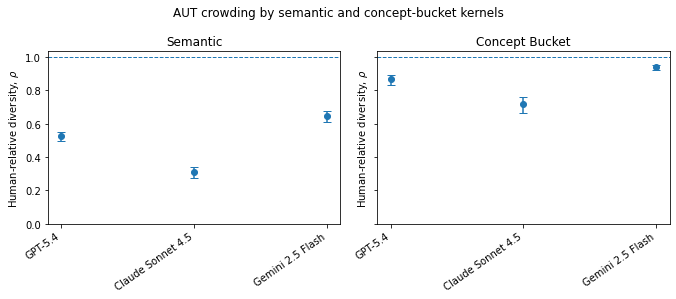

In [78]:
def plot_aut_semantic_vs_bucket_kernel_rho(
    comparison_df: pd.DataFrame,
    save_path: Optional[Path] = None,
):
    kernel_order = ["semantic", "concept_bucket"]
    model_order = ["GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]

    fig, axes = plt.subplots(
        1,
        len(kernel_order),
        figsize=(9.5, 4.2),
        sharey=True,
    )

    for ax, kernel_name in zip(axes, kernel_order):
        sub = comparison_df[comparison_df["kernel_name"] == kernel_name].copy()

        sub["model_label"] = pd.Categorical(
            sub["model_label"],
            categories=model_order,
            ordered=True,
        )
        sub = sub.sort_values("model_label")

        x = np.arange(len(sub))
        y = sub["rho_mean"].to_numpy(dtype=float)
        yerr_low = y - sub["rho_ci_low"].to_numpy(dtype=float)
        yerr_high = sub["rho_ci_high"].to_numpy(dtype=float) - y

        ax.errorbar(
            x,
            y,
            yerr=[yerr_low, yerr_high],
            fmt="o",
            capsize=4,
        )

        ax.axhline(1.0, linestyle="--", linewidth=1)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["model_label"], rotation=35, ha="right")
        ax.set_title(kernel_name.replace("_", " ").title())
        ax.set_ylabel("Human-relative diversity, $\\rho$")
        ax.set_ylim(bottom=0)

    fig.suptitle("AUT crowding by semantic and concept-bucket kernels")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_aut_semantic_vs_bucket_kernel_rho(
    aut_semantic_vs_bucket,
    save_path=FIG_DIR / "aut_semantic_vs_bucket_kernel_rho.pdf",
)

## 20.9 Condition-level bucket-kernel plot

This plot checks whether concept-bucket crowding is concentrated in particular AUT objects.

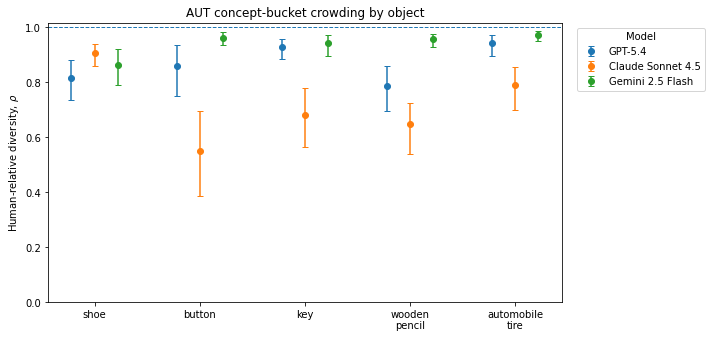

In [79]:
def plot_aut_bucket_condition_level_rho(
    condition_summary_df: pd.DataFrame,
    save_path: Optional[Path] = None,
):
    plot_df = condition_summary_df.copy()

    object_order = ["shoe", "button", "key", "wooden_pencil", "automobile_tire"]
    model_order = ["GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]

    plot_df["condition_id"] = pd.Categorical(
        plot_df["condition_id"],
        categories=object_order,
        ordered=True,
    )
    plot_df["model_label"] = pd.Categorical(
        plot_df["model_label"],
        categories=model_order,
        ordered=True,
    )

    plot_df = plot_df.sort_values(["condition_id", "model_label"])

    fig, ax = plt.subplots(figsize=(10, 4.8))

    x_base = np.arange(len(object_order))
    offsets = {
        "GPT-5.4": -0.22,
        "Claude Sonnet 4.5": 0.0,
        "Gemini 2.5 Flash": 0.22,
    }

    for model_label in model_order:
        sub = plot_df[plot_df["model_label"] == model_label].copy()
        x = np.array([object_order.index(str(c)) for c in sub["condition_id"]], dtype=float)
        x = x + offsets[model_label]

        y = sub["rho_mean"].to_numpy(dtype=float)
        yerr_low = y - sub["rho_ci_low"].to_numpy(dtype=float)
        yerr_high = sub["rho_ci_high"].to_numpy(dtype=float) - y

        ax.errorbar(
            x,
            y,
            yerr=[yerr_low, yerr_high],
            fmt="o",
            capsize=3,
            label=model_label,
        )

    ax.axhline(1.0, linestyle="--", linewidth=1)
    ax.set_xticks(x_base)
    ax.set_xticklabels(
        ["shoe", "button", "key", "wooden\npencil", "automobile\ntire"]
    )
    ax.set_ylabel("Human-relative diversity, $\\rho$")
    ax.set_title("AUT concept-bucket crowding by object")
    ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_ylim(bottom=0)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_aut_bucket_condition_level_rho(
    aut_bucket_condition_summary,
    save_path=FIG_DIR / "aut_bucket_condition_level_rho.pdf",
)

## 20.10 Save final status report

These are the files needed to populate the AUT concept-bucket subsection in the manuscript.

In [80]:
print("=" * 100)
print("AUT BUCKET CROWDING FILES SAVED")
print("=" * 100)

saved_paths = [
    TABLE_DIR / "aut_bucket_annotation_completeness.csv",
    TABLE_DIR / "aut_bucket_crowding_sampling_pools.csv",
    TABLE_DIR / "aut_bucket_condition_level_crowding.csv",
    TABLE_DIR / "aut_bucket_task_level_crowding.csv",
    TABLE_DIR / "aut_bucket_crowding_table.csv",
    TABLE_DIR / "aut_bucket_crowding_display_table.csv",
    TABLE_DIR / "aut_semantic_vs_bucket_kernel_comparison.csv",
    FIG_DIR / "aut_semantic_vs_bucket_kernel_rho.pdf",
    FIG_DIR / "aut_bucket_condition_level_rho.pdf",
    AUT_BUCKET_CROWDING_DIR / "aut_bucket_condition_level_bootstrap.pkl",
    AUT_BUCKET_CROWDING_DIR / "aut_bucket_task_level_bootstrap.pkl",
    AUT_BUCKET_CROWDING_DIR / "aut_bucket_condition_level_summary.csv",
    AUT_BUCKET_CROWDING_DIR / "aut_bucket_task_level_summary.csv",
]

for p in saved_paths:
    print(p, "| exists:", p.exists())

print("\nMain manuscript table:")
print(TABLE_DIR / "aut_semantic_vs_bucket_kernel_comparison.csv")

print("\nMain manuscript figure:")
print(FIG_DIR / "aut_semantic_vs_bucket_kernel_rho.pdf")

print("\nAppendix figure:")
print(FIG_DIR / "aut_bucket_condition_level_rho.pdf")

AUT BUCKET CROWDING FILES SAVED
analysis_outputs/tables/aut_bucket_annotation_completeness.csv | exists: True
analysis_outputs/tables/aut_bucket_crowding_sampling_pools.csv | exists: True
analysis_outputs/tables/aut_bucket_condition_level_crowding.csv | exists: True
analysis_outputs/tables/aut_bucket_task_level_crowding.csv | exists: True
analysis_outputs/tables/aut_bucket_crowding_table.csv | exists: True
analysis_outputs/tables/aut_bucket_crowding_display_table.csv | exists: True
analysis_outputs/tables/aut_semantic_vs_bucket_kernel_comparison.csv | exists: True
analysis_outputs/figures/aut_semantic_vs_bucket_kernel_rho.pdf | exists: True
analysis_outputs/figures/aut_bucket_condition_level_rho.pdf | exists: True
analysis_outputs/crowding_aut_bucket/aut_bucket_condition_level_bootstrap.pkl | exists: True
analysis_outputs/crowding_aut_bucket/aut_bucket_task_level_bootstrap.pkl | exists: True
analysis_outputs/crowding_aut_bucket/aut_bucket_condition_level_summary.csv | exists: True
anal

# 21. AUT Bucket-Kernel Rarefaction Diagnostics

We now repeat the finite-sample stability diagnostic for the AUT concept-bucket kernel.

The goal is the same as in the semantic and slogan lexical analyses: check whether the estimated AI bucket crowding changes materially as the number of self-play samples increases.

For each model-object condition and sample size $n$, we repeatedly sample $n$ AI ideas and compute:

$ \widehat{\kappa}^{A,bucket}(n) = \text{mean}_{i \ne j} I\{b_i=b_j\} $

For the human baseline, we use the same participant-aware sampling as before: sample participants first, then one idea per sampled participant.

A flat curve indicates that the bucket-level crowding estimate is stable with the available $n=50$ AI ideas per model-object condition.

In [81]:
# Output directory for AUT bucket rarefaction.
AUT_BUCKET_RAREFACTION_DIR = ANALYSIS_DIR / "crowding_aut_bucket_rarefaction"
AUT_BUCKET_RAREFACTION_DIR.mkdir(parents=True, exist_ok=True)

# Sample sizes for rarefaction.
# Main AI data have 50 rows per model-object condition.
AUT_BUCKET_RAREFACTION_NS = list(range(2, 51))

# Number of repeated rarefaction samples at each n.
# Increase to 1000 if you want smoother intervals; 500 is usually enough.
N_RAREFACTION_REPS_BUCKET = 500

AUT_BUCKET_RAREFACTION_SEED = 20260504

## 21.1 Compute condition-level rarefaction curves

This cell computes rarefaction curves separately for each AUT object and model. It also computes the matched human baseline curve for each object.

For AI, sampling is response-level. For humans, sampling is participant-aware.

In [82]:
def rarefy_bucket_crowding_ai(
    ai_bucket_values: np.ndarray,
    n_values: list[int],
    n_reps: int,
    seed: int,
) -> pd.DataFrame:
    """
    Rarefaction for AI bucket crowding.

    Each AI row is one self-play generation, so we sample rows directly.
    """
    rng = np.random.default_rng(seed)
    ai_bucket_values = np.asarray(ai_bucket_values, dtype=object)

    rows = []

    for n in n_values:
        if n > len(ai_bucket_values):
            continue

        for rep in range(n_reps):
            sample = rng.choice(ai_bucket_values, size=n, replace=False)
            kappa = mean_pairwise_bucket_crowding(sample)

            rows.append({
                "source_type": "ai",
                "n": n,
                "rarefaction_rep": rep,
                "kappa": kappa,
            })

    return pd.DataFrame(rows)


def rarefy_bucket_crowding_human(
    human_participant_pool: dict,
    n_values: list[int],
    n_reps: int,
    seed: int,
) -> pd.DataFrame:
    """
    Rarefaction for human bucket crowding.

    Human sampling is participant-aware:
    sample participants, then one idea bucket per participant.
    """
    rng = np.random.default_rng(seed)
    n_participants = len(human_participant_pool)

    rows = []

    for n in n_values:
        if n > n_participants:
            continue

        for rep in range(n_reps):
            sample = sample_human_one_bucket_per_participant(
                participant_to_buckets=human_participant_pool,
                sample_size=n,
                rng=rng,
            )
            kappa = mean_pairwise_bucket_crowding(sample)

            rows.append({
                "source_type": "human",
                "n": n,
                "rarefaction_rep": rep,
                "kappa": kappa,
            })

    return pd.DataFrame(rows)


bucket_rarefaction_condition_dfs = []

# Human rarefaction once per object.
for condition_id, human_pool in aut_bucket_human_pools.items():
    seed_payload = f"{AUT_BUCKET_RAREFACTION_SEED}::human::bucket::{condition_id}"
    seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

    h_rf = rarefy_bucket_crowding_human(
        human_participant_pool=human_pool,
        n_values=AUT_BUCKET_RAREFACTION_NS,
        n_reps=N_RAREFACTION_REPS_BUCKET,
        seed=seed,
    )

    h_rf["model_label"] = "Human"
    h_rf["task_family"] = "aut"
    h_rf["condition_id"] = condition_id
    h_rf["kernel_name"] = "concept_bucket"

    bucket_rarefaction_condition_dfs.append(h_rf)

    print(f"Human | {condition_id:16s} | rows={len(h_rf)}")


# AI rarefaction once per model-object.
for (model_label, condition_id), ai_buckets in aut_bucket_ai_pools.items():
    seed_payload = f"{AUT_BUCKET_RAREFACTION_SEED}::ai::bucket::{model_label}::{condition_id}"
    seed = int(hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16)

    a_rf = rarefy_bucket_crowding_ai(
        ai_bucket_values=ai_buckets,
        n_values=AUT_BUCKET_RAREFACTION_NS,
        n_reps=N_RAREFACTION_REPS_BUCKET,
        seed=seed,
    )

    a_rf["model_label"] = model_label
    a_rf["task_family"] = "aut"
    a_rf["condition_id"] = condition_id
    a_rf["kernel_name"] = "concept_bucket"

    bucket_rarefaction_condition_dfs.append(a_rf)

    print(f"AI | {model_label:20s} | {condition_id:16s} | rows={len(a_rf)}")


aut_bucket_rarefaction_condition_raw = pd.concat(
    bucket_rarefaction_condition_dfs,
    ignore_index=True,
)

print("Raw condition-level bucket rarefaction:", aut_bucket_rarefaction_condition_raw.shape)

aut_bucket_rarefaction_condition_raw.to_pickle(
    AUT_BUCKET_RAREFACTION_DIR / "aut_bucket_kappa_rarefaction_condition_raw.pkl"
)

display(aut_bucket_rarefaction_condition_raw.head())

Human | automobile_tire  | rows=24500
Human | button           | rows=24500
Human | key              | rows=24500
Human | shoe             | rows=24500
Human | wooden_pencil    | rows=24500
AI | Claude Sonnet 4.5    | automobile_tire  | rows=24500
AI | Claude Sonnet 4.5    | button           | rows=24500
AI | Claude Sonnet 4.5    | key              | rows=24500
AI | Claude Sonnet 4.5    | shoe             | rows=24500
AI | Claude Sonnet 4.5    | wooden_pencil    | rows=24500
AI | GPT-5.4              | automobile_tire  | rows=24500
AI | GPT-5.4              | button           | rows=24500
AI | GPT-5.4              | key              | rows=24500
AI | GPT-5.4              | shoe             | rows=24500
AI | GPT-5.4              | wooden_pencil    | rows=24500
AI | Gemini 2.5 Flash     | automobile_tire  | rows=24500
AI | Gemini 2.5 Flash     | button           | rows=24500
AI | Gemini 2.5 Flash     | key              | rows=24500
AI | Gemini 2.5 Flash     | shoe             | rows=2450

,source_type,n,rarefaction_rep,kappa,model_label,task_family,condition_id,kernel_name
0,human,2,0,0.0,Human,aut,automobile_tire,concept_bucket
1,human,2,1,0.0,Human,aut,automobile_tire,concept_bucket
2,human,2,2,0.0,Human,aut,automobile_tire,concept_bucket
3,human,2,3,0.0,Human,aut,automobile_tire,concept_bucket
4,human,2,4,0.0,Human,aut,automobile_tire,concept_bucket


## 21.2 Summarize condition-level rarefaction curves

We summarize each rarefaction curve at each $n$ using the mean and 95% interval across repeated samples.

In [83]:
def summarize_rarefaction_curve(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize rarefaction draws at each n.
    """
    rows = []

    group_cols = [
        "source_type",
        "model_label",
        "task_family",
        "condition_id",
        "kernel_name",
        "n",
    ]

    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))
        vals = g["kappa"].dropna().to_numpy()

        row["kappa_mean"] = float(np.mean(vals))
        row["kappa_median"] = float(np.median(vals))
        row["kappa_ci_low"] = float(np.percentile(vals, 2.5))
        row["kappa_ci_high"] = float(np.percentile(vals, 97.5))
        row["n_reps"] = len(vals)

        rows.append(row)

    return pd.DataFrame(rows)


aut_bucket_rarefaction_condition = summarize_rarefaction_curve(
    aut_bucket_rarefaction_condition_raw
)

aut_bucket_rarefaction_condition = aut_bucket_rarefaction_condition.sort_values(
    ["condition_id", "source_type", "model_label", "n"]
).reset_index(drop=True)

display(aut_bucket_rarefaction_condition.head())

aut_bucket_rarefaction_condition.to_csv(
    TABLE_DIR / "aut_bucket_kappa_rarefaction_condition_level.csv",
    index=False,
)

aut_bucket_rarefaction_condition.to_csv(
    AUT_BUCKET_RAREFACTION_DIR / "aut_bucket_kappa_rarefaction_condition_level.csv",
    index=False,
)

,source_type,model_label,task_family,condition_id,kernel_name,n,kappa_mean,kappa_median,kappa_ci_low,kappa_ci_high,n_reps
0,ai,Claude Sonnet 4.5,aut,automobile_tire,concept_bucket,2,0.184000,0.000000,0.0,1.000000,500
1,ai,Claude Sonnet 4.5,aut,automobile_tire,concept_bucket,3,0.218667,0.333333,0.0,1.000000,500
2,ai,Claude Sonnet 4.5,aut,automobile_tire,concept_bucket,4,0.181000,0.166667,0.0,0.500000,500
3,ai,Claude Sonnet 4.5,aut,automobile_tire,concept_bucket,5,0.192200,0.100000,0.0,0.600000,500
4,ai,Claude Sonnet 4.5,aut,automobile_tire,concept_bucket,6,0.199200,0.200000,0.0,0.571667,500


## 21.3 Aggregate rarefaction curves to the AUT task level

We average across the five AUT objects with equal weight. This produces one task-level rarefaction curve for each model, plus the human baseline.

In [84]:
# Aggregate raw rarefaction draws across objects by matching source/model/n/rep.
# Because each object has the same n grid and rep count, equal-weight averaging by rep is straightforward.
aut_bucket_rarefaction_task_raw = (
    aut_bucket_rarefaction_condition_raw
    .groupby(
        ["source_type", "model_label", "task_family", "kernel_name", "n", "rarefaction_rep"],
        dropna=False,
    )
    .agg(
        kappa=("kappa", "mean"),
        n_conditions=("condition_id", "nunique"),
    )
    .reset_index()
)

aut_bucket_rarefaction_task = summarize_rarefaction_curve(
    aut_bucket_rarefaction_task_raw.assign(condition_id="ALL_AUT_OBJECTS")
)

# Clean condition label for task-level output.
aut_bucket_rarefaction_task = aut_bucket_rarefaction_task.drop(columns=["condition_id"])
aut_bucket_rarefaction_task = aut_bucket_rarefaction_task.sort_values(
    ["source_type", "model_label", "n"]
).reset_index(drop=True)

display(aut_bucket_rarefaction_task.head())

aut_bucket_rarefaction_task.to_csv(
    TABLE_DIR / "aut_bucket_kappa_rarefaction_task_level.csv",
    index=False,
)

aut_bucket_rarefaction_task.to_csv(
    AUT_BUCKET_RAREFACTION_DIR / "aut_bucket_kappa_rarefaction_task_level.csv",
    index=False,
)

aut_bucket_rarefaction_task_raw.to_pickle(
    AUT_BUCKET_RAREFACTION_DIR / "aut_bucket_kappa_rarefaction_task_raw.pkl"
)

,source_type,model_label,task_family,kernel_name,n,kappa_mean,kappa_median,kappa_ci_low,kappa_ci_high,n_reps
0,ai,Claude Sonnet 4.5,aut,concept_bucket,2,0.274400,0.200000,0.000000,0.600000,500
1,ai,Claude Sonnet 4.5,aut,concept_bucket,3,0.292000,0.266667,0.066667,0.600000,500
2,ai,Claude Sonnet 4.5,aut,concept_bucket,4,0.279067,0.266667,0.115833,0.484167,500
3,ai,Claude Sonnet 4.5,aut,concept_bucket,5,0.282680,0.280000,0.140000,0.480000,500
4,ai,Claude Sonnet 4.5,aut,concept_bucket,6,0.283947,0.280000,0.146667,0.453333,500


## 21.4 Compute recent drift from $n=40$ to $n=50$

As in the semantic and slogan lexical analyses, we summarize recent drift near the maximum available AI sample size.

For each AI model, we compute:

$ \text{relative drift} = \frac{|\widehat{\kappa}(50)-\widehat{\kappa}(40)|}{|\widehat{\kappa}(50)|} $

Small values indicate that increasing beyond 50 AI generations is unlikely to change the bucket-crowding estimate materially.

In [85]:
def compute_recent_drift(
    rarefaction_summary: pd.DataFrame,
    n_low: int = 40,
    n_high: int = 50,
    group_cols: Optional[list[str]] = None,
) -> pd.DataFrame:
    """
    Compute recent drift between n_low and n_high for each curve.
    """
    if group_cols is None:
        group_cols = ["source_type", "model_label", "task_family", "kernel_name"]

    rows = []

    for keys, g in rarefaction_summary.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        g = g.set_index("n")

        if n_low not in g.index or n_high not in g.index:
            continue

        k_low = float(g.loc[n_low, "kappa_mean"])
        k_high = float(g.loc[n_high, "kappa_mean"])

        abs_change = k_high - k_low
        relative_abs_change = np.nan if abs(k_high) < 1e-12 else abs(abs_change) / abs(k_high)

        row = dict(zip(group_cols, keys))
        row.update({
            "n_low": n_low,
            "n_high": n_high,
            "kappa_low": k_low,
            "kappa_high": k_high,
            "kappa_change": abs_change,
            "relative_abs_change": relative_abs_change,
            "relative_abs_change_pct": 100 * relative_abs_change,
            "recommendation": (
                "likely enough AI data"
                if relative_abs_change < 0.01
                else "consider more AI data"
            ),
        })

        rows.append(row)

    return pd.DataFrame(rows)


aut_bucket_task_recent_drift = compute_recent_drift(
    aut_bucket_rarefaction_task,
    n_low=40,
    n_high=50,
    group_cols=["source_type", "model_label", "task_family", "kernel_name"],
)

# We usually care most about AI drift; keep human in the table for reference.
aut_bucket_task_recent_drift = aut_bucket_task_recent_drift.sort_values(
    ["source_type", "model_label"]
).reset_index(drop=True)

display(aut_bucket_task_recent_drift)

aut_bucket_task_recent_drift.to_csv(
    TABLE_DIR / "aut_bucket_kappa_rarefaction_recent_drift.csv",
    index=False,
)

aut_bucket_task_recent_drift.to_csv(
    AUT_BUCKET_RAREFACTION_DIR / "aut_bucket_kappa_rarefaction_recent_drift.csv",
    index=False,
)

# Condition-level drift, useful for appendix or diagnostics.
aut_bucket_condition_recent_drift = compute_recent_drift(
    aut_bucket_rarefaction_condition,
    n_low=40,
    n_high=50,
    group_cols=["source_type", "model_label", "task_family", "condition_id", "kernel_name"],
)

aut_bucket_condition_recent_drift = aut_bucket_condition_recent_drift.sort_values(
    ["condition_id", "source_type", "model_label"]
).reset_index(drop=True)

display(aut_bucket_condition_recent_drift.head())

aut_bucket_condition_recent_drift.to_csv(
    TABLE_DIR / "aut_bucket_kappa_rarefaction_condition_recent_drift.csv",
    index=False,
)

aut_bucket_condition_recent_drift.to_csv(
    AUT_BUCKET_RAREFACTION_DIR / "aut_bucket_kappa_rarefaction_condition_recent_drift.csv",
    index=False,
)

,source_type,model_label,task_family,kernel_name,n_low,n_high,kappa_low,kappa_high,kappa_change,relative_abs_change,relative_abs_change_pct,recommendation
0,ai,Claude Sonnet 4.5,aut,concept_bucket,40,50,0.277659,0.279020,0.001361,0.004879,0.487933,likely enough AI data
1,ai,GPT-5.4,aut,concept_bucket,40,50,0.126576,0.126204,-0.000372,0.002946,0.294615,likely enough AI data
2,ai,Gemini 2.5 Flash,aut,concept_bucket,40,50,0.052737,0.052898,0.000161,0.003035,0.303458,likely enough AI data
3,human,Human,aut,concept_bucket,40,50,0.011090,0.011016,-0.000074,0.006679,0.667931,likely enough AI data


,source_type,model_label,task_family,condition_id,kernel_name,n_low,n_high,kappa_low,kappa_high,kappa_change,relative_abs_change,relative_abs_change_pct,recommendation
0,ai,Claude Sonnet 4.5,aut,automobile_tire,concept_bucket,40,50,0.199779,0.200816,0.001037,0.005163,0.516312,likely enough AI data
1,ai,GPT-5.4,aut,automobile_tire,concept_bucket,40,50,0.044295,0.044898,0.000603,0.013432,1.343240,consider more AI data
2,ai,Gemini 2.5 Flash,aut,automobile_tire,concept_bucket,40,50,0.017877,0.017959,0.000082,0.004580,0.458042,likely enough AI data
3,human,Human,aut,automobile_tire,concept_bucket,40,50,0.008403,0.007848,-0.000554,0.070641,7.064084,consider more AI data
4,ai,Claude Sonnet 4.5,aut,button,concept_bucket,40,50,0.440033,0.444082,0.004048,0.009116,0.911612,likely enough AI data


## 21.5 Make task-level AUT bucket rarefaction plot

This plot is the AUT bucket-kernel equivalent of the semantic and slogan lexical rarefaction diagnostics.

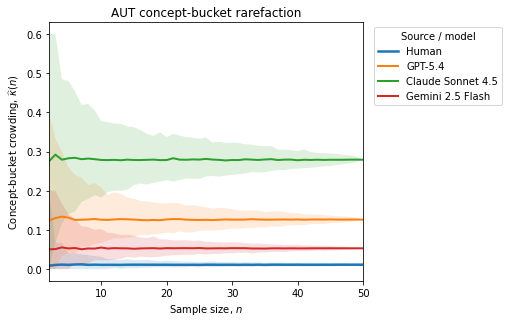

In [86]:
def plot_aut_bucket_task_rarefaction(
    rarefaction_df: pd.DataFrame,
    save_path: Optional[Path] = None,
):
    plot_df = rarefaction_df.copy()

    model_order = ["Human", "GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]

    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    for model_label in model_order:
        sub = plot_df[plot_df["model_label"].eq(model_label)].copy()
        if sub.empty:
            continue

        sub = sub.sort_values("n")

        ax.plot(
            sub["n"],
            sub["kappa_mean"],
            label=model_label,
            linewidth=2 if model_label != "Human" else 2.5,
        )

        ax.fill_between(
            sub["n"].to_numpy(dtype=float),
            sub["kappa_ci_low"].to_numpy(dtype=float),
            sub["kappa_ci_high"].to_numpy(dtype=float),
            alpha=0.15,
        )

    ax.axvline(50, linestyle="--", linewidth=1)
    ax.set_xlabel("Sample size, $n$")
    ax.set_ylabel("Concept-bucket crowding, $\\widehat{\\kappa}(n)$")
    ax.set_title("AUT concept-bucket rarefaction")
    ax.legend(title="Source / model", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_xlim(2, 50)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_aut_bucket_task_rarefaction(
    aut_bucket_rarefaction_task,
    save_path=FIG_DIR / "aut_bucket_kappa_rarefaction_task_level.pdf",
)

## 21.6 Make condition-level AUT bucket rarefaction plots

These are appendix diagnostics. They show whether any individual AUT object has an unstable bucket-crowding estimate.

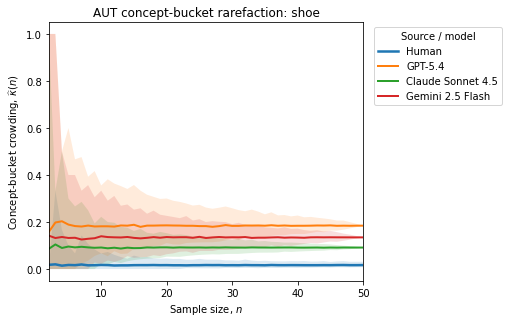

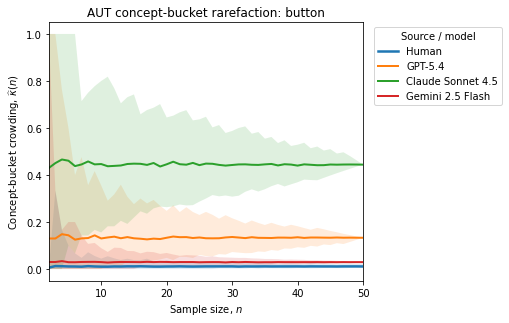

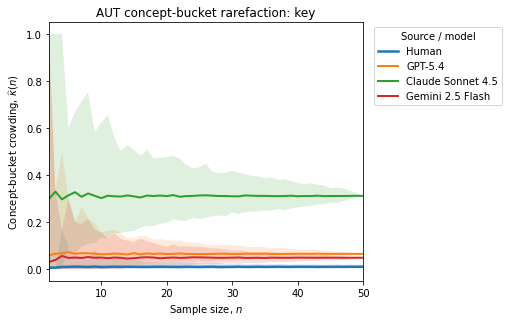

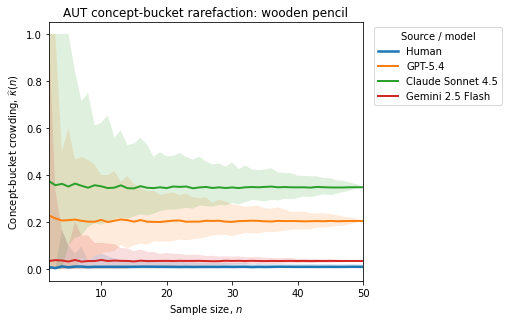

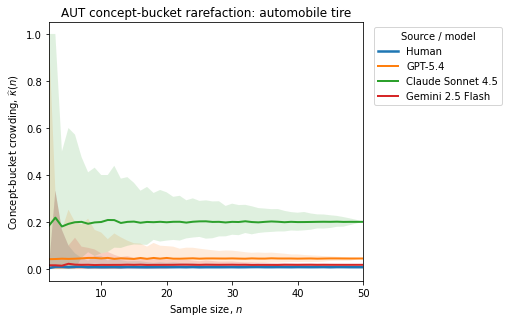

In [87]:
def plot_aut_bucket_condition_rarefaction(
    rarefaction_df: pd.DataFrame,
    condition_id: str,
    save_path: Optional[Path] = None,
):
    plot_df = rarefaction_df.query("condition_id == @condition_id").copy()

    model_order = ["Human", "GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]

    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    for model_label in model_order:
        sub = plot_df[plot_df["model_label"].eq(model_label)].copy()
        if sub.empty:
            continue

        sub = sub.sort_values("n")

        ax.plot(
            sub["n"],
            sub["kappa_mean"],
            label=model_label,
            linewidth=2 if model_label != "Human" else 2.5,
        )

        ax.fill_between(
            sub["n"].to_numpy(dtype=float),
            sub["kappa_ci_low"].to_numpy(dtype=float),
            sub["kappa_ci_high"].to_numpy(dtype=float),
            alpha=0.15,
        )

    ax.axvline(50, linestyle="--", linewidth=1)
    ax.set_xlabel("Sample size, $n$")
    ax.set_ylabel("Concept-bucket crowding, $\\widehat{\\kappa}(n)$")
    ax.set_title(f"AUT concept-bucket rarefaction: {condition_id.replace('_', ' ')}")
    ax.legend(title="Source / model", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_xlim(2, 50)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


for condition_id in ["shoe", "button", "key", "wooden_pencil", "automobile_tire"]:
    out_path = FIG_DIR / f"aut_bucket_kappa_rarefaction_condition__{condition_id}.pdf"

    plot_aut_bucket_condition_rarefaction(
        aut_bucket_rarefaction_condition,
        condition_id=condition_id,
        save_path=out_path,
    )

## 21.7 Decision table: do we need more AI data for the AUT bucket kernel?

This compact table mirrors the earlier rarefaction decision summaries. The default threshold marks a curve as stable if the relative drift from $n=40$ to $n=50$ is below 1%.

In [88]:
aut_bucket_more_data_decision = (
    aut_bucket_task_recent_drift
    .query("source_type == 'ai'")
    .copy()
)

aut_bucket_more_data_decision["needs_more_data_under_1pct_rule"] = (
    aut_bucket_more_data_decision["relative_abs_change"] >= 0.01
)

aut_bucket_more_data_decision = aut_bucket_more_data_decision[
    [
        "kernel_name",
        "model_label",
        "task_family",
        "n_low",
        "n_high",
        "kappa_low",
        "kappa_high",
        "kappa_change",
        "relative_abs_change",
        "relative_abs_change_pct",
        "recommendation",
        "needs_more_data_under_1pct_rule",
    ]
].sort_values(["kernel_name", "model_label"])

display(aut_bucket_more_data_decision)

aut_bucket_more_data_decision.to_csv(
    TABLE_DIR / "aut_bucket_more_data_decision_from_rarefaction.csv",
    index=False,
)

aut_bucket_more_data_decision.to_csv(
    AUT_BUCKET_RAREFACTION_DIR / "aut_bucket_more_data_decision_from_rarefaction.csv",
    index=False,
)

,kernel_name,model_label,task_family,n_low,n_high,kappa_low,kappa_high,kappa_change,relative_abs_change,relative_abs_change_pct,recommendation,needs_more_data_under_1pct_rule
0,concept_bucket,Claude Sonnet 4.5,aut,40,50,0.277659,0.279020,0.001361,0.004879,0.487933,likely enough AI data,False
1,concept_bucket,GPT-5.4,aut,40,50,0.126576,0.126204,-0.000372,0.002946,0.294615,likely enough AI data,False
2,concept_bucket,Gemini 2.5 Flash,aut,40,50,0.052737,0.052898,0.000161,0.003035,0.303458,likely enough AI data,False


## 21.8 Save final AUT bucket rarefaction status report

These files complete the AUT bucket-kernel analogue of the story plot-kernel and slogan lexical-kernel diagnostics.

In [89]:
print("=" * 100)
print("AUT BUCKET RAREFACTION FILES SAVED")
print("=" * 100)

saved_paths = [
    TABLE_DIR / "aut_bucket_kappa_rarefaction_condition_level.csv",
    TABLE_DIR / "aut_bucket_kappa_rarefaction_task_level.csv",
    TABLE_DIR / "aut_bucket_kappa_rarefaction_recent_drift.csv",
    TABLE_DIR / "aut_bucket_kappa_rarefaction_condition_recent_drift.csv",
    TABLE_DIR / "aut_bucket_more_data_decision_from_rarefaction.csv",
    FIG_DIR / "aut_bucket_kappa_rarefaction_task_level.pdf",
    FIG_DIR / "aut_bucket_kappa_rarefaction_condition__shoe.pdf",
    FIG_DIR / "aut_bucket_kappa_rarefaction_condition__button.pdf",
    FIG_DIR / "aut_bucket_kappa_rarefaction_condition__key.pdf",
    FIG_DIR / "aut_bucket_kappa_rarefaction_condition__wooden_pencil.pdf",
    FIG_DIR / "aut_bucket_kappa_rarefaction_condition__automobile_tire.pdf",
    AUT_BUCKET_RAREFACTION_DIR / "aut_bucket_kappa_rarefaction_condition_raw.pkl",
    AUT_BUCKET_RAREFACTION_DIR / "aut_bucket_kappa_rarefaction_task_raw.pkl",
]

for p in saved_paths:
    print(p, "| exists:", p.exists())

print("\nMain appendix rarefaction figure:")
print(FIG_DIR / "aut_bucket_kappa_rarefaction_task_level.pdf")

print("\nMain appendix drift table:")
print(TABLE_DIR / "aut_bucket_kappa_rarefaction_recent_drift.csv")

AUT BUCKET RAREFACTION FILES SAVED
analysis_outputs/tables/aut_bucket_kappa_rarefaction_condition_level.csv | exists: True
analysis_outputs/tables/aut_bucket_kappa_rarefaction_task_level.csv | exists: True
analysis_outputs/tables/aut_bucket_kappa_rarefaction_recent_drift.csv | exists: True
analysis_outputs/tables/aut_bucket_kappa_rarefaction_condition_recent_drift.csv | exists: True
analysis_outputs/tables/aut_bucket_more_data_decision_from_rarefaction.csv | exists: True
analysis_outputs/figures/aut_bucket_kappa_rarefaction_task_level.pdf | exists: True
analysis_outputs/figures/aut_bucket_kappa_rarefaction_condition__shoe.pdf | exists: True
analysis_outputs/figures/aut_bucket_kappa_rarefaction_condition__button.pdf | exists: True
analysis_outputs/figures/aut_bucket_kappa_rarefaction_condition__key.pdf | exists: True
analysis_outputs/figures/aut_bucket_kappa_rarefaction_condition__wooden_pencil.pdf | exists: True
analysis_outputs/figures/aut_bucket_kappa_rarefaction_condition__automobil